In [ ]:
!pip -q install -U huggingface_hub hf_xet pandas pyarrow tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.


In [ ]:
import os

os.environ['HF_XET_HIGH_PERFORMANCE'] = '0'
os.environ['HF_XET_FIXED_DOWNLOAD_CONCURRENCY'] = '1'
os.environ['HF_XET_DATA_MAX_CONCURRENT_FILE_DOWNLOADS'] = '1'
os.environ['HF_XET_RECONSTRUCT_WRITE_SEQUENTIALLY'] = '1'
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '1000'
os.environ['HF_HUB_ETAG_TIMEOUT'] = '100'

import gc
import shutil
import zipfile
from pathlib import Path

import pandas as pd
import psutil
from huggingface_hub import hf_hub_download
from tqdm.auto import tqdm

In [ ]:
project_dir = Path('/content/fnspid_project')
raw_dir = project_dir / 'fnspid_raw'
cache_dir = project_dir / 'hf_cache'

raw_dir.mkdir(parents=True, exist_ok=True)
cache_dir.mkdir(parents=True, exist_ok=True)

repo_id = 'Zihan1004/FNSPID'
repo_type = 'dataset'

def show_resources(note=''):
    ram = psutil.virtual_memory()
    disk = shutil.disk_usage('/content')

    print('=' * 80)
    if note:
        print(note)

    print(f'RAM total: {ram.total / 1024 ** 3:.2f} GiB')
    print(f'RAM used:  {ram.used / 1024 ** 3:.2f} GiB')
    print(f'RAM free:  {ram.available / 1024 ** 3:.2f} GiB')

    print(f'Disk total: {disk.total / 1024 ** 3:.2f} GiB')
    print(f'Disk used:  {disk.used / 1024 ** 3:.2f} GiB')
    print(f'Disk free:  {disk.free / 1024 ** 3:.2f} GiB')
    print('=' * 80)

def file_size_gib(path):
    path = Path(path)
    if not path.exists():
        return None
    return path.stat().st_size / 1024 ** 3

show_resources('Initial resources')

Initial resources
RAM total: 12.67 GiB
RAM used:  0.87 GiB
RAM free:  11.52 GiB
Disk total: 225.83 GiB
Disk used:  24.40 GiB
Disk free:  201.42 GiB


In [ ]:
def download_hf_file_safely(filename, min_expected_gib=None):
    target_path = raw_dir / filename

    print('\n' + '=' * 100)
    print('File:', filename)
    print('Target:', target_path)

    if target_path.exists():
        size_gib = file_size_gib(target_path)
        print(f'Already exists: {size_gib:.3f} GiB')

        if min_expected_gib is None or size_gib >= min_expected_gib:
            print('Skip download: existing file looks valid.')
            return target_path
        else:
            print('Existing file is too small. It will be downloaded again.')

    show_resources(f'Before downloading {filename}')

    local_path = hf_hub_download(
        repo_id=repo_id,
        repo_type=repo_type,
        filename=filename,
        local_dir=str(raw_dir),
        cache_dir=str(cache_dir),
        force_download=False,
        resume_download=True
    )

    local_path = Path(local_path)

    gc.collect()

    size_gib = file_size_gib(local_path)
    print(f'Downloaded path: {local_path}')
    print(f'Downloaded size: {size_gib:.3f} GiB')

    if min_expected_gib is not None and size_gib < min_expected_gib:
        raise RuntimeError(
            f'File {filename} seems incomplete: {size_gib:.3f} GiB '
            f'< expected minimum {min_expected_gib:.3f} GiB'
        )

    show_resources(f'After downloading {filename}')

    return local_path

In [ ]:
files_to_download = [
    {
        'filename': 'Stock_price/full_history.zip',
        'min_expected_gib': 0.50
    },
    {
        'filename': 'Stock_news/All_external.csv',
        'min_expected_gib': 5.00
    },
    {
        'filename': 'Stock_news/nasdaq_exteral_data.csv',
        'min_expected_gib': 20.00
    }
]

downloaded_paths = {}

for item in files_to_download:
    filename = item['filename']
    min_expected_gib = item['min_expected_gib']

    path = download_hf_file_safely(
        filename=filename,
        min_expected_gib=min_expected_gib
    )

    downloaded_paths[filename] = path

    gc.collect()

print('\nDownloaded files:')
for filename, path in downloaded_paths.items():
    print(filename, '->', path, f'({file_size_gib(path):.3f} GiB)')


File: Stock_price/full_history.zip
Target: /content/fnspid_project/fnspid_raw/Stock_price/full_history.zip
Before downloading Stock_price/full_history.zip
RAM total: 12.67 GiB
RAM used:  0.86 GiB
RAM free:  11.54 GiB
Disk total: 225.83 GiB
Disk used:  24.40 GiB
Disk free:  201.42 GiB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  warnings.warn(


Stock_price/full_history.zip:   0%|          | 0.00/590M [00:00<?, ?B/s]

Downloaded path: /content/fnspid_project/fnspid_raw/Stock_price/full_history.zip
Downloaded size: 0.549 GiB
After downloading Stock_price/full_history.zip
RAM total: 12.67 GiB
RAM used:  0.91 GiB
RAM free:  11.48 GiB
Disk total: 225.83 GiB
Disk used:  24.86 GiB
Disk free:  200.95 GiB

File: Stock_news/All_external.csv
Target: /content/fnspid_project/fnspid_raw/Stock_news/All_external.csv
Before downloading Stock_news/All_external.csv
RAM total: 12.67 GiB
RAM used:  0.91 GiB
RAM free:  11.48 GiB
Disk total: 225.83 GiB
Disk used:  24.86 GiB
Disk free:  200.95 GiB


Stock_news/All_external.csv:   0%|          | 0.00/5.73G [00:00<?, ?B/s]

Downloaded path: /content/fnspid_project/fnspid_raw/Stock_news/All_external.csv
Downloaded size: 5.338 GiB
After downloading Stock_news/All_external.csv
RAM total: 12.67 GiB
RAM used:  0.98 GiB
RAM free:  11.38 GiB
Disk total: 225.83 GiB
Disk used:  28.57 GiB
Disk free:  197.25 GiB

File: Stock_news/nasdaq_exteral_data.csv
Target: /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv
Before downloading Stock_news/nasdaq_exteral_data.csv
RAM total: 12.67 GiB
RAM used:  0.98 GiB
RAM free:  11.38 GiB
Disk total: 225.83 GiB
Disk used:  28.57 GiB
Disk free:  197.25 GiB


Stock_news/nasdaq_exteral_data.csv:   0%|          | 0.00/23.2G [00:00<?, ?B/s]

Downloaded path: /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv
Downloaded size: 21.637 GiB
After downloading Stock_news/nasdaq_exteral_data.csv
RAM total: 12.67 GiB
RAM used:  1.02 GiB
RAM free:  11.34 GiB
Disk total: 225.83 GiB
Disk used:  48.58 GiB
Disk free:  177.24 GiB

Downloaded files:
Stock_price/full_history.zip -> /content/fnspid_project/fnspid_raw/Stock_price/full_history.zip (0.549 GiB)
Stock_news/All_external.csv -> /content/fnspid_project/fnspid_raw/Stock_news/All_external.csv (5.338 GiB)
Stock_news/nasdaq_exteral_data.csv -> /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv (21.637 GiB)


In [ ]:
check_rows = []

for filename in [
    'Stock_price/full_history.zip',
    'Stock_news/All_external.csv',
    'Stock_news/nasdaq_exteral_data.csv'
]:
    path = raw_dir / filename
    check_rows.append({
        'filename': filename,
        'path': str(path),
        'exists': path.exists(),
        'size_gib': file_size_gib(path)
    })

download_check_df = pd.DataFrame(check_rows)
display(download_check_df)

if not download_check_df['exists'].all():
    raise FileNotFoundError('Some files were not downloaded.')

print('All selected FNSPID source files are available.')

,filename,path,exists,size_gib
0,Stock_price/full_history.zip,/content/fnspid_project/fnspid_raw/Stock_price...,True,0.549038
1,Stock_news/All_external.csv,/content/fnspid_project/fnspid_raw/Stock_news/...,True,5.337779
2,Stock_news/nasdaq_exteral_data.csv,/content/fnspid_project/fnspid_raw/Stock_news/...,True,21.637398


All selected FNSPID source files are available.


In [ ]:
zip_path = raw_dir / 'Stock_price' / 'full_history.zip'
extract_dir = raw_dir / 'Stock_price' / 'full_history'

extract_dir.mkdir(parents=True, exist_ok=True)

existing_price_csv = [
    path for path in extract_dir.rglob('*.csv')
    if '__MACOSX' not in str(path)
]

if len(existing_price_csv) > 0:
    print('Price files already extracted:', len(existing_price_csv))
else:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        bad_file = zip_ref.testzip()

        if bad_file is not None:
            raise RuntimeError(f'Archive is damaged. Bad file: {bad_file}')

        members = zip_ref.namelist()
        print('Archive members:', len(members))

        for member in tqdm(members, desc='Extracting price files'):
            zip_ref.extract(member, extract_dir)

    print('Extraction finished.')

gc.collect()
show_resources('After extracting full_history.zip')

Archive members: 15388


Extracting price files:   0%|          | 0/15388 [00:00<?, ?it/s]

Extraction finished.
After extracting full_history.zip
RAM total: 12.67 GiB
RAM used:  1.00 GiB
RAM free:  11.36 GiB
Disk total: 225.83 GiB
Disk used:  51.36 GiB
Disk free:  174.45 GiB


In [ ]:
price_csv_paths = sorted([
    path for path in extract_dir.rglob('*.csv')
    if '__MACOSX' not in str(path)
])

price_files_df = pd.DataFrame({
    'path': [str(path) for path in price_csv_paths],
    'ticker': [path.stem for path in price_csv_paths],
    'size_mb': [path.stat().st_size / 1024 ** 2 for path in price_csv_paths]
})

print('Number of price CSV files:', len(price_files_df))
display(price_files_df.head())
display(price_files_df.sort_values('size_mb', ascending=False).head(20))

Number of price CSV files: 7693


,path,ticker,size_mb
0,/content/fnspid_project/fnspid_raw/Stock_price...,A,0.638661
1,/content/fnspid_project/fnspid_raw/Stock_price...,AA,1.635921
2,/content/fnspid_project/fnspid_raw/Stock_price...,AAAU,0.126074
3,/content/fnspid_project/fnspid_raw/Stock_price...,AACG,0.396477
4,/content/fnspid_project/fnspid_raw/Stock_price...,AADR,0.320726


,path,ticker,size_mb
3331,/content/fnspid_project/fnspid_raw/Stock_price...,HPQ,1.678671
1790,/content/fnspid_project/fnspid_raw/Stock_price...,DIS,1.660865
2897,/content/fnspid_project/fnspid_raw/Stock_price...,GE,1.652170
1,/content/fnspid_project/fnspid_raw/Stock_price...,AA,1.635921
448,/content/fnspid_project/fnspid_raw/Stock_price...,ARNC,1.539135
3681,/content/fnspid_project/fnspid_raw/Stock_price...,IP,1.521780
615,/content/fnspid_project/fnspid_raw/Stock_price...,BA,1.508279
4054,/content/fnspid_project/fnspid_raw/Stock_price...,KO,1.477928
1402,/content/fnspid_project/fnspid_raw/Stock_price...,CNP,1.429963
4633,/content/fnspid_project/fnspid_raw/Stock_price...,MSI,1.429087


In [ ]:
fnspid_paths = {
    'project_dir': project_dir,
    'raw_dir': raw_dir,
    'cache_dir': cache_dir,
    'all_external': raw_dir / 'Stock_news' / 'All_external.csv',
    'nasdaq_external': raw_dir / 'Stock_news' / 'nasdaq_exteral_data.csv',
    'price_zip': raw_dir / 'Stock_price' / 'full_history.zip',
    'price_extract_dir': extract_dir,
    'price_csv_paths': price_csv_paths
}

print('FNSPID paths are ready.')

for key, value in fnspid_paths.items():
    if key != 'price_csv_paths':
        print(f'{key}: {value}')

print('n_price_csv_paths:', len(fnspid_paths['price_csv_paths']))

FNSPID paths are ready.
project_dir: /content/fnspid_project
raw_dir: /content/fnspid_project/fnspid_raw
cache_dir: /content/fnspid_project/hf_cache
all_external: /content/fnspid_project/fnspid_raw/Stock_news/All_external.csv
nasdaq_external: /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv
price_zip: /content/fnspid_project/fnspid_raw/Stock_price/full_history.zip
price_extract_dir: /content/fnspid_project/fnspid_raw/Stock_price/full_history
n_price_csv_paths: 7693


## Подсоединяем информацию по секторам GICS

In [ ]:
!pip -q install -U lxml html5lib beautifulsoup4 requests pyarrow fastparquet tqdm psutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 12.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
import gc
import json
import re
import shutil
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import requests
from tqdm.auto import tqdm

In [ ]:
project_dir = fnspid_paths['project_dir']
raw_dir = fnspid_paths['raw_dir']

sp500_dir = project_dir / 'sp500_current_selection'
metadata_dir = sp500_dir / 'metadata'
prices_dir = sp500_dir / 'prices'
news_dir = sp500_dir / 'news'

metadata_dir.mkdir(parents=True, exist_ok=True)
prices_dir.mkdir(parents=True, exist_ok=True)
news_dir.mkdir(parents=True, exist_ok=True)

print('sp500_dir:', sp500_dir)
print('metadata_dir:', metadata_dir)
print('prices_dir:', prices_dir)
print('news_dir:', news_dir)

sp500_dir: /content/fnspid_project/sp500_current_selection
metadata_dir: /content/fnspid_project/sp500_current_selection/metadata
prices_dir: /content/fnspid_project/sp500_current_selection/prices
news_dir: /content/fnspid_project/sp500_current_selection/news


In [ ]:
def show_resources(note=''):
    ram = psutil.virtual_memory()
    disk = shutil.disk_usage('/content')

    print('=' * 80)
    if note:
        print(note)

    print(f'RAM total: {ram.total / 1024 ** 3:.2f} GiB')
    print(f'RAM used:  {ram.used / 1024 ** 3:.2f} GiB')
    print(f'RAM free:  {ram.available / 1024 ** 3:.2f} GiB')

    print(f'Disk total: {disk.total / 1024 ** 3:.2f} GiB')
    print(f'Disk used:  {disk.used / 1024 ** 3:.2f} GiB')
    print(f'Disk free:  {disk.free / 1024 ** 3:.2f} GiB')
    print('=' * 80)


def normalize_symbol(value):
    if pd.isna(value):
        return None

    value = str(value).strip().upper()

    if value == '':
        return None

    value = value.replace('$', '')
    value = value.replace('/', '.')
    value = value.replace('-', '.')
    value = re.sub(r'\s+', '', value)

    return value


def make_safe_filename(value):
    value = str(value).upper()
    value = value.replace('.', '_')
    value = re.sub(r'[^A-Z0-9_]+', '_', value)
    return value


def pick_existing_col(df, candidates):
    lower_map = {col.lower(): col for col in df.columns}

    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    return None


show_resources('Before S&P 500 selection pipeline')

Before S&P 500 selection pipeline
RAM total: 12.67 GiB
RAM used:  1.01 GiB
RAM free:  11.35 GiB
Disk total: 225.83 GiB
Disk used:  51.38 GiB
Disk free:  174.44 GiB


In [ ]:
sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {
    'User-Agent': (
        'Mozilla/5.0 (X11; Linux x86_64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/124.0 Safari/537.36'
    )
}

response = requests.get(sp500_url, headers=headers, timeout=60)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))
print('Number of tables:', len(tables))

sp500_raw = tables[0].copy()
print('Raw shape:', sp500_raw.shape)
display(sp500_raw.head())

Number of tables: 3
Raw shape: (503, 8)


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [ ]:
sp500_df = sp500_raw.copy()

sp500_df.columns = [
    str(col).strip().replace('\n', ' ')
    for col in sp500_df.columns
]

required_cols = [
    'Symbol',
    'Security',
    'GICS Sector',
    'GICS Sub-Industry',
    'Date added',
    'CIK'
]

missing_cols = [col for col in required_cols if col not in sp500_df.columns]

if missing_cols:
    raise ValueError(f'Missing expected S&P 500 columns: {missing_cols}')

sp500_df = sp500_df[required_cols].copy()

sp500_df = sp500_df.rename(columns={
    'Symbol': 'symbol_wiki',
    'Security': 'security',
    'GICS Sector': 'gics_sector',
    'GICS Sub-Industry': 'gics_sub_industry',
    'Date added': 'date_added',
    'CIK': 'cik'
})

sp500_df['symbol_wiki'] = sp500_df['symbol_wiki'].astype(str).str.strip().str.upper()
sp500_df['symbol_key'] = sp500_df['symbol_wiki'].map(normalize_symbol)
sp500_df['symbol_yahoo'] = sp500_df['symbol_wiki'].str.replace('.', '-', regex=False)
sp500_df['date_added'] = pd.to_datetime(sp500_df['date_added'], errors='coerce')
sp500_df['cik'] = sp500_df['cik'].astype(str).str.zfill(10)

sp500_df = sp500_df.drop_duplicates(subset=['symbol_key']).reset_index(drop=True)

print('Current S&P 500 rows:', len(sp500_df))
print('Unique sectors:', sp500_df['gics_sector'].nunique())
display(sp500_df.head())
display(sp500_df['gics_sector'].value_counts().sort_index())

Current S&P 500 rows: 503
Unique sectors: 11


,symbol_wiki,security,gics_sector,gics_sub_industry,date_added,cik,symbol_key,symbol_yahoo
0,MMM,3M,Industrials,Industrial Conglomerates,1957-03-04,0000066740,MMM,MMM
1,AOS,A. O. Smith,Industrials,Building Products,2017-07-26,0000091142,AOS,AOS
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,1957-03-04,0000001800,ABT,ABT
3,ABBV,AbbVie,Health Care,Biotechnology,2012-12-31,0001551152,ABBV,ABBV
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,2011-07-06,0001467373,ACN,ACN


gics_sector
Communication Services    23
Consumer Discretionary    48
Consumer Staples          36
Energy                    22
Financials                76
Health Care               58
Industrials               79
Information Technology    73
Materials                 26
Real Estate               31
Utilities                 31
Name: count, dtype: int64

In [ ]:
sp500_constituents_path = metadata_dir / 'sp500_current_constituents_with_gics.csv'
sp500_constituents_parquet_path = metadata_dir / 'sp500_current_constituents_with_gics.parquet'

sp500_df.to_csv(sp500_constituents_path, index=False)
sp500_df.to_parquet(sp500_constituents_parquet_path, index=False)

print('Saved:')
print(sp500_constituents_path)
print(sp500_constituents_parquet_path)

Saved:
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_constituents_with_gics.csv
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_constituents_with_gics.parquet


In [ ]:
sp500_keys = set(sp500_df['symbol_key'].dropna())

symbol_to_wiki = dict(zip(sp500_df['symbol_key'], sp500_df['symbol_wiki']))
symbol_to_yahoo = dict(zip(sp500_df['symbol_key'], sp500_df['symbol_yahoo']))
symbol_to_security = dict(zip(sp500_df['symbol_key'], sp500_df['security']))
symbol_to_sector = dict(zip(sp500_df['symbol_key'], sp500_df['gics_sector']))
symbol_to_sub_industry = dict(zip(sp500_df['symbol_key'], sp500_df['gics_sub_industry']))
symbol_to_date_added = dict(zip(sp500_df['symbol_key'], sp500_df['date_added']))
symbol_to_cik = dict(zip(sp500_df['symbol_key'], sp500_df['cik']))

print('Number of S&P 500 symbol keys:', len(sp500_keys))

Number of S&P 500 symbol keys: 503


In [ ]:
price_files_df = pd.DataFrame({
    'price_path': [str(path) for path in price_csv_paths],
    'ticker_file': [Path(path).stem.upper() for path in price_csv_paths]
})

price_files_df['symbol_key'] = price_files_df['ticker_file'].map(normalize_symbol)

sp500_price_files_df = price_files_df.merge(
    sp500_df,
    on='symbol_key',
    how='inner'
)

sp500_price_files_df = sp500_price_files_df.sort_values(
    ['gics_sector', 'symbol_wiki']
).reset_index(drop=True)

missing_price_df = sp500_df.loc[
    ~sp500_df['symbol_key'].isin(set(sp500_price_files_df['symbol_key']))
].copy()

print('FNSPID price files total:', len(price_files_df))
print('Matched current S&P 500 price files:', len(sp500_price_files_df))
print('Current S&P 500 tickers without FNSPID price file:', len(missing_price_df))

display(sp500_price_files_df.head())
display(missing_price_df[['symbol_wiki', 'security', 'gics_sector', 'date_added']].head(50))

FNSPID price files total: 7693
Matched current S&P 500 price files: 453
Current S&P 500 tickers without FNSPID price file: 50


,price_path,ticker_file,symbol_key,symbol_wiki,security,gics_sector,gics_sub_industry,date_added,cik,symbol_yahoo
0,/content/fnspid_project/fnspid_raw/Stock_price...,CHTR,CHTR,CHTR,Charter Communications,Communication Services,Cable & Satellite,2016-09-08,0001091667,CHTR
1,/content/fnspid_project/fnspid_raw/Stock_price...,CMCSA,CMCSA,CMCSA,Comcast,Communication Services,Cable & Satellite,2002-11-19,0001166691,CMCSA
2,/content/fnspid_project/fnspid_raw/Stock_price...,DIS,DIS,DIS,Walt Disney Company (The),Communication Services,Movies & Entertainment,1976-06-30,0001744489,DIS
3,/content/fnspid_project/fnspid_raw/Stock_price...,EA,EA,EA,Electronic Arts,Communication Services,Interactive Home Entertainment,2002-07-22,0000712515,EA
4,/content/fnspid_project/fnspid_raw/Stock_price...,FOX,FOX,FOX,Fox Corporation (Class B),Communication Services,Broadcasting,2019-03-19,0001754301,FOX


,symbol_wiki,security,gics_sector,date_added
11,ABNB,Airbnb,Consumer Discretionary,2023-09-18
40,APP,AppLovin,Information Technology,2025-09-22
55,AXON,Axon Enterprise,Industrials,2023-05-04
57,BALL,Ball Corporation,Materials,1984-10-31
61,BRK.B,Berkshire Hathaway,Financials,2010-02-16
67,XYZ,"Block, Inc.",Financials,2025-07-23
76,BF.B,Brown–Forman,Consumer Staples,1982-10-31
92,CBRE,CBRE Group,Real Estate,2006-11-10
103,CB,Chubb Limited,Financials,2010-07-15
118,COIN,Coinbase,Financials,2025-05-19


In [ ]:
sp500_price_files_path = metadata_dir / 'sp500_current_price_files_matched.csv'
missing_price_path = metadata_dir / 'sp500_current_missing_price_files.csv'

sp500_price_files_df.to_csv(sp500_price_files_path, index=False)
missing_price_df.to_csv(missing_price_path, index=False)

print('Saved:')
print(sp500_price_files_path)
print(missing_price_path)

Saved:
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_price_files_matched.csv
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_missing_price_files.csv


In [ ]:
price_parquet_dir = prices_dir / 'parquet_by_symbol'
price_parquet_dir.mkdir(parents=True, exist_ok=True)

price_summary_rows = []

for row in tqdm(
    sp500_price_files_df.itertuples(index=False),
    total=len(sp500_price_files_df),
    desc='Processing S&P 500 price files'
):
    price_path = Path(row.price_path)
    symbol_key = row.symbol_key
    symbol_wiki = row.symbol_wiki
    safe_symbol = make_safe_filename(symbol_wiki)

    out_path = price_parquet_dir / f'{safe_symbol}.parquet'

    if out_path.exists():
        try:
            existing_meta = pd.read_parquet(out_path, columns=['symbol'])
            n_rows = len(existing_meta)

            price_summary_rows.append({
                'symbol_wiki': symbol_wiki,
                'symbol_yahoo': row.symbol_yahoo,
                'security': row.security,
                'gics_sector': row.gics_sector,
                'gics_sub_industry': row.gics_sub_industry,
                'input_path': str(price_path),
                'output_path': str(out_path),
                'n_rows': n_rows,
                'status': 'already_exists'
            })

            del existing_meta
            gc.collect()
            continue
        except Exception:
            out_path.unlink()

    df = pd.read_csv(price_path)

    df.columns = [
        str(col).strip().lower().replace(' ', '_')
        for col in df.columns
    ]

    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')

    df['symbol'] = symbol_wiki
    df['symbol_key'] = symbol_key
    df['symbol_yahoo'] = row.symbol_yahoo
    df['security'] = row.security
    df['gics_sector'] = row.gics_sector
    df['gics_sub_industry'] = row.gics_sub_industry
    df['sp500_date_added'] = row.date_added
    df['cik'] = row.cik
    df['source_price_file'] = price_path.name

    front_cols = [
        'symbol',
        'symbol_key',
        'symbol_yahoo',
        'security',
        'gics_sector',
        'gics_sub_industry',
        'sp500_date_added',
        'cik',
        'source_price_file'
    ]

    other_cols = [col for col in df.columns if col not in front_cols]
    df = df[front_cols + other_cols]

    df.to_parquet(out_path, index=False)

    price_summary_rows.append({
        'symbol_wiki': symbol_wiki,
        'symbol_yahoo': row.symbol_yahoo,
        'security': row.security,
        'gics_sector': row.gics_sector,
        'gics_sub_industry': row.gics_sub_industry,
        'input_path': str(price_path),
        'output_path': str(out_path),
        'n_rows': len(df),
        'status': 'processed'
    })

    del df
    gc.collect()

price_summary_df = pd.DataFrame(price_summary_rows)

price_summary_path = metadata_dir / 'sp500_current_prices_processing_summary.csv'
price_summary_df.to_csv(price_summary_path, index=False)

print('Saved price parquet dir:', price_parquet_dir)
print('Saved price summary:', price_summary_path)

display(price_summary_df.head())
display(price_summary_df.groupby('gics_sector')['n_rows'].sum().sort_values(ascending=False))

Processing S&P 500 price files:   0%|          | 0/453 [00:00<?, ?it/s]

Saved price parquet dir: /content/fnspid_project/sp500_current_selection/prices/parquet_by_symbol
Saved price summary: /content/fnspid_project/sp500_current_selection/metadata/sp500_current_prices_processing_summary.csv


,symbol_wiki,symbol_yahoo,security,gics_sector,gics_sub_industry,input_path,output_path,n_rows,status
0,CHTR,CHTR,Charter Communications,Communication Services,Cable & Satellite,/content/fnspid_project/fnspid_raw/Stock_price...,/content/fnspid_project/sp500_current_selectio...,3520,processed
1,CMCSA,CMCSA,Comcast,Communication Services,Cable & Satellite,/content/fnspid_project/fnspid_raw/Stock_price...,/content/fnspid_project/sp500_current_selectio...,11040,processed
2,DIS,DIS,Walt Disney Company (The),Communication Services,Movies & Entertainment,/content/fnspid_project/fnspid_raw/Stock_price...,/content/fnspid_project/sp500_current_selectio...,15605,processed
3,EA,EA,Electronic Arts,Communication Services,Interactive Home Entertainment,/content/fnspid_project/fnspid_raw/Stock_price...,/content/fnspid_project/sp500_current_selectio...,8635,processed
4,FOX,FOX,Fox Corporation (Class B),Communication Services,Broadcasting,/content/fnspid_project/fnspid_raw/Stock_price...,/content/fnspid_project/sp500_current_selectio...,1209,processed


gics_sector
Industrials               629229
Financials                500433
Information Technology    472440
Health Care               419857
Consumer Staples          323121
Consumer Discretionary    317548
Utilities                 303683
Real Estate               195589
Materials                 186842
Energy                    170285
Communication Services     99691
Name: n_rows, dtype: int64

In [ ]:
price_parquet_paths = sorted(price_parquet_dir.glob('*.parquet'))

print('Number of saved price parquet files:', len(price_parquet_paths))

sample_price_df = pd.read_parquet(price_parquet_paths[0])
print(sample_price_df.shape)
display(sample_price_df.head())
display(sample_price_df[['symbol', 'security', 'gics_sector', 'gics_sub_industry']].drop_duplicates().head())

del sample_price_df
gc.collect()

Number of saved price parquet files: 453
(6066, 16)


,symbol,symbol_key,symbol_yahoo,security,gics_sector,gics_sub_industry,sp500_date_added,cik,source_price_file,date,volume,open,high,low,close,adj_close
0,A,A,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2000-06-05,0001090872,A.csv,2023-12-28,892600,140.539993,140.809998,139.649994,139.770004,139.770004
1,A,A,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2000-06-05,0001090872,A.csv,2023-12-27,1182300,139.779999,140.160004,139.080002,139.820007,139.820007
2,A,A,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2000-06-05,0001090872,A.csv,2023-12-26,948400,139.309998,140.470001,139.089996,139.809998,139.809998
3,A,A,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2000-06-05,0001090872,A.csv,2023-12-22,1204100,139.610001,140.360001,138.789993,139.570007,139.570007
4,A,A,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2000-06-05,0001090872,A.csv,2023-12-21,1685700,139.380005,139.669998,138.000000,138.940002,138.940002


,symbol,security,gics_sector,gics_sub_industry
0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services


34

In [ ]:
news_source_paths = {
    'all_external': fnspid_paths['all_external'],
    'nasdaq_external': fnspid_paths['nasdaq_external']
}

news_symbol_col_candidates = [
    'Stock_symbol',
    'stock_symbol',
    'symbol',
    'ticker',
    'Ticker',
    'Stock Symbol',
    'stock'
]

news_schema_rows = []

for source_name, source_path in news_source_paths.items():
    preview_df = pd.read_csv(source_path, nrows=5, low_memory=False)

    symbol_col = pick_existing_col(preview_df, news_symbol_col_candidates)

    news_schema_rows.append({
        'source_name': source_name,
        'source_path': str(source_path),
        'n_preview_rows': len(preview_df),
        'n_columns': len(preview_df.columns),
        'symbol_col': symbol_col,
        'columns': list(preview_df.columns)
    })

    print('\n' + '=' * 100)
    print('source_name:', source_name)
    print('source_path:', source_path)
    print('symbol_col:', symbol_col)
    print('columns:')
    print(list(preview_df.columns))

    display(preview_df.head())

    del preview_df
    gc.collect()

news_schema_df = pd.DataFrame(news_schema_rows)
news_schema_path = metadata_dir / 'news_source_schema_check.csv'
news_schema_df.to_csv(news_schema_path, index=False)

display(news_schema_df[['source_name', 'source_path', 'symbol_col', 'n_columns']])
print('Saved:', news_schema_path)


source_name: all_external
source_path: /content/fnspid_project/fnspid_raw/Stock_news/All_external.csv
symbol_col: Stock_symbol
columns:
['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']


,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,2020-06-05 06:30:54 UTC,Stocks That Hit 52-Week Highs On Friday,A,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-06-03 06:45:20 UTC,Stocks That Hit 52-Week Highs On Wednesday,A,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-05-26 00:30:07 UTC,71 Biggest Movers From Friday,A,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-05-22 08:45:06 UTC,46 Stocks Moving In Friday's Mid-Day Session,A,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-05-22 07:38:59 UTC,B of A Securities Maintains Neutral on Agilent...,A,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,NaN,NaN,NaN,NaN,NaN,NaN



source_name: nasdaq_external
source_path: /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv
symbol_col: Stock_symbol
columns:
['Unnamed: 0', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']


,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,0.0,2023-12-16 23:00:00 UTC,Interesting A Put And Call Options For August ...,A,https://www.nasdaq.com/articles/interesting-a-...,NaN,NaN,"Investors in Agilent Technologies, Inc. (Symbo...",Because the $125.00 strike represents an appro...,The current analytical data (including greeks ...,Below is a chart showing the trailing twelve m...,"At Stock Options Channel, our YieldBoost formu..."
1,1.0,2023-12-12 00:00:00 UTC,Wolfe Research Initiates Coverage of Agilent T...,A,https://www.nasdaq.com/articles/wolfe-research...,NaN,NaN,"Fintel reports that on December 13, 2023, Wolf...","Fintel reports that on December 13, 2023, Wolf...","T. Rowe Price Investment Management holds 10,1...",Agilent Technologies Declares $0.24 Dividend O...,The projected annual revenue for Agilent Techn...
2,2.0,2023-12-12 00:00:00 UTC,Agilent Technologies Reaches Analyst Target Price,A,https://www.nasdaq.com/articles/agilent-techno...,NaN,NaN,"In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...",When a stock reaches the target an analyst has...,When a stock reaches the target an analyst has...
3,3.0,2023-12-07 00:00:00 UTC,Agilent (A) Enhances BioTek Cytation C10 With ...,A,https://www.nasdaq.com/articles/agilent-a-enha...,NaN,NaN,Agilent Technologies A is enhancing its BioTek...,"Per a Grand View Research report, the global m...","Notably, Agilent enhanced the BioTek Cytation ...","Agilent Technologies, Inc. Price and Consensus...","Notably, Agilent enhanced the BioTek Cytation ..."
4,4.0,2023-12-07 00:00:00 UTC,"Pre-Market Most Active for Dec 7, 2023 : SQQQ,...",A,https://www.nasdaq.com/articles/pre-market-mos...,NaN,NaN,The NASDAQ 100 Pre-Market Indicator is up 70.2...,ProShares UltraPro Short QQQ (SQQQ) is -0.15 a...,"As reported by Zacks, the current mean recomme...","The total Pre-Market volume is currently 39,23...",The NASDAQ 100 Pre-Market Indicator is up 70.2...


,source_name,source_path,symbol_col,n_columns
0,all_external,/content/fnspid_project/fnspid_raw/Stock_news/...,Stock_symbol,11
1,nasdaq_external,/content/fnspid_project/fnspid_raw/Stock_news/...,Stock_symbol,12


Saved: /content/fnspid_project/sp500_current_selection/metadata/news_source_schema_check.csv


In [ ]:
def filter_news_source_to_sp500(
    source_name,
    source_path,
    symbol_col,
    chunksize=100_000,
    max_chunks=None
):
    source_path = Path(source_path)

    source_out_dir = news_dir / source_name / 'parquet_parts'
    source_out_dir.mkdir(parents=True, exist_ok=True)

    summary_path = news_dir / source_name / f'{source_name}_filtering_summary.csv'

    print('\n' + '=' * 100)
    print('Filtering news source:', source_name)
    print('Input:', source_path)
    print('Output dir:', source_out_dir)
    print('Symbol column:', symbol_col)
    print('Chunksize:', chunksize)

    if symbol_col is None:
        raise ValueError(f'Cannot filter {source_name}: symbol column was not detected.')

    part_id = 0
    summary_rows = []
    total_rows = 0
    total_selected_rows = 0

    reader = pd.read_csv(
        source_path,
        chunksize=chunksize,
        low_memory=False,
        on_bad_lines='skip'
    )

    for chunk_id, chunk in enumerate(tqdm(reader, desc=f'Filtering {source_name}')):
        if max_chunks is not None and chunk_id >= max_chunks:
            break

        n_rows = len(chunk)
        total_rows += n_rows

        if symbol_col not in chunk.columns:
            raise ValueError(
                f'Column {symbol_col} not found in chunk {chunk_id} of {source_name}. '
                f'Available columns: {list(chunk.columns)}'
            )

        chunk['_symbol_key'] = chunk[symbol_col].map(normalize_symbol)
        selected = chunk.loc[chunk['_symbol_key'].isin(sp500_keys)].copy()

        n_selected = len(selected)
        total_selected_rows += n_selected

        if n_selected > 0:
            selected['symbol'] = selected['_symbol_key'].map(symbol_to_wiki)
            selected['symbol_yahoo'] = selected['_symbol_key'].map(symbol_to_yahoo)
            selected['security'] = selected['_symbol_key'].map(symbol_to_security)
            selected['gics_sector'] = selected['_symbol_key'].map(symbol_to_sector)
            selected['gics_sub_industry'] = selected['_symbol_key'].map(symbol_to_sub_industry)
            selected['sp500_date_added'] = selected['_symbol_key'].map(symbol_to_date_added)
            selected['cik'] = selected['_symbol_key'].map(symbol_to_cik)
            selected['news_source'] = source_name
            selected['source_news_file'] = source_path.name

            selected = selected.rename(columns={'_symbol_key': 'symbol_key'})

            front_cols = [
                'symbol',
                'symbol_key',
                'symbol_yahoo',
                'security',
                'gics_sector',
                'gics_sub_industry',
                'sp500_date_added',
                'cik',
                'news_source',
                'source_news_file'
            ]

            other_cols = [col for col in selected.columns if col not in front_cols]
            selected = selected[front_cols + other_cols]

            out_path = source_out_dir / f'part_{part_id:06d}.parquet'
            selected.to_parquet(out_path, index=False)

            summary_rows.append({
                'source_name': source_name,
                'chunk_id': chunk_id,
                'part_id': part_id,
                'input_rows': n_rows,
                'selected_rows': n_selected,
                'output_path': str(out_path),
                'status': 'saved'
            })

            part_id += 1
        else:
            summary_rows.append({
                'source_name': source_name,
                'chunk_id': chunk_id,
                'part_id': None,
                'input_rows': n_rows,
                'selected_rows': 0,
                'output_path': None,
                'status': 'empty'
            })

        del chunk
        if 'selected' in locals():
            del selected

        if chunk_id % 25 == 0:
            gc.collect()

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(summary_path, index=False)

    print('\nFinished:', source_name)
    print('Total input rows:', total_rows)
    print('Total selected rows:', total_selected_rows)
    print('Saved parts:', part_id)
    print('Summary:', summary_path)

    gc.collect()

    return {
        'source_name': source_name,
        'source_out_dir': source_out_dir,
        'summary_path': summary_path,
        'total_rows': total_rows,
        'total_selected_rows': total_selected_rows,
        'saved_parts': part_id
    }

In [ ]:
news_filter_results = []

for row in news_schema_df.itertuples(index=False):
    result = filter_news_source_to_sp500(
        source_name=row.source_name,
        source_path=row.source_path,
        symbol_col=row.symbol_col,
        chunksize=100_000,
        max_chunks=None
    )

    news_filter_results.append(result)

news_filter_results_df = pd.DataFrame(news_filter_results)
news_filter_results_path = metadata_dir / 'sp500_current_news_filter_results.csv'
news_filter_results_df.to_csv(news_filter_results_path, index=False)

display(news_filter_results_df)
print('Saved:', news_filter_results_path)


Filtering news source: all_external
Input: /content/fnspid_project/fnspid_raw/Stock_news/All_external.csv
Output dir: /content/fnspid_project/sp500_current_selection/news/all_external/parquet_parts
Symbol column: Stock_symbol
Chunksize: 100000


Filtering all_external: 0it [00:00, ?it/s]


Finished: all_external
Total input rows: 13057514
Total selected rows: 652496
Saved parts: 34
Summary: /content/fnspid_project/sp500_current_selection/news/all_external/all_external_filtering_summary.csv

Filtering news source: nasdaq_external
Input: /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv
Output dir: /content/fnspid_project/sp500_current_selection/news/nasdaq_external/parquet_parts
Symbol column: Stock_symbol
Chunksize: 100000


Filtering nasdaq_external: 0it [00:00, ?it/s]


Finished: nasdaq_external
Total input rows: 15549299
Total selected rows: 1381853
Saved parts: 58
Summary: /content/fnspid_project/sp500_current_selection/news/nasdaq_external/nasdaq_external_filtering_summary.csv


,source_name,source_out_dir,summary_path,total_rows,total_selected_rows,saved_parts
0,all_external,/content/fnspid_project/sp500_current_selectio...,/content/fnspid_project/sp500_current_selectio...,13057514,652496,34
1,nasdaq_external,/content/fnspid_project/sp500_current_selectio...,/content/fnspid_project/sp500_current_selectio...,15549299,1381853,58


Saved: /content/fnspid_project/sp500_current_selection/metadata/sp500_current_news_filter_results.csv


In [ ]:
all_news_part_paths = sorted(news_dir.glob('* /parquet_parts/*.parquet'.replace(' ', '')))
print('Total news parquet parts:', len(all_news_part_paths))

if len(all_news_part_paths) > 0:
    sample_news_df = pd.read_parquet(all_news_part_paths[0])
    print(sample_news_df.shape)
    display(sample_news_df.head())
    display(sample_news_df[['symbol', 'security', 'gics_sector', 'gics_sub_industry', 'news_source']].drop_duplicates().head())

    del sample_news_df
    gc.collect()
else:
    print('No selected S&P 500 news parts found.')

Total news parquet parts: 92
(22230, 21)


,symbol,symbol_key,symbol_yahoo,security,gics_sector,gics_sub_industry,sp500_date_added,cik,news_source,source_news_file,...,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,A,A,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2000-06-05,0001090872,all_external,All_external.csv,...,Stocks That Hit 52-Week Highs On Friday,A,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,NaN,NaN,NaN,NaN,NaN,NaN
1,A,A,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2000-06-05,0001090872,all_external,All_external.csv,...,Stocks That Hit 52-Week Highs On Wednesday,A,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,NaN,NaN,NaN,NaN,NaN,NaN
2,A,A,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2000-06-05,0001090872,all_external,All_external.csv,...,71 Biggest Movers From Friday,A,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,NaN,NaN,NaN,NaN,NaN,NaN
3,A,A,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2000-06-05,0001090872,all_external,All_external.csv,...,46 Stocks Moving In Friday's Mid-Day Session,A,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,NaN,NaN,NaN,NaN,NaN,NaN
4,A,A,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,2000-06-05,0001090872,all_external,All_external.csv,...,B of A Securities Maintains Neutral on Agilent...,A,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,NaN,NaN,NaN,NaN,NaN,NaN


,symbol,security,gics_sector,gics_sub_industry,news_source
0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,all_external
1433,AAPL,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals",all_external
1874,ABBV,AbbVie,Health Care,Biotechnology,all_external
2413,ACGL,Arch Capital Group,Financials,Property & Casualty Insurance,all_external
2682,ACN,Accenture,Information Technology,IT Consulting & Other Services,all_external


In [ ]:
price_sector_summary = (
    price_summary_df
    .groupby('gics_sector', as_index=False)
    .agg(
        n_symbols=('symbol_wiki', 'nunique'),
        n_price_rows=('n_rows', 'sum')
    )
    .sort_values('gics_sector')
)

display(price_sector_summary)

price_sector_summary_path = metadata_dir / 'sp500_current_price_sector_summary.csv'
price_sector_summary.to_csv(price_sector_summary_path, index=False)

print('Saved:', price_sector_summary_path)

,gics_sector,n_symbols,n_price_rows
0,Communication Services,18,99691
1,Consumer Discretionary,45,317548
2,Consumer Staples,34,323121
3,Energy,20,170285
4,Financials,65,500433
5,Health Care,51,419857
6,Industrials,73,629229
7,Information Technology,67,472440
8,Materials,23,186842
9,Real Estate,28,195589


Saved: /content/fnspid_project/sp500_current_selection/metadata/sp500_current_price_sector_summary.csv


In [ ]:
news_sector_rows = []

for part_path in tqdm(all_news_part_paths, desc='Summarizing news sectors'):
    small_df = pd.read_parquet(
        part_path,
        columns=['symbol', 'gics_sector', 'news_source']
    )

    grouped = (
        small_df
        .groupby(['news_source', 'gics_sector'], as_index=False)
        .agg(
            n_news_rows=('symbol', 'size'),
            n_symbols=('symbol', 'nunique')
        )
    )

    news_sector_rows.append(grouped)

    del small_df, grouped
    gc.collect()

if len(news_sector_rows) > 0:
    news_sector_summary = (
        pd.concat(news_sector_rows, ignore_index=True)
        .groupby(['news_source', 'gics_sector'], as_index=False)
        .agg(
            n_news_rows=('n_news_rows', 'sum'),
            n_symbols=('n_symbols', 'max')
        )
        .sort_values(['news_source', 'gics_sector'])
    )
else:
    news_sector_summary = pd.DataFrame(columns=[
        'news_source',
        'gics_sector',
        'n_news_rows',
        'n_symbols'
    ])

display(news_sector_summary)

news_sector_summary_path = metadata_dir / 'sp500_current_news_sector_summary.csv'
news_sector_summary.to_csv(news_sector_summary_path, index=False)

print('Saved:', news_sector_summary_path)

Summarizing news sectors:   0%|          | 0/92 [00:00<?, ?it/s]

,news_source,gics_sector,n_news_rows,n_symbols
0,all_external,Communication Services,27379,4
1,all_external,Consumer Discretionary,70301,6
2,all_external,Consumer Staples,59663,6
3,all_external,Energy,29465,4
4,all_external,Financials,101472,10
5,all_external,Health Care,91530,6
6,all_external,Industrials,80264,8
7,all_external,Information Technology,92356,11
8,all_external,Materials,35794,3
9,all_external,Real Estate,27213,3


Saved: /content/fnspid_project/sp500_current_selection/metadata/sp500_current_news_sector_summary.csv


In [ ]:
print('Final S&P 500 current selection structure:')
print('Root:', sp500_dir)

print('\nMetadata files:')
for path in sorted(metadata_dir.glob('*')):
    print(path)

print('\nPrice parquet files:')
print('Directory:', price_parquet_dir)
print('Number of files:', len(list(price_parquet_dir.glob('*.parquet'))))

print('\nNews parquet parts:')
for source_name in news_source_paths.keys():
    source_parts_dir = news_dir / source_name / 'parquet_parts'
    n_parts = len(list(source_parts_dir.glob('*.parquet')))
    print(source_name, '->', source_parts_dir, '| parts:', n_parts)

show_resources('After S&P 500 current selection pipeline')

Final S&P 500 current selection structure:
Root: /content/fnspid_project/sp500_current_selection

Metadata files:
/content/fnspid_project/sp500_current_selection/metadata/news_source_schema_check.csv
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_constituents_with_gics.csv
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_constituents_with_gics.parquet
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_missing_price_files.csv
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_news_filter_results.csv
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_news_sector_summary.csv
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_price_files_matched.csv
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_price_sector_summary.csv
/content/fnspid_project/sp500_current_selection/metadata/sp500_current_prices_processing_summary.csv

Price parquet files:
D

## Проводим отбор 10 акций из каждого из 11 секторов

In [ ]:
!pip -q install -U pandas_market_calendars pyarrow tqdm psutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


In [ ]:
import gc
import re
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import pandas_market_calendars as mcal
from tqdm.auto import tqdm

In [ ]:
project_dir = Path('/content/fnspid_project')
sp500_dir = project_dir / 'sp500_current_selection'

metadata_dir = sp500_dir / 'metadata'
prices_dir = sp500_dir / 'prices'
news_dir = sp500_dir / 'news'

price_parquet_dir = prices_dir / 'parquet_by_symbol'

coverage_dir = sp500_dir / 'coverage_tables'
coverage_dir.mkdir(parents=True, exist_ok=True)

print('sp500_dir:', sp500_dir)
print('price_parquet_dir:', price_parquet_dir)
print('news_dir:', news_dir)
print('coverage_dir:', coverage_dir)

sp500_dir: /content/fnspid_project/sp500_current_selection
price_parquet_dir: /content/fnspid_project/sp500_current_selection/prices/parquet_by_symbol
news_dir: /content/fnspid_project/sp500_current_selection/news
coverage_dir: /content/fnspid_project/sp500_current_selection/coverage_tables


In [ ]:
def show_resources(note=''):
    ram = psutil.virtual_memory()
    disk = shutil.disk_usage('/content')

    print('=' * 80)
    if note:
        print(note)

    print(f'RAM total: {ram.total / 1024 ** 3:.2f} GiB')
    print(f'RAM used:  {ram.used / 1024 ** 3:.2f} GiB')
    print(f'RAM free:  {ram.available / 1024 ** 3:.2f} GiB')

    print(f'Disk total: {disk.total / 1024 ** 3:.2f} GiB')
    print(f'Disk used:  {disk.used / 1024 ** 3:.2f} GiB')
    print(f'Disk free:  {disk.free / 1024 ** 3:.2f} GiB')
    print('=' * 80)


def normalize_text_colname(value):
    return str(value).strip().lower().replace(' ', '_')


def pick_existing_col(columns, candidates):
    col_map = {str(col).lower(): col for col in columns}

    for candidate in candidates:
        if candidate.lower() in col_map:
            return col_map[candidate.lower()]

    return None


def is_nonempty_text(series):
    return (
        series.notna()
        & series.astype(str).str.strip().ne('')
        & series.astype(str).str.strip().str.lower().ne('nan')
        & series.astype(str).str.strip().str.lower().ne('none')
        & series.astype(str).str.strip().str.lower().ne('null')
    )


def parse_date_series(series):
    parsed = pd.to_datetime(series, errors='coerce', utc=True)
    parsed = parsed.dt.tz_convert(None)
    return parsed.dt.normalize()


show_resources('Before coverage table construction')

Before coverage table construction
RAM total: 12.67 GiB
RAM used:  1.90 GiB
RAM free:  10.45 GiB
Disk total: 225.83 GiB
Disk used:  53.86 GiB
Disk free:  171.96 GiB


In [ ]:
sp500_constituents_path = metadata_dir / 'sp500_current_constituents_with_gics.parquet'

sp500_df = pd.read_parquet(sp500_constituents_path)

sp500_df = sp500_df[[
    'symbol_wiki',
    'symbol_key',
    'symbol_yahoo',
    'security',
    'gics_sector',
    'gics_sub_industry',
    'date_added',
    'cik'
]].copy()

sp500_df = sp500_df.rename(columns={
    'symbol_wiki': 'ticker',
    'symbol_yahoo': 'ticker_yahoo',
    'date_added': 'sp500_date_added'
})

print('S&P 500 rows:', len(sp500_df))
display(sp500_df.head())
display(sp500_df['gics_sector'].value_counts().sort_index())

S&P 500 rows: 503


,ticker,symbol_key,ticker_yahoo,security,gics_sector,gics_sub_industry,sp500_date_added,cik
0,MMM,MMM,MMM,3M,Industrials,Industrial Conglomerates,1957-03-04,0000066740
1,AOS,AOS,AOS,A. O. Smith,Industrials,Building Products,2017-07-26,0000091142
2,ABT,ABT,ABT,Abbott Laboratories,Health Care,Health Care Equipment,1957-03-04,0000001800
3,ABBV,ABBV,ABBV,AbbVie,Health Care,Biotechnology,2012-12-31,0001551152
4,ACN,ACN,ACN,Accenture,Information Technology,IT Consulting & Other Services,2011-07-06,0001467373


gics_sector
Communication Services    23
Consumer Discretionary    48
Consumer Staples          36
Energy                    22
Financials                76
Health Care               58
Industrials               79
Information Technology    73
Materials                 26
Real Estate               31
Utilities                 31
Name: count, dtype: int64

In [ ]:
price_parquet_paths = sorted(price_parquet_dir.glob('*.parquet'))

print('Price parquet files:', len(price_parquet_paths))

Price parquet files: 453


In [ ]:
price_rows = []

for path in tqdm(price_parquet_paths, desc='Reading price parquet files'):
    df = pd.read_parquet(path)

    df.columns = [normalize_text_colname(col) for col in df.columns]

    date_col = pick_existing_col(df.columns, ['date'])
    symbol_col = pick_existing_col(df.columns, ['symbol'])
    sector_col = pick_existing_col(df.columns, ['gics_sector'])
    sub_industry_col = pick_existing_col(df.columns, ['gics_sub_industry'])
    security_col = pick_existing_col(df.columns, ['security'])

    if date_col is None or symbol_col is None:
        raise ValueError(f'Cannot find date/symbol columns in {path}')

    price_value_cols = [
        col for col in ['open', 'high', 'low', 'close', 'adj_close', 'adj_close_', 'volume']
        if col in df.columns
    ]

    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df[date_col] = df[date_col].dt.normalize()

    if len(price_value_cols) > 0:
        valid_price_mask = df[date_col].notna() & df[price_value_cols].notna().any(axis=1)
    else:
        valid_price_mask = df[date_col].notna()

    valid_dates = pd.DatetimeIndex(
        df.loc[valid_price_mask, date_col].dropna().drop_duplicates().sort_values()
    )

    if len(valid_dates) == 0:
        min_price_date = pd.NaT
        max_price_date = pd.NaT
        n_price_trading_days = 0
    else:
        min_price_date = valid_dates.min()
        max_price_date = valid_dates.max()
        n_price_trading_days = len(valid_dates)

    price_rows.append({
        'ticker': df[symbol_col].dropna().iloc[0] if df[symbol_col].notna().any() else path.stem,
        'security': df[security_col].dropna().iloc[0] if security_col is not None and df[security_col].notna().any() else None,
        'gics_sector': df[sector_col].dropna().iloc[0] if sector_col is not None and df[sector_col].notna().any() else None,
        'gics_sub_industry': df[sub_industry_col].dropna().iloc[0] if sub_industry_col is not None and df[sub_industry_col].notna().any() else None,
        'price_min_date': min_price_date,
        'price_max_date': max_price_date,
        'n_price_trading_days_with_values': n_price_trading_days,
        'price_file': str(path)
    })

    del df
    gc.collect()

price_coverage_df = pd.DataFrame(price_rows)

print('Price coverage rows:', len(price_coverage_df))
display(price_coverage_df.head())

Reading price parquet files:   0%|          | 0/453 [00:00<?, ?it/s]

Price coverage rows: 453


,ticker,security,gics_sector,gics_sub_industry,price_min_date,price_max_date,n_price_trading_days_with_values,price_file
0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,1999-11-18,2023-12-28,6066,/content/fnspid_project/sp500_current_selectio...
1,AAPL,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals",1980-12-12,2023-12-28,10852,/content/fnspid_project/sp500_current_selectio...
2,ABBV,AbbVie,Health Care,Biotechnology,2013-01-02,2023-12-28,2767,/content/fnspid_project/sp500_current_selectio...
3,ABT,Abbott Laboratories,Health Care,Health Care Equipment,1980-03-17,2023-12-28,11040,/content/fnspid_project/sp500_current_selectio...
4,ACGL,Arch Capital Group,Financials,Property & Casualty Insurance,1995-09-14,2023-12-28,7122,/content/fnspid_project/sp500_current_selectio...


In [ ]:
valid_price_ranges = price_coverage_df[
    price_coverage_df['price_min_date'].notna()
    & price_coverage_df['price_max_date'].notna()
].copy()

global_min_price_date = valid_price_ranges['price_min_date'].min()
global_max_price_date = valid_price_ranges['price_max_date'].max()

print('Global min price date:', global_min_price_date)
print('Global max price date:', global_max_price_date)

Global min price date: 1962-01-02 00:00:00
Global max price date: 2023-12-28 00:00:00


In [ ]:
nyse = mcal.get_calendar('NYSE')

nyse_schedule = nyse.schedule(
    start_date=global_min_price_date.date(),
    end_date=global_max_price_date.date()
)

nyse_sessions = pd.DatetimeIndex(nyse_schedule.index).tz_localize(None).normalize()
nyse_sessions = nyse_sessions.sort_values()

print('NYSE trading sessions:', len(nyse_sessions))
print('First NYSE session:', nyse_sessions.min())
print('Last NYSE session:', nyse_sessions.max())

NYSE trading sessions: 15605
First NYSE session: 1962-01-02 00:00:00
Last NYSE session: 2023-12-28 00:00:00


In [ ]:
price_coverage_df['n_expected_trading_days_in_price_range'] = 0
price_coverage_df['n_price_trading_days_without_values'] = np.nan

for idx, row in tqdm(
    price_coverage_df.iterrows(),
    total=len(price_coverage_df),
    desc='Counting missing price trading days'
):
    min_date = row['price_min_date']
    max_date = row['price_max_date']

    if pd.isna(min_date) or pd.isna(max_date):
        continue

    expected_sessions = nyse_sessions[
        (nyse_sessions >= min_date)
        & (nyse_sessions <= max_date)
    ]

    n_expected = len(expected_sessions)
    n_with_values = row['n_price_trading_days_with_values']
    n_missing = n_expected - n_with_values

    price_coverage_df.loc[idx, 'n_expected_trading_days_in_price_range'] = n_expected
    price_coverage_df.loc[idx, 'n_price_trading_days_without_values'] = max(n_missing, 0)

price_coverage_df['n_price_trading_days_without_values'] = (
    price_coverage_df['n_price_trading_days_without_values']
    .fillna(0)
    .astype(int)
)

display(price_coverage_df.head())

Counting missing price trading days:   0%|          | 0/453 [00:00<?, ?it/s]

,ticker,security,gics_sector,gics_sub_industry,price_min_date,price_max_date,n_price_trading_days_with_values,price_file,n_expected_trading_days_in_price_range,n_price_trading_days_without_values
0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,1999-11-18,2023-12-28,6066,/content/fnspid_project/sp500_current_selectio...,6066,0
1,AAPL,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals",1980-12-12,2023-12-28,10852,/content/fnspid_project/sp500_current_selectio...,10852,0
2,ABBV,AbbVie,Health Care,Biotechnology,2013-01-02,2023-12-28,2767,/content/fnspid_project/sp500_current_selectio...,2767,0
3,ABT,Abbott Laboratories,Health Care,Health Care Equipment,1980-03-17,2023-12-28,11040,/content/fnspid_project/sp500_current_selectio...,11040,0
4,ACGL,Arch Capital Group,Financials,Property & Casualty Insurance,1995-09-14,2023-12-28,7122,/content/fnspid_project/sp500_current_selectio...,7122,0


In [ ]:
news_part_paths = sorted(news_dir.glob('* /parquet_parts/*.parquet'.replace(' ', '')))

print('News parquet parts:', len(news_part_paths))

for path in news_part_paths[:5]:
    print(path)

News parquet parts: 92
/content/fnspid_project/sp500_current_selection/news/all_external/parquet_parts/part_000000.parquet
/content/fnspid_project/sp500_current_selection/news/all_external/parquet_parts/part_000001.parquet
/content/fnspid_project/sp500_current_selection/news/all_external/parquet_parts/part_000002.parquet
/content/fnspid_project/sp500_current_selection/news/all_external/parquet_parts/part_000003.parquet
/content/fnspid_project/sp500_current_selection/news/all_external/parquet_parts/part_000004.parquet


In [ ]:
if len(news_part_paths) == 0:
    raise FileNotFoundError('No news parquet parts found.')

sample_news_df = pd.read_parquet(news_part_paths[0], nrows=5) if False else pd.read_parquet(news_part_paths[0])

print('Sample news columns:')
print(list(sample_news_df.columns))

date_col_candidates = [
    'Date',
    'date',
    'datetime',
    'Datetime',
    'published_date',
    'Published_date',
    'published',
    'Published',
    'time',
    'Time'
]

textrank_col_candidates = [
    'Textrank_summary',
    'textrank_summary',
    'TextRank_summary',
    'textrank',
    'TextRank'
]

news_symbol_col = pick_existing_col(sample_news_df.columns, ['symbol'])
news_sector_col = pick_existing_col(sample_news_df.columns, ['gics_sector'])
news_date_col = pick_existing_col(sample_news_df.columns, date_col_candidates)
news_textrank_col = pick_existing_col(sample_news_df.columns, textrank_col_candidates)

print('news_symbol_col:', news_symbol_col)
print('news_sector_col:', news_sector_col)
print('news_date_col:', news_date_col)
print('news_textrank_col:', news_textrank_col)

if news_symbol_col is None:
    raise ValueError('Cannot detect symbol column in news parquet files.')

if news_date_col is None:
    raise ValueError('Cannot detect date column in news parquet files.')

if news_textrank_col is None:
    raise ValueError('Cannot detect Textrank_summary column in news parquet files.')

del sample_news_df
gc.collect()

Sample news columns:
['symbol', 'symbol_key', 'symbol_yahoo', 'security', 'gics_sector', 'gics_sub_industry', 'sp500_date_added', 'cik', 'news_source', 'source_news_file', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']
news_symbol_col: symbol
news_sector_col: gics_sector
news_date_col: Date
news_textrank_col: Textrank_summary


52

In [ ]:
news_coverage_parts = []

needed_news_cols = [
    news_symbol_col,
    news_date_col,
    news_textrank_col
]

if news_sector_col is not None:
    needed_news_cols.append(news_sector_col)

needed_news_cols = list(dict.fromkeys(needed_news_cols))

for path in tqdm(news_part_paths, desc='Reading news parquet parts'):
    df = pd.read_parquet(path, columns=needed_news_cols)

    df = df.rename(columns={
        news_symbol_col: 'ticker',
        news_date_col: 'news_date',
        news_textrank_col: 'textrank_summary'
    })

    df['news_date'] = parse_date_series(df['news_date'])

    nonempty_mask = (
        df['ticker'].notna()
        & df['news_date'].notna()
        & is_nonempty_text(df['textrank_summary'])
    )

    df = df.loc[nonempty_mask, ['ticker', 'news_date', 'textrank_summary']].copy()

    if len(df) > 0:
        daily_part = (
            df
            .groupby(['ticker', 'news_date'], as_index=False)
            .agg(
                n_textrank_news=('textrank_summary', 'size')
            )
        )

        news_coverage_parts.append(daily_part)

    del df
    if 'daily_part' in locals():
        del daily_part

    gc.collect()

if len(news_coverage_parts) > 0:
    news_daily_df = (
        pd.concat(news_coverage_parts, ignore_index=True)
        .groupby(['ticker', 'news_date'], as_index=False)
        .agg(
            n_textrank_news=('n_textrank_news', 'sum')
        )
    )
else:
    news_daily_df = pd.DataFrame(columns=[
        'ticker',
        'news_date',
        'n_textrank_news'
    ])

print('Ticker-date rows with nonempty Textrank_summary:', len(news_daily_df))
display(news_daily_df.head())

Reading news parquet parts:   0%|          | 0/92 [00:00<?, ?it/s]

Ticker-date rows with nonempty Textrank_summary: 353442


,ticker,news_date,n_textrank_news
0,A,2022-09-11,1
1,A,2022-09-15,1
2,A,2022-09-16,2
3,A,2022-09-29,1
4,A,2022-10-04,1


In [ ]:
nyse_session_set = set(nyse_sessions)

news_daily_df['is_nyse_trading_day'] = news_daily_df['news_date'].isin(nyse_session_set)

news_coverage_df = (
    news_daily_df
    .groupby('ticker', as_index=False)
    .agg(
        textrank_news_min_date=('news_date', 'min'),
        textrank_news_max_date=('news_date', 'max'),
        n_total_news_with_nonempty_textrank=('n_textrank_news', 'sum')
    )
)

news_trading_day_counts = (
    news_daily_df
    .loc[news_daily_df['is_nyse_trading_day']]
    .groupby('ticker', as_index=False)
    .agg(
        n_trading_days_with_nonempty_textrank=('news_date', 'nunique')
    )
)

news_coverage_df = news_coverage_df.merge(
    news_trading_day_counts,
    on='ticker',
    how='left'
)

news_coverage_df['n_trading_days_with_nonempty_textrank'] = (
    news_coverage_df['n_trading_days_with_nonempty_textrank']
    .fillna(0)
    .astype(int)
)

news_coverage_df['n_total_news_with_nonempty_textrank'] = (
    news_coverage_df['n_total_news_with_nonempty_textrank']
    .fillna(0)
    .astype(int)
)

print('News coverage rows:', len(news_coverage_df))
display(news_coverage_df.head())

News coverage rows: 369


,ticker,textrank_news_min_date,textrank_news_max_date,n_total_news_with_nonempty_textrank,n_trading_days_with_nonempty_textrank
0,A,2022-09-11,2023-12-16,379,170
1,AAPL,2022-06-03,2023-12-16,8865,387
2,ABBV,2013-01-03,2023-12-16,5698,2029
3,ABT,2009-11-04,2023-12-16,4055,1778
4,ACGL,2010-06-01,2023-12-16,1216,697


In [ ]:
final_coverage_df = price_coverage_df.merge(
    news_coverage_df,
    on='ticker',
    how='left'
)

final_coverage_df['n_trading_days_with_nonempty_textrank'] = (
    final_coverage_df['n_trading_days_with_nonempty_textrank']
    .fillna(0)
    .astype(int)
)

final_coverage_df['n_total_news_with_nonempty_textrank'] = (
    final_coverage_df['n_total_news_with_nonempty_textrank']
    .fillna(0)
    .astype(int)
)

final_coverage_df = final_coverage_df[[
    'ticker',
    'gics_sector',
    'price_min_date',
    'price_max_date',
    'n_price_trading_days_with_values',
    'n_price_trading_days_without_values',
    'textrank_news_min_date',
    'textrank_news_max_date',
    'n_trading_days_with_nonempty_textrank',
    'n_total_news_with_nonempty_textrank',
    'security',
    'gics_sub_industry',
    'n_expected_trading_days_in_price_range',
    'price_file'
]].copy()

final_coverage_df = final_coverage_df.sort_values(
    ['gics_sector', 'ticker']
).reset_index(drop=True)

print('Final coverage rows:', len(final_coverage_df))
display(final_coverage_df.head(30))

Final coverage rows: 453


,ticker,gics_sector,price_min_date,price_max_date,n_price_trading_days_with_values,n_price_trading_days_without_values,textrank_news_min_date,textrank_news_max_date,n_trading_days_with_nonempty_textrank,n_total_news_with_nonempty_textrank,security,gics_sub_industry,n_expected_trading_days_in_price_range,price_file
0,CHTR,Communication Services,2010-01-05,2023-12-28,3520,0,2011-05-02,2023-12-16,1084,1802,Charter Communications,Cable & Satellite,3520,/content/fnspid_project/sp500_current_selectio...
1,CMCSA,Communication Services,1980-03-17,2023-12-28,11040,0,2009-11-17,2023-12-16,2512,6955,Comcast,Cable & Satellite,11040,/content/fnspid_project/sp500_current_selectio...
2,DIS,Communication Services,1962-01-02,2023-12-28,15605,0,2019-06-13,2023-12-16,1128,8711,Walt Disney Company (The),Movies & Entertainment,15605,/content/fnspid_project/sp500_current_selectio...
3,EA,Communication Services,1989-09-20,2023-12-28,8635,0,2011-12-22,2023-12-16,1613,3169,Electronic Arts,Interactive Home Entertainment,8635,/content/fnspid_project/sp500_current_selectio...
4,FOX,Communication Services,2019-03-13,2023-12-28,1209,0,2019-06-05,2023-12-16,214,313,Fox Corporation (Class B),Broadcasting,1209,/content/fnspid_project/sp500_current_selectio...
5,FOXA,Communication Services,2019-03-12,2023-12-28,1210,0,2019-05-24,2023-12-16,439,787,Fox Corporation (Class A),Broadcasting,1210,/content/fnspid_project/sp500_current_selectio...
6,GOOG,Communication Services,2004-08-19,2023-12-28,4874,0,2019-02-06,2023-12-16,1211,8726,Alphabet Inc. (Class C),Interactive Media & Services,4874,/content/fnspid_project/sp500_current_selectio...
7,GOOGL,Communication Services,2004-08-19,2020-04-01,3932,0,NaT,NaT,0,0,Alphabet Inc. (Class A),Interactive Media & Services,3932,/content/fnspid_project/sp500_current_selectio...
8,LYV,Communication Services,2005-12-21,2023-12-28,4535,0,2023-12-16,2023-12-16,0,7,Live Nation Entertainment,Movies & Entertainment,4535,/content/fnspid_project/sp500_current_selectio...
9,NFLX,Communication Services,2002-05-23,2020-06-19,4551,0,NaT,NaT,0,0,Netflix,Movies & Entertainment,4551,/content/fnspid_project/sp500_current_selectio...


In [ ]:
final_coverage_csv_path = coverage_dir / 'sp500_current_price_news_textrank_coverage_by_ticker.csv'
final_coverage_parquet_path = coverage_dir / 'sp500_current_price_news_textrank_coverage_by_ticker.parquet'

final_coverage_df.to_csv(final_coverage_csv_path, index=False)
final_coverage_df.to_parquet(final_coverage_parquet_path, index=False)

print('Saved:')
print(final_coverage_csv_path)
print(final_coverage_parquet_path)

Saved:
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_price_news_textrank_coverage_by_ticker.csv
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_price_news_textrank_coverage_by_ticker.parquet


In [ ]:
display(final_coverage_df.describe(include='all'))

,ticker,gics_sector,price_min_date,price_max_date,n_price_trading_days_with_values,n_price_trading_days_without_values,textrank_news_min_date,textrank_news_max_date,n_trading_days_with_nonempty_textrank,n_total_news_with_nonempty_textrank,security,gics_sub_industry,n_expected_trading_days_in_price_range,price_file
count,453,453,453,453,453.000000,453.000000,369,369,453.000000,453.000000,453,453,453.000000,453
unique,453,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,453,121,NaN,453
top,CHTR,Industrials,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charter Communications,Health Care Equipment,NaN,/content/fnspid_project/sp500_current_selectio...
freq,1,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,14,NaN,1
mean,NaN,NaN,1991-07-14 17:29:00.397351,2023-04-09 07:47:17.086092,7988.249448,9.891832,2013-03-17 09:41:27.804878,2023-12-15 01:33:39.512195,708.807947,1610.059603,NaN,NaN,7998.141280,NaN
min,NaN,NaN,1962-01-02 00:00:00,2020-04-01 00:00:00,128.000000,0.000000,2009-07-07 00:00:00,2023-11-13 00:00:00,0.000000,0.000000,NaN,NaN,189.000000,NaN
25%,NaN,NaN,1980-03-17 00:00:00,2023-12-28 00:00:00,4877.000000,0.000000,2010-02-17 00:00:00,2023-12-15 00:00:00,40.000000,105.000000,NaN,NaN,4877.000000,NaN
50%,NaN,NaN,1991-07-24 00:00:00,2023-12-28 00:00:00,8094.000000,0.000000,2010-06-22 00:00:00,2023-12-16 00:00:00,645.000000,1022.000000,NaN,NaN,8094.000000,NaN
75%,NaN,NaN,2004-02-05 00:00:00,2023-12-28 00:00:00,11040.000000,0.000000,2015-03-19 00:00:00,2023-12-16 00:00:00,1090.000000,1992.000000,NaN,NaN,11040.000000,NaN
max,NaN,NaN,2020-03-19 00:00:00,2023-12-28 00:00:00,15605.000000,3027.000000,2023-12-16 00:00:00,2024-01-09 00:00:00,2539.000000,9449.000000,NaN,NaN,15605.000000,NaN


In [ ]:
sector_coverage_summary = (
    final_coverage_df
    .groupby('gics_sector', as_index=False)
    .agg(
        n_tickers=('ticker', 'nunique'),
        min_price_date=('price_min_date', 'min'),
        max_price_date=('price_max_date', 'max'),
        total_price_trading_days_with_values=('n_price_trading_days_with_values', 'sum'),
        total_price_trading_days_without_values=('n_price_trading_days_without_values', 'sum'),
        n_tickers_with_textrank_news=('n_total_news_with_nonempty_textrank', lambda x: int((x > 0).sum())),
        total_trading_days_with_nonempty_textrank=('n_trading_days_with_nonempty_textrank', 'sum'),
        total_news_with_nonempty_textrank=('n_total_news_with_nonempty_textrank', 'sum')
    )
    .sort_values('gics_sector')
)

display(sector_coverage_summary)

sector_coverage_summary_path = coverage_dir / 'sp500_current_price_news_textrank_coverage_by_sector.csv'
sector_coverage_summary.to_csv(sector_coverage_summary_path, index=False)

print('Saved:')
print(sector_coverage_summary_path)

,gics_sector,n_tickers,min_price_date,max_price_date,total_price_trading_days_with_values,total_price_trading_days_without_values,n_tickers_with_textrank_news,total_trading_days_with_nonempty_textrank,total_news_with_nonempty_textrank
0,Communication Services,18,1962-01-02,2023-12-28,99691,0,13,14264,48161
1,Consumer Discretionary,45,1966-07-05,2023-12-28,317547,0,37,32999,81928
2,Consumer Staples,34,1962-01-02,2023-12-28,323115,0,25,29019,67433
3,Energy,20,1962-01-02,2023-12-28,170282,0,19,20305,50831
4,Financials,65,1972-06-01,2023-12-28,500425,1,53,48336,103951
5,Health Care,51,1962-01-02,2023-12-28,419854,1,41,37352,77384
6,Industrials,73,1962-01-02,2023-12-28,629219,3531,60,43457,86557
7,Information Technology,67,1962-01-02,2023-12-28,472437,0,56,47919,134007
8,Materials,23,1962-01-02,2023-12-28,186837,3,18,12464,20775
9,Real Estate,28,1973-05-03,2023-12-28,195589,925,22,14530,25099


Saved:
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_price_news_textrank_coverage_by_sector.csv


In [ ]:
final_coverage_df.head()

,ticker,gics_sector,price_min_date,price_max_date,n_price_trading_days_with_values,n_price_trading_days_without_values,textrank_news_min_date,textrank_news_max_date,n_trading_days_with_nonempty_textrank,n_total_news_with_nonempty_textrank,security,gics_sub_industry,n_expected_trading_days_in_price_range,price_file
0,CHTR,Communication Services,2010-01-05,2023-12-28,3520,0,2011-05-02,2023-12-16,1084,1802,Charter Communications,Cable & Satellite,3520,/content/fnspid_project/sp500_current_selectio...
1,CMCSA,Communication Services,1980-03-17,2023-12-28,11040,0,2009-11-17,2023-12-16,2512,6955,Comcast,Cable & Satellite,11040,/content/fnspid_project/sp500_current_selectio...
2,DIS,Communication Services,1962-01-02,2023-12-28,15605,0,2019-06-13,2023-12-16,1128,8711,Walt Disney Company (The),Movies & Entertainment,15605,/content/fnspid_project/sp500_current_selectio...
3,EA,Communication Services,1989-09-20,2023-12-28,8635,0,2011-12-22,2023-12-16,1613,3169,Electronic Arts,Interactive Home Entertainment,8635,/content/fnspid_project/sp500_current_selectio...
4,FOX,Communication Services,2019-03-13,2023-12-28,1209,0,2019-06-05,2023-12-16,214,313,Fox Corporation (Class B),Broadcasting,1209,/content/fnspid_project/sp500_current_selectio...


In [ ]:
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
coverage_dir = Path('/content/fnspid_project/sp500_current_selection/coverage_tables')
plots_dir = coverage_dir / 'plots_date_distributions'
plots_dir.mkdir(parents=True, exist_ok=True)

print('plots_dir:', plots_dir)

plots_dir: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions


In [ ]:
date_cols = [
    'textrank_news_min_date',
    'textrank_news_max_date',
    'price_min_date',
    'price_max_date'
]

for col in date_cols:
    final_coverage_df[col] = pd.to_datetime(final_coverage_df[col], errors='coerce')

print(final_coverage_df[date_cols].isna().sum())
display(final_coverage_df[['ticker', 'gics_sector'] + date_cols].head())

textrank_news_min_date    84
textrank_news_max_date    84
price_min_date             0
price_max_date             0
dtype: int64


,ticker,gics_sector,textrank_news_min_date,textrank_news_max_date,price_min_date,price_max_date
0,CHTR,Communication Services,2011-05-02,2023-12-16,2010-01-05,2023-12-28
1,CMCSA,Communication Services,2009-11-17,2023-12-16,1980-03-17,2023-12-28
2,DIS,Communication Services,2019-06-13,2023-12-16,1962-01-02,2023-12-28
3,EA,Communication Services,2011-12-22,2023-12-16,1989-09-20,2023-12-28
4,FOX,Communication Services,2019-06-05,2023-12-16,2019-03-13,2023-12-28


In [ ]:
def plot_stock_count_by_year(
    df,
    date_col,
    title,
    xlabel,
    output_name,
    include_missing_note=True
):
    work_df = df[['ticker', date_col]].copy()
    work_df[date_col] = pd.to_datetime(work_df[date_col], errors='coerce')

    n_total = len(work_df)
    n_missing = work_df[date_col].isna().sum()
    n_nonmissing = n_total - n_missing

    year_counts = (
        work_df
        .dropna(subset=[date_col])
        .assign(year=lambda x: x[date_col].dt.year)
        .groupby('year', as_index=False)
        .agg(n_stocks=('ticker', 'nunique'))
        .sort_values('year')
    )

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.bar(
        year_counts['year'],
        year_counts['n_stocks']
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Количество акций')
    ax.grid(axis='y', alpha=0.3)

    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    if include_missing_note:
        note = (
            f'Непустых дат: {n_nonmissing}; '
            f'пропущенных дат: {n_missing}; '
            f'всего акций: {n_total}'
        )

        ax.text(
            0.01,
            0.98,
            note,
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=10,
            bbox=dict(boxstyle='round', alpha=0.15)
        )

    plt.xticks(rotation=45)
    plt.tight_layout()

    output_path = plots_dir / output_name
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()

    print('Saved:', output_path)

    return year_counts

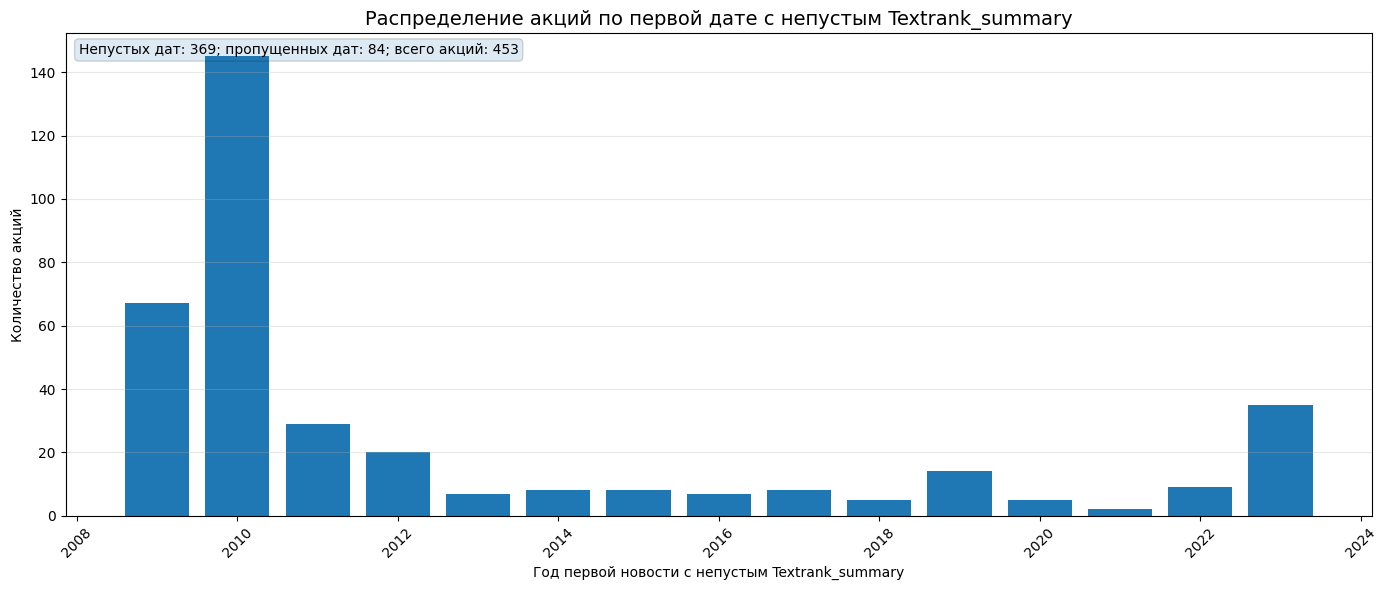

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions/distribution_textrank_news_min_date_by_year.png


,year,n_stocks
0,2009,67
1,2010,145
2,2011,29
3,2012,20
4,2013,7
5,2014,8
6,2015,8
7,2016,7
8,2017,8
9,2018,5


In [ ]:
textrank_min_year_counts = plot_stock_count_by_year(
    df=final_coverage_df,
    date_col='textrank_news_min_date',
    title='Распределение акций по первой дате с непустым Textrank_summary',
    xlabel='Год первой новости с непустым Textrank_summary',
    output_name='distribution_textrank_news_min_date_by_year.png'
)

display(textrank_min_year_counts)

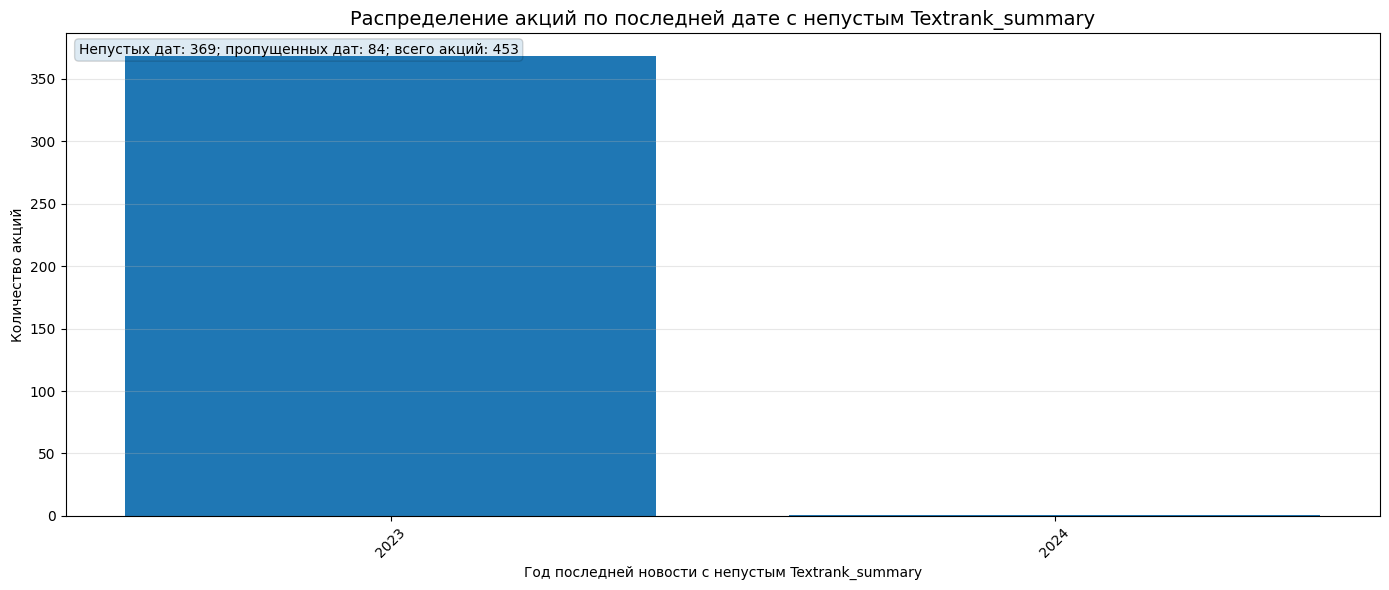

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions/distribution_textrank_news_max_date_by_year.png


,year,n_stocks
0,2023,368
1,2024,1


In [ ]:
textrank_max_year_counts = plot_stock_count_by_year(
    df=final_coverage_df,
    date_col='textrank_news_max_date',
    title='Распределение акций по последней дате с непустым Textrank_summary',
    xlabel='Год последней новости с непустым Textrank_summary',
    output_name='distribution_textrank_news_max_date_by_year.png'
)

display(textrank_max_year_counts)

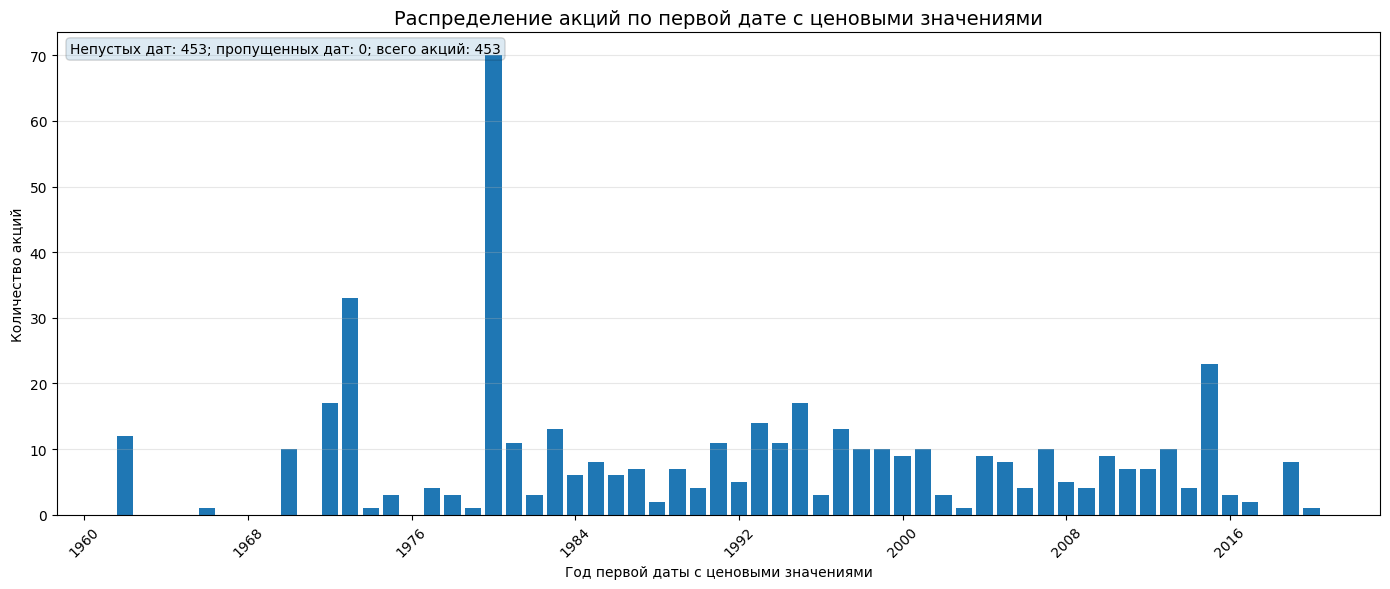

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions/distribution_price_min_date_by_year.png


,year,n_stocks
0,1962,12
1,1966,1
2,1970,10
3,1972,17
4,1973,33
5,1974,1
6,1975,3
7,1977,4
8,1978,3
9,1979,1


In [ ]:
price_min_year_counts = plot_stock_count_by_year(
    df=final_coverage_df,
    date_col='price_min_date',
    title='Распределение акций по первой дате с ценовыми значениями',
    xlabel='Год первой даты с ценовыми значениями',
    output_name='distribution_price_min_date_by_year.png'
)

display(price_min_year_counts)

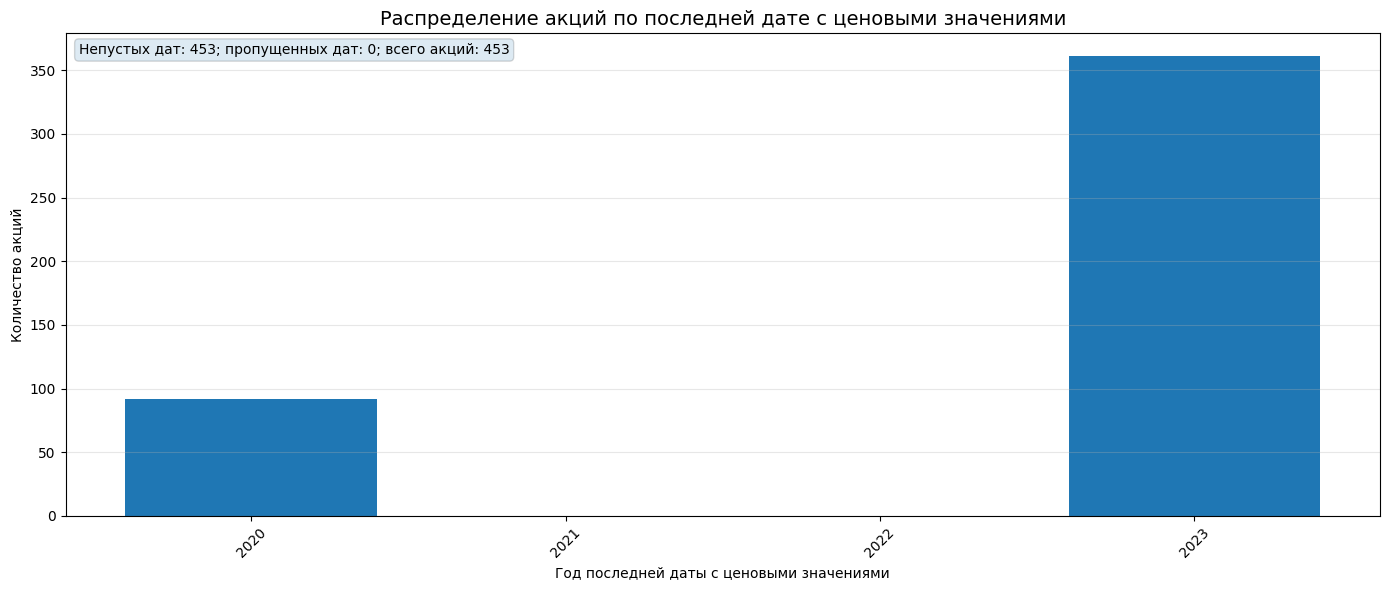

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions/distribution_price_max_date_by_year.png


,year,n_stocks
0,2020,92
1,2023,361


In [ ]:
price_max_year_counts = plot_stock_count_by_year(
    df=final_coverage_df,
    date_col='price_max_date',
    title='Распределение акций по последней дате с ценовыми значениями',
    xlabel='Год последней даты с ценовыми значениями',
    output_name='distribution_price_max_date_by_year.png'
)

display(price_max_year_counts)

In [ ]:
def make_year_count_table(df, date_col, count_col_name):
    temp = df[['ticker', date_col]].copy()
    temp[date_col] = pd.to_datetime(temp[date_col], errors='coerce')

    out = (
        temp
        .dropna(subset=[date_col])
        .assign(year=lambda x: x[date_col].dt.year)
        .groupby('year', as_index=False)
        .agg(**{count_col_name: ('ticker', 'nunique')})
    )

    return out


all_year_counts_df = (
    make_year_count_table(
        final_coverage_df,
        'textrank_news_min_date',
        'n_stocks_textrank_news_min_date'
    )
    .merge(
        make_year_count_table(
            final_coverage_df,
            'textrank_news_max_date',
            'n_stocks_textrank_news_max_date'
        ),
        on='year',
        how='outer'
    )
    .merge(
        make_year_count_table(
            final_coverage_df,
            'price_min_date',
            'n_stocks_price_min_date'
        ),
        on='year',
        how='outer'
    )
    .merge(
        make_year_count_table(
            final_coverage_df,
            'price_max_date',
            'n_stocks_price_max_date'
        ),
        on='year',
        how='outer'
    )
    .sort_values('year')
    .fillna(0)
)

count_cols = [col for col in all_year_counts_df.columns if col != 'year']
all_year_counts_df[count_cols] = all_year_counts_df[count_cols].astype(int)

display(all_year_counts_df)

all_year_counts_path = coverage_dir / 'date_distribution_counts_by_year.csv'
all_year_counts_df.to_csv(all_year_counts_path, index=False)

print('Saved:', all_year_counts_path)

,year,n_stocks_textrank_news_min_date,n_stocks_textrank_news_max_date,n_stocks_price_min_date,n_stocks_price_max_date
0,1962,0,0,12,0
1,1966,0,0,1,0
2,1970,0,0,10,0
3,1972,0,0,17,0
4,1973,0,0,33,0
5,1974,0,0,1,0
6,1975,0,0,3,0
7,1977,0,0,4,0
8,1978,0,0,3,0
9,1979,0,0,1,0


Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/date_distribution_counts_by_year.csv


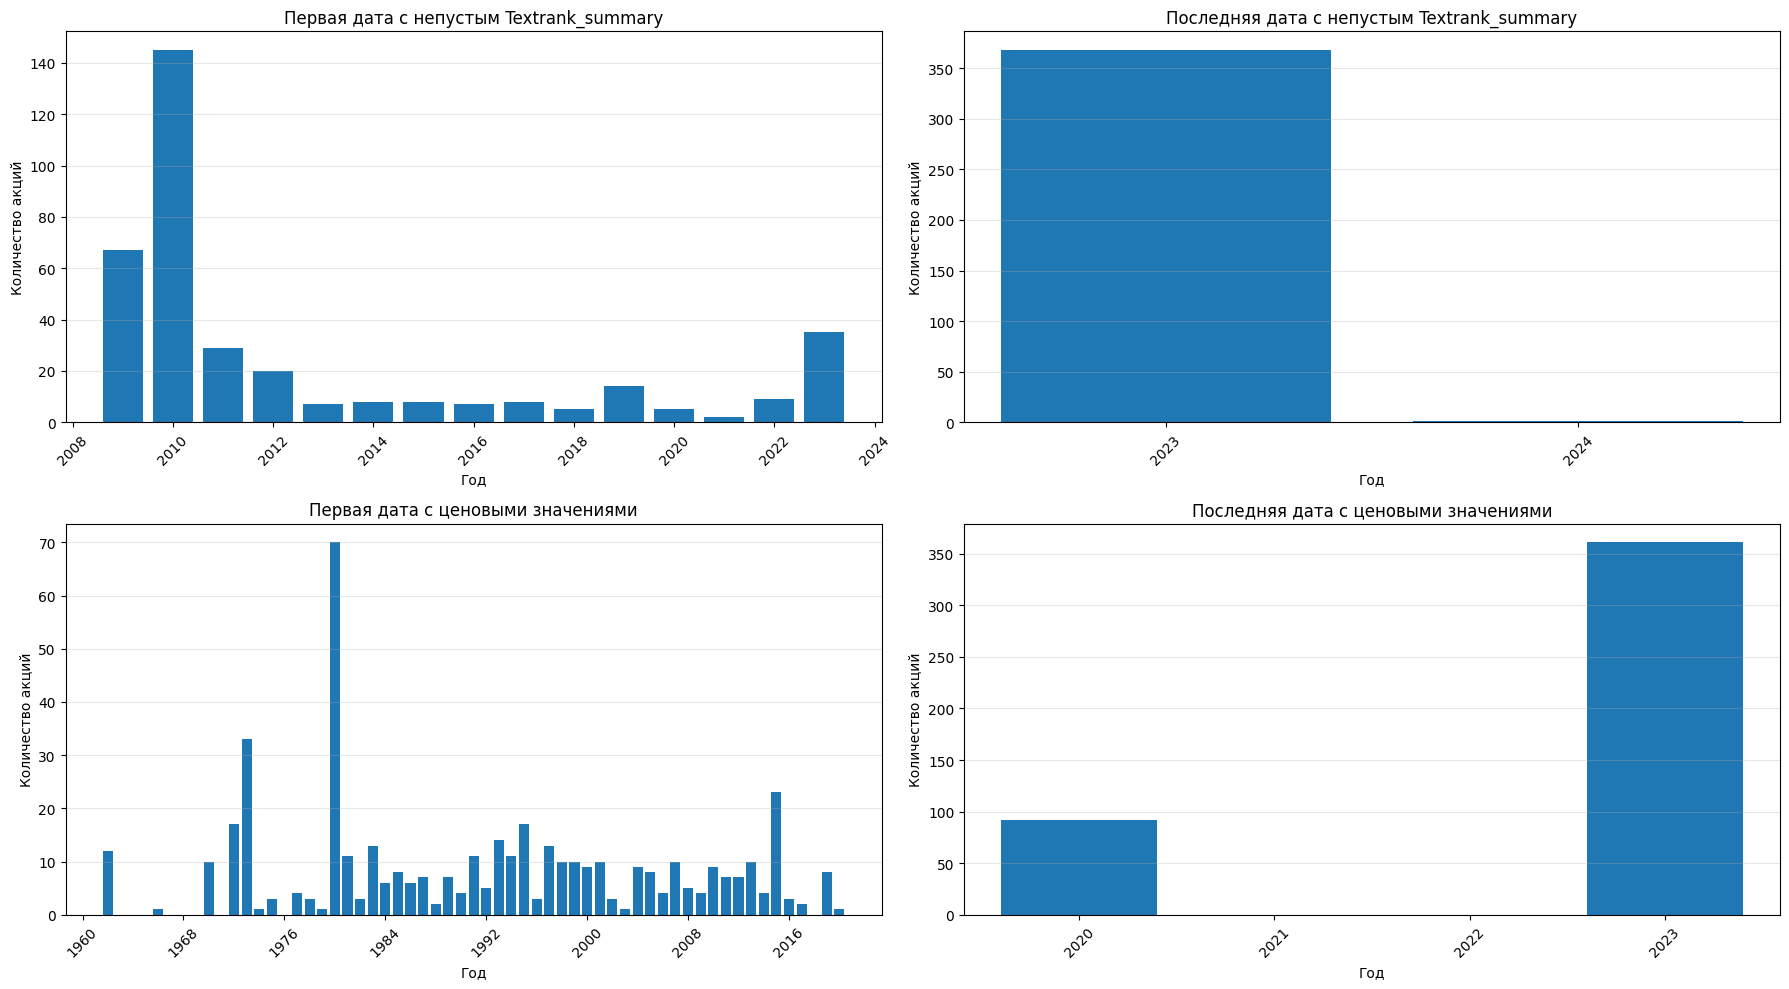

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions/combined_date_distributions_by_year.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

plot_specs = [
    (
        'textrank_news_min_date',
        'Первая дата с непустым Textrank_summary',
        axes[0, 0]
    ),
    (
        'textrank_news_max_date',
        'Последняя дата с непустым Textrank_summary',
        axes[0, 1]
    ),
    (
        'price_min_date',
        'Первая дата с ценовыми значениями',
        axes[1, 0]
    ),
    (
        'price_max_date',
        'Последняя дата с ценовыми значениями',
        axes[1, 1]
    )
]

for date_col, title, ax in plot_specs:
    temp = final_coverage_df[['ticker', date_col]].copy()
    temp[date_col] = pd.to_datetime(temp[date_col], errors='coerce')

    year_counts = (
        temp
        .dropna(subset=[date_col])
        .assign(year=lambda x: x[date_col].dt.year)
        .groupby('year', as_index=False)
        .agg(n_stocks=('ticker', 'nunique'))
        .sort_values('year')
    )

    ax.bar(year_counts['year'], year_counts['n_stocks'])
    ax.set_title(title)
    ax.set_xlabel('Год')
    ax.set_ylabel('Количество акций')
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

combined_plot_path = plots_dir / 'combined_date_distributions_by_year.png'
plt.savefig(combined_plot_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved:', combined_plot_path)

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
coverage_dir = Path('/content/fnspid_project/sp500_current_selection/coverage_tables')
plots_dir = coverage_dir / 'plots_date_distributions_by_sector'
plots_dir.mkdir(parents=True, exist_ok=True)

print('plots_dir:', plots_dir)

plots_dir: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions_by_sector


In [ ]:
date_cols = [
    'textrank_news_min_date',
    'textrank_news_max_date',
    'price_min_date',
    'price_max_date'
]

for col in date_cols:
    final_coverage_df[col] = pd.to_datetime(final_coverage_df[col], errors='coerce')

final_coverage_df['gics_sector'] = final_coverage_df['gics_sector'].fillna('Unknown')

print(final_coverage_df[date_cols].isna().sum())
display(final_coverage_df[['ticker', 'gics_sector'] + date_cols].head())

textrank_news_min_date    84
textrank_news_max_date    84
price_min_date             0
price_max_date             0
dtype: int64


,ticker,gics_sector,textrank_news_min_date,textrank_news_max_date,price_min_date,price_max_date
0,CHTR,Communication Services,2011-05-02,2023-12-16,2010-01-05,2023-12-28
1,CMCSA,Communication Services,2009-11-17,2023-12-16,1980-03-17,2023-12-28
2,DIS,Communication Services,2019-06-13,2023-12-16,1962-01-02,2023-12-28
3,EA,Communication Services,2011-12-22,2023-12-16,1989-09-20,2023-12-28
4,FOX,Communication Services,2019-06-05,2023-12-16,2019-03-13,2023-12-28


In [ ]:
def make_sector_year_distribution_table(df, date_col):
    work_df = df[['ticker', 'gics_sector', date_col]].copy()
    work_df[date_col] = pd.to_datetime(work_df[date_col], errors='coerce')

    grouped = (
        work_df
        .dropna(subset=[date_col])
        .assign(year=lambda x: x[date_col].dt.year)
        .groupby(['year', 'gics_sector'], as_index=False)
        .agg(n_stocks=('ticker', 'nunique'))
    )

    pivot_df = (
        grouped
        .pivot(index='year', columns='gics_sector', values='n_stocks')
        .fillna(0)
        .astype(int)
        .sort_index()
    )

    return pivot_df

In [ ]:
def plot_sector_stacked_distribution_by_year(
    df,
    date_col,
    title,
    xlabel,
    output_name,
    legend_outside=True
):
    pivot_df = make_sector_year_distribution_table(df, date_col)

    fig, ax = plt.subplots(figsize=(16, 7))

    bottom = np.zeros(len(pivot_df))

    for sector in pivot_df.columns:
        values = pivot_df[sector].values

        ax.bar(
            pivot_df.index,
            values,
            bottom=bottom,
            label=sector
        )

        bottom += values

    n_total = len(df)
    n_missing = df[date_col].isna().sum()
    n_nonmissing = n_total - n_missing

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Количество акций')
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    note = (
        f'Непустых дат: {n_nonmissing}; '
        f'пропущенных дат: {n_missing}; '
        f'всего акций: {n_total}'
    )

    ax.text(
        0.01,
        0.98,
        note,
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=10,
        bbox=dict(boxstyle='round', alpha=0.15)
    )

    if legend_outside:
        ax.legend(
            title='Сектор GICS',
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )
    else:
        ax.legend(title='Сектор GICS')

    plt.xticks(rotation=45)
    plt.tight_layout()

    output_path = plots_dir / output_name
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()

    print('Saved:', output_path)

    return pivot_df

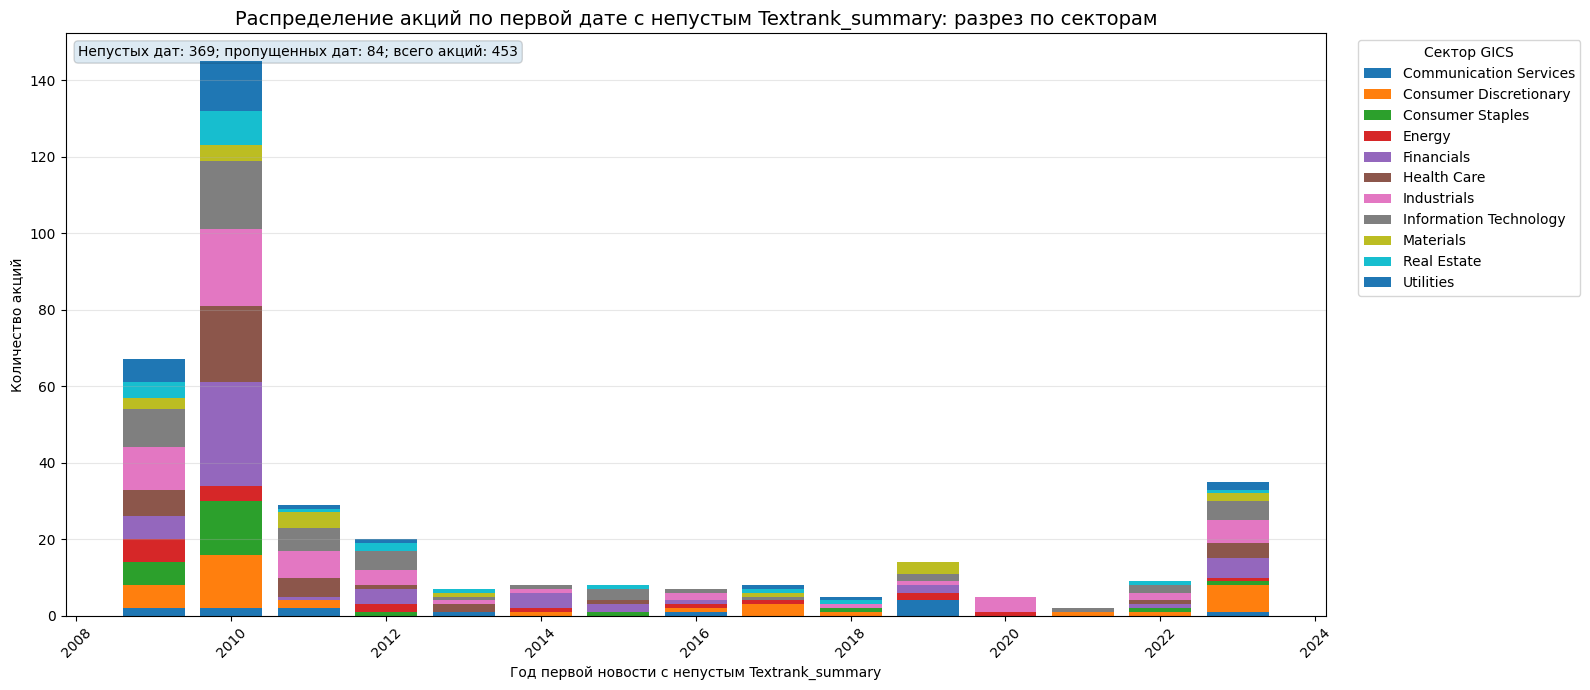

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions_by_sector/sector_distribution_textrank_news_min_date_by_year.png


gics_sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
year,,,,,,,,,,,
2009,2,6,6,6,6,7,11,10,3,4,6
2010,2,14,14,4,27,20,20,18,4,9,13
2011,2,2,0,0,1,5,7,6,4,1,1
2012,0,0,1,2,4,1,4,5,0,2,1
2013,1,0,0,0,0,2,1,1,1,1,0
2014,0,1,0,1,4,0,1,1,0,0,0
2015,0,0,1,0,2,1,0,3,0,1,0
2016,1,1,0,1,1,0,2,1,0,0,0
2017,0,3,0,1,0,0,0,1,1,1,1


In [ ]:
textrank_min_sector_year_df = plot_sector_stacked_distribution_by_year(
    df=final_coverage_df,
    date_col='textrank_news_min_date',
    title='Распределение акций по первой дате с непустым Textrank_summary: разрез по секторам',
    xlabel='Год первой новости с непустым Textrank_summary',
    output_name='sector_distribution_textrank_news_min_date_by_year.png'
)

display(textrank_min_sector_year_df)

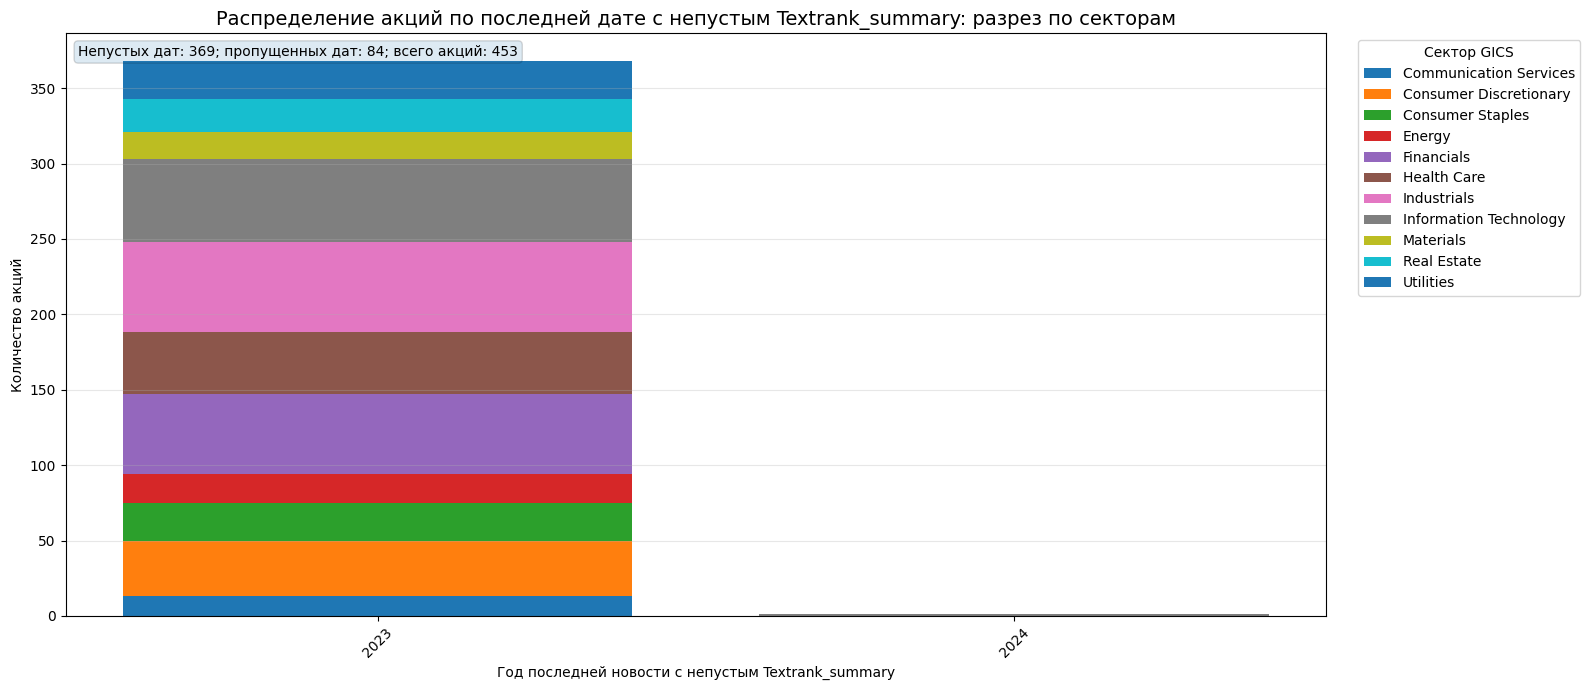

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions_by_sector/sector_distribution_textrank_news_max_date_by_year.png


gics_sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
year,,,,,,,,,,,
2023,13,37,25,19,53,41,60,55,18,22,25
2024,0,0,0,0,0,0,0,1,0,0,0


In [ ]:
textrank_max_sector_year_df = plot_sector_stacked_distribution_by_year(
    df=final_coverage_df,
    date_col='textrank_news_max_date',
    title='Распределение акций по последней дате с непустым Textrank_summary: разрез по секторам',
    xlabel='Год последней новости с непустым Textrank_summary',
    output_name='sector_distribution_textrank_news_max_date_by_year.png'
)

display(textrank_max_sector_year_df)

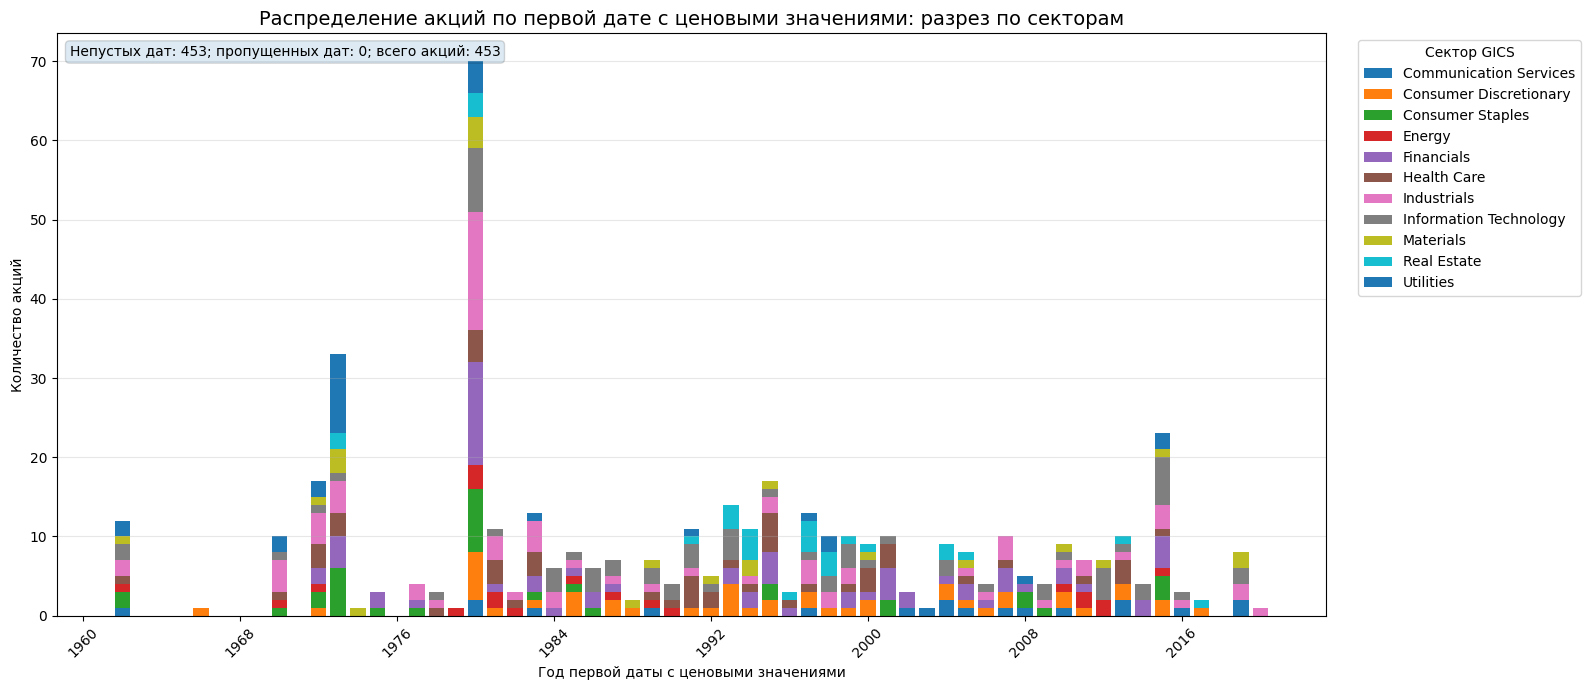

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions_by_sector/sector_distribution_price_min_date_by_year.png


gics_sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
year,,,,,,,,,,,
1962,1,0,2,1,0,1,2,2,1,0,2
1966,0,1,0,0,0,0,0,0,0,0,0
1970,0,0,1,1,0,1,4,1,0,0,2
1972,0,1,2,1,2,3,4,1,1,0,2
1973,0,0,6,0,4,3,4,1,3,2,10
1974,0,0,0,0,0,0,0,0,1,0,0
1975,0,0,1,0,2,0,0,0,0,0,0
1977,0,0,1,0,1,0,2,0,0,0,0
1978,0,0,0,0,0,1,1,1,0,0,0


In [ ]:
price_min_sector_year_df = plot_sector_stacked_distribution_by_year(
    df=final_coverage_df,
    date_col='price_min_date',
    title='Распределение акций по первой дате с ценовыми значениями: разрез по секторам',
    xlabel='Год первой даты с ценовыми значениями',
    output_name='sector_distribution_price_min_date_by_year.png'
)

display(price_min_sector_year_df)

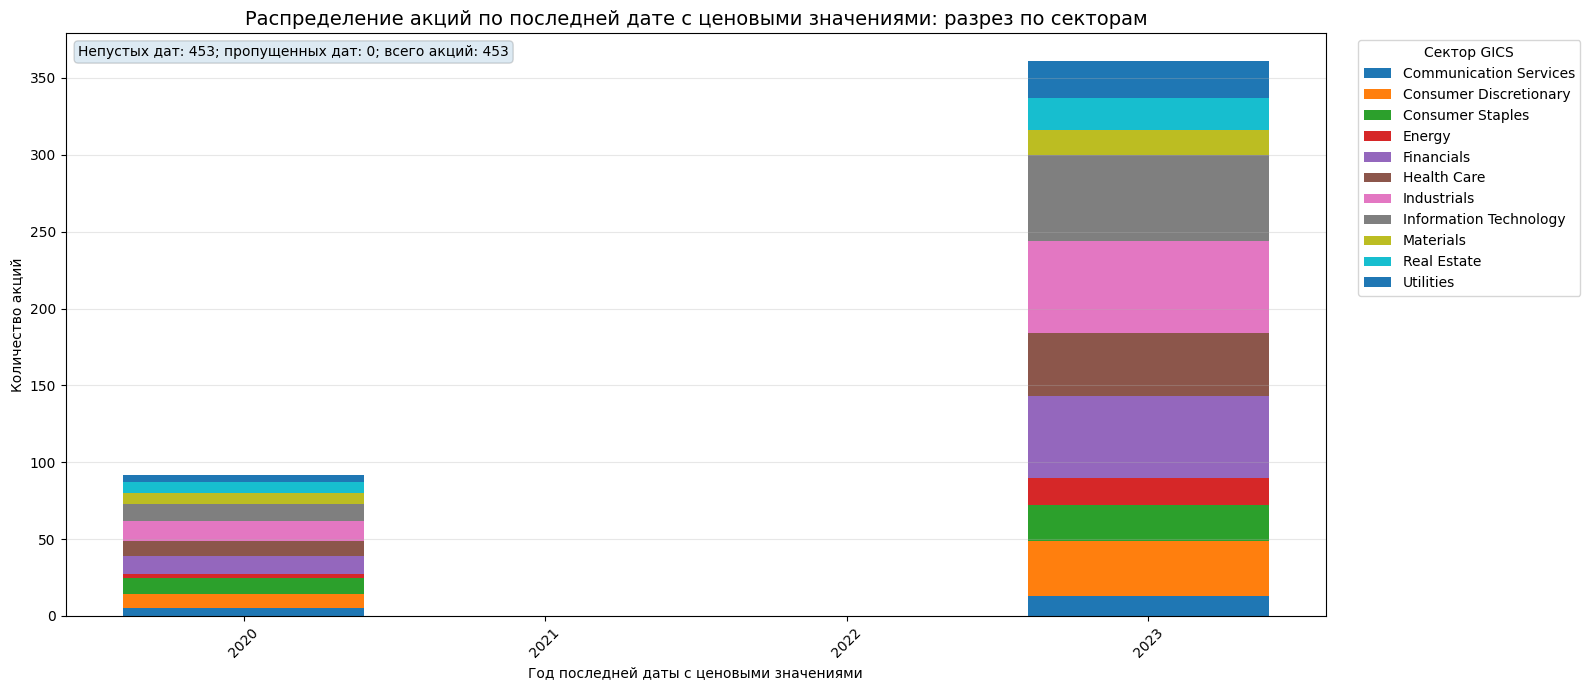

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions_by_sector/sector_distribution_price_max_date_by_year.png


gics_sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
year,,,,,,,,,,,
2020,5,9,11,2,12,10,13,11,7,7,5
2023,13,36,23,18,53,41,60,56,16,21,24


In [ ]:
price_max_sector_year_df = plot_sector_stacked_distribution_by_year(
    df=final_coverage_df,
    date_col='price_max_date',
    title='Распределение акций по последней дате с ценовыми значениями: разрез по секторам',
    xlabel='Год последней даты с ценовыми значениями',
    output_name='sector_distribution_price_max_date_by_year.png'
)

display(price_max_sector_year_df)

In [ ]:
sector_distribution_tables = {
    'textrank_news_min_date': textrank_min_sector_year_df,
    'textrank_news_max_date': textrank_max_sector_year_df,
    'price_min_date': price_min_sector_year_df,
    'price_max_date': price_max_sector_year_df
}

for name, table_df in sector_distribution_tables.items():
    output_path = coverage_dir / f'sector_distribution_{name}_by_year.csv'
    table_df.to_csv(output_path)
    print('Saved:', output_path)

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/sector_distribution_textrank_news_min_date_by_year.csv
Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/sector_distribution_textrank_news_max_date_by_year.csv
Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/sector_distribution_price_min_date_by_year.csv
Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/sector_distribution_price_max_date_by_year.csv


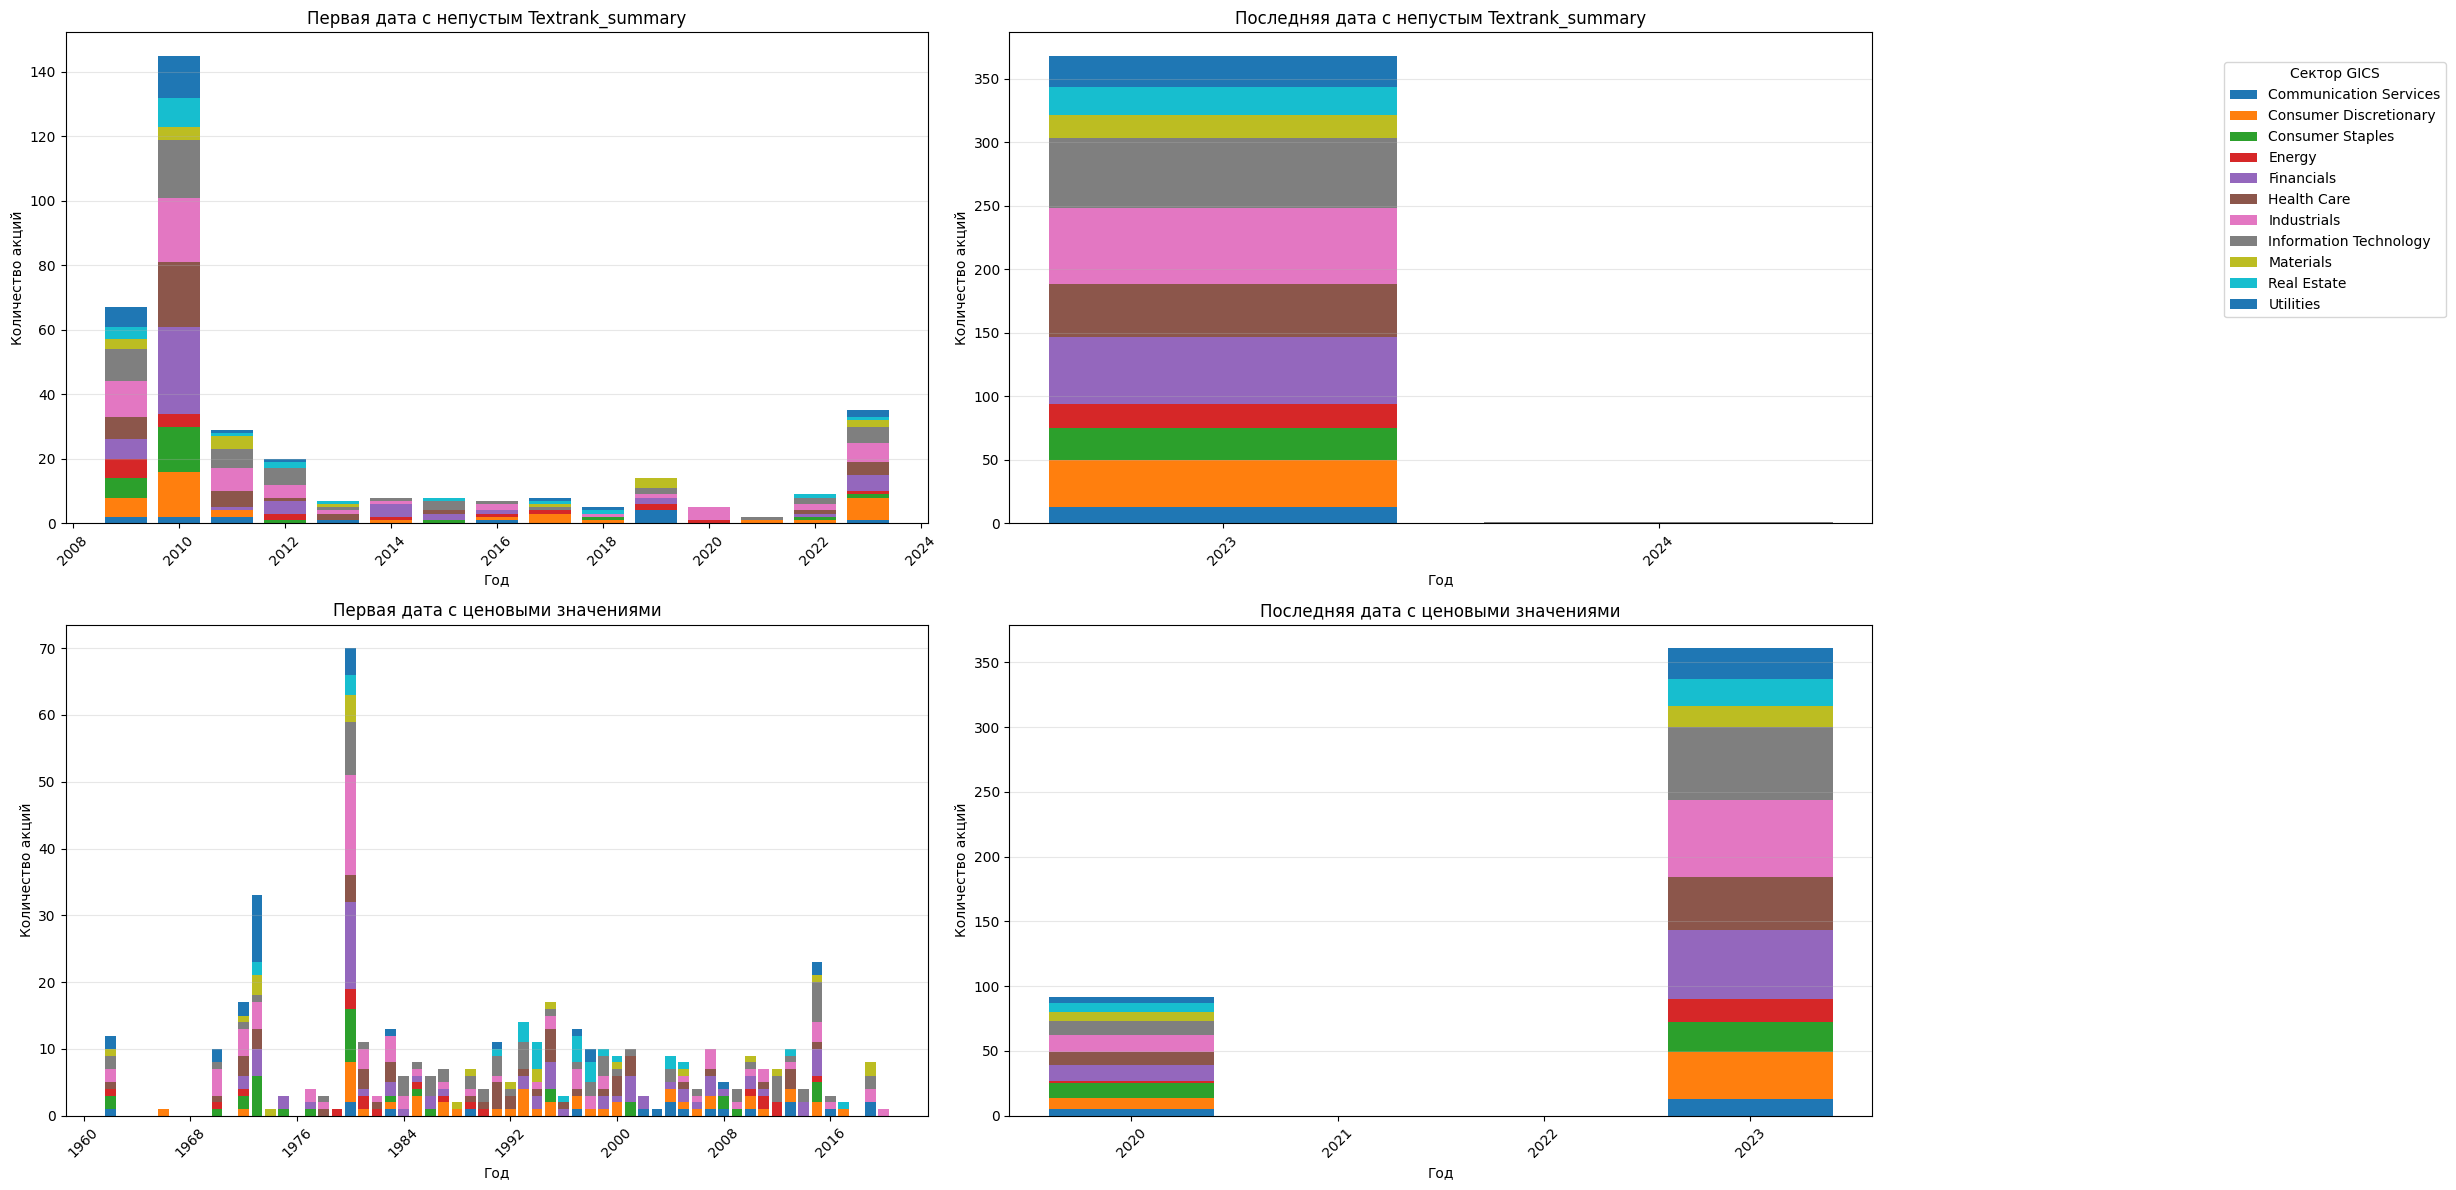

Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_date_distributions_by_sector/combined_sector_date_distributions_by_year.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(22, 12))

plot_specs = [
    (
        'textrank_news_min_date',
        'Первая дата с непустым Textrank_summary',
        axes[0, 0]
    ),
    (
        'textrank_news_max_date',
        'Последняя дата с непустым Textrank_summary',
        axes[0, 1]
    ),
    (
        'price_min_date',
        'Первая дата с ценовыми значениями',
        axes[1, 0]
    ),
    (
        'price_max_date',
        'Последняя дата с ценовыми значениями',
        axes[1, 1]
    )
]

handles = None
labels = None

for date_col, title, ax in plot_specs:
    pivot_df = make_sector_year_distribution_table(final_coverage_df, date_col)

    bottom = np.zeros(len(pivot_df))

    for sector in pivot_df.columns:
        values = pivot_df[sector].values

        ax.bar(
            pivot_df.index,
            values,
            bottom=bottom,
            label=sector
        )

        bottom += values

    ax.set_title(title)
    ax.set_xlabel('Год')
    ax.set_ylabel('Количество акций')
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.tick_params(axis='x', rotation=45)

    handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Сектор GICS',
    bbox_to_anchor=(1.01, 0.95),
    loc='upper left'
)

plt.tight_layout(rect=[0, 0, 0.86, 1])

combined_sector_plot_path = plots_dir / 'combined_sector_date_distributions_by_year.png'
plt.savefig(combined_sector_plot_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved:', combined_sector_plot_path)

In [ ]:
import gc
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import pandas_market_calendars as mcal
from tqdm.auto import tqdm

In [ ]:
period_start = pd.Timestamp('2009-01-01')
period_end = pd.Timestamp('2023-12-31')

project_dir = Path('/content/fnspid_project')
sp500_dir = project_dir / 'sp500_current_selection'

metadata_dir = sp500_dir / 'metadata'
prices_dir = sp500_dir / 'prices'
news_dir = sp500_dir / 'news'
coverage_dir = sp500_dir / 'coverage_tables'

price_parquet_dir = prices_dir / 'parquet_by_symbol'

coverage_dir.mkdir(parents=True, exist_ok=True)

print('period_start:', period_start.date())
print('period_end:', period_end.date())
print('price_parquet_dir:', price_parquet_dir)
print('news_dir:', news_dir)
print('coverage_dir:', coverage_dir)

period_start: 2009-01-01
period_end: 2023-12-31
price_parquet_dir: /content/fnspid_project/sp500_current_selection/prices/parquet_by_symbol
news_dir: /content/fnspid_project/sp500_current_selection/news
coverage_dir: /content/fnspid_project/sp500_current_selection/coverage_tables


In [ ]:
def show_resources(note=''):
    ram = psutil.virtual_memory()
    disk = shutil.disk_usage('/content')

    print('=' * 80)

    if note:
        print(note)

    print(f'RAM total: {ram.total / 1024 ** 3:.2f} GiB')
    print(f'RAM used:  {ram.used / 1024 ** 3:.2f} GiB')
    print(f'RAM free:  {ram.available / 1024 ** 3:.2f} GiB')

    print(f'Disk total: {disk.total / 1024 ** 3:.2f} GiB')
    print(f'Disk used:  {disk.used / 1024 ** 3:.2f} GiB')
    print(f'Disk free:  {disk.free / 1024 ** 3:.2f} GiB')

    print('=' * 80)


def normalize_colname(value):
    return str(value).strip().lower().replace(' ', '_')


def pick_existing_col(columns, candidates):
    col_map = {str(col).lower(): col for col in columns}

    for candidate in candidates:
        if candidate.lower() in col_map:
            return col_map[candidate.lower()]

    return None


def parse_date_series(series):
    parsed = pd.to_datetime(series, errors='coerce', utc=True)
    parsed = parsed.dt.tz_convert(None)
    return parsed.dt.normalize()


def is_nonempty_text(series):
    text = series.astype('string').str.strip()

    return (
        text.notna()
        & text.ne('')
        & text.str.lower().ne('nan')
        & text.str.lower().ne('none')
        & text.str.lower().ne('null')
    )


show_resources('Before building 2009-2023 coverage dataset')

Before building 2009-2023 coverage dataset
RAM total: 12.67 GiB
RAM used:  2.28 GiB
RAM free:  9.99 GiB
Disk total: 225.83 GiB
Disk used:  53.86 GiB
Disk free:  171.96 GiB


In [ ]:
nyse = mcal.get_calendar('NYSE')

nyse_schedule = nyse.schedule(
    start_date=period_start.date(),
    end_date=period_end.date()
)

period_trading_days = (
    pd.DatetimeIndex(nyse_schedule.index)
    .tz_localize(None)
    .normalize()
    .sort_values()
)

period_trading_day_set = set(period_trading_days)

n_period_trading_days = len(period_trading_days)

print('n_period_trading_days:', n_period_trading_days)
print('first trading day:', period_trading_days.min().date())
print('last trading day:', period_trading_days.max().date())

n_period_trading_days: 3774
first trading day: 2009-01-02
last trading day: 2023-12-29


In [ ]:
sp500_constituents_path = metadata_dir / 'sp500_current_constituents_with_gics.parquet'
sp500_price_files_path = metadata_dir / 'sp500_current_price_files_matched.csv'

sp500_constituents_df = pd.read_parquet(sp500_constituents_path)
sp500_price_files_df = pd.read_csv(sp500_price_files_path)

sp500_base_df = sp500_price_files_df[[
    'symbol_wiki',
    'symbol_key',
    'symbol_yahoo',
    'security',
    'gics_sector',
    'gics_sub_industry',
    'date_added',
    'cik',
    'price_path'
]].copy()

sp500_base_df = sp500_base_df.rename(columns={
    'symbol_wiki': 'ticker',
    'symbol_yahoo': 'ticker_yahoo',
    'date_added': 'sp500_date_added'
})

sp500_base_df['ticker'] = sp500_base_df['ticker'].astype(str).str.upper()

print('S&P 500 tickers with FNSPID price files:', len(sp500_base_df))
display(sp500_base_df.head())
display(sp500_base_df['gics_sector'].value_counts().sort_index())

S&P 500 tickers with FNSPID price files: 453


,ticker,symbol_key,ticker_yahoo,security,gics_sector,gics_sub_industry,sp500_date_added,cik,price_path
0,CHTR,CHTR,CHTR,Charter Communications,Communication Services,Cable & Satellite,2016-09-08,1091667,/content/fnspid_project/fnspid_raw/Stock_price...
1,CMCSA,CMCSA,CMCSA,Comcast,Communication Services,Cable & Satellite,2002-11-19,1166691,/content/fnspid_project/fnspid_raw/Stock_price...
2,DIS,DIS,DIS,Walt Disney Company (The),Communication Services,Movies & Entertainment,1976-06-30,1744489,/content/fnspid_project/fnspid_raw/Stock_price...
3,EA,EA,EA,Electronic Arts,Communication Services,Interactive Home Entertainment,2002-07-22,712515,/content/fnspid_project/fnspid_raw/Stock_price...
4,FOX,FOX,FOX,Fox Corporation (Class B),Communication Services,Broadcasting,2019-03-19,1754301,/content/fnspid_project/fnspid_raw/Stock_price...


gics_sector
Communication Services    18
Consumer Discretionary    45
Consumer Staples          34
Energy                    20
Financials                65
Health Care               51
Industrials               73
Information Technology    67
Materials                 23
Real Estate               28
Utilities                 29
Name: count, dtype: int64

In [ ]:
price_parquet_paths = sorted(price_parquet_dir.glob('*.parquet'))

print('Price parquet files:', len(price_parquet_paths))

Price parquet files: 453


In [ ]:
price_coverage_rows = []

for path in tqdm(price_parquet_paths, desc='Calculating price coverage'):
    sample_cols = pd.read_parquet(path, columns=None).columns
    normalized_cols = [normalize_colname(col) for col in sample_cols]

    col_rename_map = dict(zip(sample_cols, normalized_cols))

    needed_original_cols = []

    for original_col, normalized_col in col_rename_map.items():
        if normalized_col in [
            'symbol',
            'gics_sector',
            'date',
            'open',
            'high',
            'low',
            'close',
            'adj_close',
            'volume'
        ]:
            needed_original_cols.append(original_col)

    df = pd.read_parquet(path, columns=needed_original_cols)
    df = df.rename(columns=col_rename_map)

    date_col = pick_existing_col(df.columns, ['date'])
    symbol_col = pick_existing_col(df.columns, ['symbol'])
    sector_col = pick_existing_col(df.columns, ['gics_sector'])

    if date_col is None or symbol_col is None:
        raise ValueError(f'Cannot detect date/symbol columns in {path}')

    df[date_col] = pd.to_datetime(df[date_col], errors='coerce').dt.normalize()

    df = df.loc[
        (df[date_col] >= period_start)
        & (df[date_col] <= period_end)
    ].copy()

    price_value_cols = [
        col for col in ['open', 'high', 'low', 'close', 'adj_close', 'volume']
        if col in df.columns
    ]

    if len(price_value_cols) > 0:
        valid_price_mask = (
            df[date_col].notna()
            & df[date_col].isin(period_trading_day_set)
            & df[price_value_cols].notna().all(axis=1)
        )
    else:
        valid_price_mask = (
            df[date_col].notna()
            & df[date_col].isin(period_trading_day_set)
        )

    valid_price_dates = pd.DatetimeIndex(
        df.loc[valid_price_mask, date_col]
        .dropna()
        .drop_duplicates()
        .sort_values()
    )

    ticker = (
        df[symbol_col].dropna().iloc[0]
        if len(df) > 0 and df[symbol_col].notna().any()
        else path.stem.replace('_', '.')
    )

    sector = (
        df[sector_col].dropna().iloc[0]
        if sector_col is not None and len(df) > 0 and df[sector_col].notna().any()
        else None
    )

    price_coverage_rows.append({
        'ticker': ticker,
        'gics_sector_from_price_file': sector,
        'price_min_date_2009_2023': valid_price_dates.min() if len(valid_price_dates) > 0 else pd.NaT,
        'price_max_date_2009_2023': valid_price_dates.max() if len(valid_price_dates) > 0 else pd.NaT,
        'n_price_trading_days_with_full_info_2009_2023': len(valid_price_dates),
        'price_trading_day_share_2009_2023': len(valid_price_dates) / n_period_trading_days
    })

    del df
    gc.collect()

price_period_coverage_df = pd.DataFrame(price_coverage_rows)

print('price_period_coverage_df shape:', price_period_coverage_df.shape)
display(price_period_coverage_df.head())
display(price_period_coverage_df['price_trading_day_share_2009_2023'].describe())

Calculating price coverage:   0%|          | 0/453 [00:00<?, ?it/s]

price_period_coverage_df shape: (453, 6)


,ticker,gics_sector_from_price_file,price_min_date_2009_2023,price_max_date_2009_2023,n_price_trading_days_with_full_info_2009_2023,price_trading_day_share_2009_2023
0,A,Health Care,2009-01-02,2023-12-28,3773,0.999735
1,AAPL,Information Technology,2009-01-02,2023-12-28,3773,0.999735
2,ABBV,Health Care,2013-01-02,2023-12-28,2767,0.733174
3,ABT,Health Care,2009-01-02,2023-12-28,3773,0.999735
4,ACGL,Financials,2009-01-02,2023-12-28,3773,0.999735


count    453.000000
mean       0.890781
std        0.192614
min        0.033916
25%        0.767091
50%        0.999735
75%        0.999735
max        0.999735
Name: price_trading_day_share_2009_2023, dtype: float64

In [ ]:
news_part_paths = sorted(news_dir.glob('* /parquet_parts/*.parquet'.replace(' ', '')))

print('News parquet parts:', len(news_part_paths))

if len(news_part_paths) == 0:
    raise FileNotFoundError('No news parquet parts found.')

News parquet parts: 92


In [ ]:
sample_news_df = pd.read_parquet(news_part_paths[0])

print('Sample news columns:')
print(list(sample_news_df.columns))

news_symbol_col = pick_existing_col(sample_news_df.columns, ['symbol'])
news_sector_col = pick_existing_col(sample_news_df.columns, ['gics_sector'])

news_date_col = pick_existing_col(sample_news_df.columns, [
    'Date',
    'date',
    'datetime',
    'Datetime',
    'published_date',
    'Published_date',
    'published',
    'Published',
    'time',
    'Time'
])

news_textrank_col = pick_existing_col(sample_news_df.columns, [
    'Textrank_summary',
    'textrank_summary',
    'TextRank_summary',
    'textrank',
    'TextRank'
])

print('news_symbol_col:', news_symbol_col)
print('news_sector_col:', news_sector_col)
print('news_date_col:', news_date_col)
print('news_textrank_col:', news_textrank_col)

if news_symbol_col is None:
    raise ValueError('Cannot detect symbol column in news parts.')

if news_date_col is None:
    raise ValueError('Cannot detect date column in news parts.')

if news_textrank_col is None:
    raise ValueError('Cannot detect Textrank_summary column in news parts.')

del sample_news_df
gc.collect()

Sample news columns:
['symbol', 'symbol_key', 'symbol_yahoo', 'security', 'gics_sector', 'gics_sub_industry', 'sp500_date_added', 'cik', 'news_source', 'source_news_file', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']
news_symbol_col: symbol
news_sector_col: gics_sector
news_date_col: Date
news_textrank_col: Textrank_summary


19

In [ ]:
news_daily_parts = []

needed_news_cols = [
    news_symbol_col,
    news_date_col,
    news_textrank_col
]

needed_news_cols = list(dict.fromkeys(needed_news_cols))

for path in tqdm(news_part_paths, desc='Calculating news coverage'):
    df = pd.read_parquet(path, columns=needed_news_cols)

    df = df.rename(columns={
        news_symbol_col: 'ticker',
        news_date_col: 'news_date',
        news_textrank_col: 'textrank_summary'
    })

    df['ticker'] = df['ticker'].astype(str).str.upper()
    df['news_date'] = parse_date_series(df['news_date'])

    mask = (
        df['ticker'].notna()
        & df['news_date'].notna()
        & (df['news_date'] >= period_start)
        & (df['news_date'] <= period_end)
        & df['news_date'].isin(period_trading_day_set)
        & is_nonempty_text(df['textrank_summary'])
    )

    df = df.loc[mask, ['ticker', 'news_date', 'textrank_summary']].copy()

    if len(df) > 0:
        daily_part = (
            df
            .groupby(['ticker', 'news_date'], as_index=False)
            .agg(n_textrank_news=('textrank_summary', 'size'))
        )

        news_daily_parts.append(daily_part)

        del daily_part

    del df
    gc.collect()

if len(news_daily_parts) > 0:
    news_daily_period_df = (
        pd.concat(news_daily_parts, ignore_index=True)
        .groupby(['ticker', 'news_date'], as_index=False)
        .agg(n_textrank_news=('n_textrank_news', 'sum'))
    )
else:
    news_daily_period_df = pd.DataFrame(columns=[
        'ticker',
        'news_date',
        'n_textrank_news'
    ])

print('news_daily_period_df shape:', news_daily_period_df.shape)
display(news_daily_period_df.head())

Calculating news coverage:   0%|          | 0/92 [00:00<?, ?it/s]

news_daily_period_df shape: (321091, 3)


,ticker,news_date,n_textrank_news
0,A,2022-09-15,1
1,A,2022-09-16,2
2,A,2022-09-29,1
3,A,2022-10-04,1
4,A,2022-10-05,1


In [ ]:
news_period_coverage_df = (
    news_daily_period_df
    .groupby('ticker', as_index=False)
    .agg(
        textrank_news_min_date_2009_2023=('news_date', 'min'),
        textrank_news_max_date_2009_2023=('news_date', 'max'),
        n_trading_days_with_textrank_news_2009_2023=('news_date', 'nunique'),
        n_total_textrank_news_2009_2023=('n_textrank_news', 'sum')
    )
)

news_period_coverage_df['textrank_news_trading_day_share_2009_2023'] = (
    news_period_coverage_df['n_trading_days_with_textrank_news_2009_2023']
    / n_period_trading_days
)

news_period_coverage_df['n_total_textrank_news_2009_2023'] = (
    news_period_coverage_df['n_total_textrank_news_2009_2023']
    .astype(int)
)

print('news_period_coverage_df shape:', news_period_coverage_df.shape)
display(news_period_coverage_df.head())
display(news_period_coverage_df['textrank_news_trading_day_share_2009_2023'].describe())

news_period_coverage_df shape: (363, 6)


,ticker,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_total_textrank_news_2009_2023,textrank_news_trading_day_share_2009_2023
0,A,2022-09-15,2023-12-12,170,372,0.045045
1,AAPL,2022-06-03,2023-12-15,387,7970,0.102544
2,ABBV,2013-01-03,2023-12-14,2029,5021,0.537626
3,ABT,2009-11-04,2023-12-14,1778,3700,0.471118
4,ACGL,2010-06-01,2023-12-13,697,1158,0.184685


count    363.000000
mean       0.234379
std        0.149653
min        0.000265
25%        0.127318
50%        0.212772
75%        0.311473
max        0.672761
Name: textrank_news_trading_day_share_2009_2023, dtype: float64

In [ ]:
period_coverage_df = (
    sp500_base_df[[
        'ticker',
        'gics_sector',
        'security',
        'gics_sub_industry',
        'ticker_yahoo',
        'symbol_key',
        'sp500_date_added',
        'cik'
    ]]
    .merge(
        price_period_coverage_df.drop(columns=['gics_sector_from_price_file']),
        on='ticker',
        how='left'
    )
    .merge(
        news_period_coverage_df,
        on='ticker',
        how='left'
    )
)

period_coverage_df['n_trading_days_in_period_2009_2023'] = n_period_trading_days

period_coverage_df['textrank_news_trading_day_share_2009_2023'] = (
    period_coverage_df['textrank_news_trading_day_share_2009_2023']
    .fillna(0.0)
)

period_coverage_df['n_trading_days_with_textrank_news_2009_2023'] = (
    period_coverage_df['n_trading_days_with_textrank_news_2009_2023']
    .fillna(0)
    .astype(int)
)

period_coverage_df['n_total_textrank_news_2009_2023'] = (
    period_coverage_df['n_total_textrank_news_2009_2023']
    .fillna(0)
    .astype(int)
)

period_coverage_df['price_trading_day_share_2009_2023'] = (
    period_coverage_df['price_trading_day_share_2009_2023']
    .fillna(0.0)
)

period_coverage_df['n_price_trading_days_with_full_info_2009_2023'] = (
    period_coverage_df['n_price_trading_days_with_full_info_2009_2023']
    .fillna(0)
    .astype(int)
)

period_coverage_df = period_coverage_df[[
    'ticker',
    'gics_sector',
    'textrank_news_trading_day_share_2009_2023',
    'price_trading_day_share_2009_2023',
    'n_total_textrank_news_2009_2023',
    'textrank_news_min_date_2009_2023',
    'textrank_news_max_date_2009_2023',
    'price_min_date_2009_2023',
    'price_max_date_2009_2023',
    'n_trading_days_with_textrank_news_2009_2023',
    'n_price_trading_days_with_full_info_2009_2023',
    'n_trading_days_in_period_2009_2023',
    'security',
    'gics_sub_industry',
    'ticker_yahoo',
    'symbol_key',
    'sp500_date_added',
    'cik'
]].copy()

period_coverage_df = period_coverage_df.sort_values(
    [
        'gics_sector',
        'textrank_news_trading_day_share_2009_2023',
        'price_trading_day_share_2009_2023',
        'n_total_textrank_news_2009_2023'
    ],
    ascending=[True, False, False, False]
).reset_index(drop=True)

print('period_coverage_df shape:', period_coverage_df.shape)
display(period_coverage_df.head(30))

period_coverage_df shape: (453, 18)


,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,n_total_textrank_news_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,n_trading_days_in_period_2009_2023,security,gics_sub_industry,ticker_yahoo,symbol_key,sp500_date_added,cik
0,CMCSA,Communication Services,0.665607,0.999735,6316,2009-11-17,2023-12-15,2009-01-02,2023-12-28,2512,3773,3774,Comcast,Cable & Satellite,CMCSA,CMCSA,2002-11-19,1166691
1,T,Communication Services,0.485957,0.999735,8640,2016-06-20,2023-12-15,2009-01-02,2023-12-28,1834,3773,3774,AT&T,Integrated Telecommunication Services,T,T,1983-11-30,732717
2,TMUS,Communication Services,0.475093,0.999735,3751,2013-05-01,2023-12-15,2009-01-02,2023-12-28,1793,3773,3774,T-Mobile US,Wireless Telecommunication Services,TMUS,TMUS,2019-07-15,1283699
3,EA,Communication Services,0.427398,0.999735,2958,2011-12-22,2023-12-11,2009-01-02,2023-12-28,1613,3773,3774,Electronic Arts,Interactive Home Entertainment,EA,EA,2002-07-22,712515
4,TTWO,Communication Services,0.328034,0.999735,2223,2010-05-26,2023-12-15,2009-01-02,2023-12-28,1238,3773,3774,Take-Two Interactive,Interactive Home Entertainment,TTWO,TTWO,2018-03-19,946581
5,GOOG,Communication Services,0.320880,0.999735,7457,2019-02-06,2023-12-15,2009-01-02,2023-12-28,1211,3773,3774,Alphabet Inc. (Class C),Interactive Media & Services,GOOG,GOOG,2014-04-03,1652044
6,DIS,Communication Services,0.298887,0.999735,7628,2019-06-13,2023-12-14,2009-01-02,2023-12-28,1128,3773,3774,Walt Disney Company (The),Movies & Entertainment,DIS,DIS,1976-06-30,1744489
7,CHTR,Communication Services,0.287228,0.932697,1698,2011-05-02,2023-12-12,2010-01-05,2023-12-28,1084,3520,3774,Charter Communications,Cable & Satellite,CHTR,CHTR,2016-09-08,1091667
8,NWSA,Communication Services,0.215686,0.702438,1186,2010-04-27,2023-12-13,2013-06-19,2023-12-28,814,2651,3774,News Corp (Class A),Publishing,NWSA,NWSA,2013-08-01,1564708
9,FOXA,Communication Services,0.116322,0.320615,750,2019-05-24,2023-12-12,2019-03-12,2023-12-28,439,1210,3774,Fox Corporation (Class A),Broadcasting,FOXA,FOXA,2019-03-19,1754301


In [ ]:
period_coverage_csv_path = coverage_dir / 'sp500_current_coverage_2009_2023_price_textrank_by_ticker.csv'
period_coverage_parquet_path = coverage_dir / 'sp500_current_coverage_2009_2023_price_textrank_by_ticker.parquet'

period_coverage_df.to_csv(period_coverage_csv_path, index=False)
period_coverage_df.to_parquet(period_coverage_parquet_path, index=False)

print('Saved:')
print(period_coverage_csv_path)
print(period_coverage_parquet_path)

Saved:
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_coverage_2009_2023_price_textrank_by_ticker.csv
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_coverage_2009_2023_price_textrank_by_ticker.parquet


In [ ]:
ranking_cols = [
    'textrank_news_trading_day_share_2009_2023',
    'price_trading_day_share_2009_2023',
    'textrank_news_min_date_2009_2023',
    'price_min_date_2009_2023'
]

for col in ranking_cols:
    if col not in period_coverage_df.columns:
        raise ValueError(f'Column not found: {col}')

period_coverage_ranked_df = period_coverage_df.copy()

period_coverage_ranked_df['textrank_news_min_date_2009_2023'] = pd.to_datetime(
    period_coverage_ranked_df['textrank_news_min_date_2009_2023'],
    errors='coerce'
)

period_coverage_ranked_df['price_min_date_2009_2023'] = pd.to_datetime(
    period_coverage_ranked_df['price_min_date_2009_2023'],
    errors='coerce'
)

period_coverage_ranked_df['textrank_news_max_date_2009_2023'] = pd.to_datetime(
    period_coverage_ranked_df['textrank_news_max_date_2009_2023'],
    errors='coerce'
)

period_coverage_ranked_df['price_max_date_2009_2023'] = pd.to_datetime(
    period_coverage_ranked_df['price_max_date_2009_2023'],
    errors='coerce'
)

period_coverage_ranked_df = (
    period_coverage_ranked_df
    .sort_values(
        by=[
            'gics_sector',
            'textrank_news_trading_day_share_2009_2023',
            'price_trading_day_share_2009_2023',
            'textrank_news_min_date_2009_2023',
            'price_min_date_2009_2023'
        ],
        ascending=[
            True,
            False,
            False,
            True,
            True
        ],
        na_position='last'
    )
    .reset_index(drop=True)
)

period_coverage_ranked_df['sector_rank'] = (
    period_coverage_ranked_df
    .groupby('gics_sector')
    .cumcount()
    .add(1)
)

top10_by_sector_df = (
    period_coverage_ranked_df
    .loc[period_coverage_ranked_df['sector_rank'] <= 10]
    .copy()
    .reset_index(drop=True)
)

print('Ranked dataframe shape:', period_coverage_ranked_df.shape)
print('Top-10 by sector dataframe shape:', top10_by_sector_df.shape)

display(top10_by_sector_df.head(30))

Ranked dataframe shape: (453, 19)
Top-10 by sector dataframe shape: (110, 19)


,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,n_total_textrank_news_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,n_trading_days_in_period_2009_2023,security,gics_sub_industry,ticker_yahoo,symbol_key,sp500_date_added,cik,sector_rank
0,CMCSA,Communication Services,0.665607,0.999735,6316,2009-11-17,2023-12-15,2009-01-02,2023-12-28,2512,3773,3774,Comcast,Cable & Satellite,CMCSA,CMCSA,2002-11-19,1166691,1
1,T,Communication Services,0.485957,0.999735,8640,2016-06-20,2023-12-15,2009-01-02,2023-12-28,1834,3773,3774,AT&T,Integrated Telecommunication Services,T,T,1983-11-30,732717,2
2,TMUS,Communication Services,0.475093,0.999735,3751,2013-05-01,2023-12-15,2009-01-02,2023-12-28,1793,3773,3774,T-Mobile US,Wireless Telecommunication Services,TMUS,TMUS,2019-07-15,1283699,3
3,EA,Communication Services,0.427398,0.999735,2958,2011-12-22,2023-12-11,2009-01-02,2023-12-28,1613,3773,3774,Electronic Arts,Interactive Home Entertainment,EA,EA,2002-07-22,712515,4
4,TTWO,Communication Services,0.328034,0.999735,2223,2010-05-26,2023-12-15,2009-01-02,2023-12-28,1238,3773,3774,Take-Two Interactive,Interactive Home Entertainment,TTWO,TTWO,2018-03-19,946581,5
5,GOOG,Communication Services,0.320880,0.999735,7457,2019-02-06,2023-12-15,2009-01-02,2023-12-28,1211,3773,3774,Alphabet Inc. (Class C),Interactive Media & Services,GOOG,GOOG,2014-04-03,1652044,6
6,DIS,Communication Services,0.298887,0.999735,7628,2019-06-13,2023-12-14,2009-01-02,2023-12-28,1128,3773,3774,Walt Disney Company (The),Movies & Entertainment,DIS,DIS,1976-06-30,1744489,7
7,CHTR,Communication Services,0.287228,0.932697,1698,2011-05-02,2023-12-12,2010-01-05,2023-12-28,1084,3520,3774,Charter Communications,Cable & Satellite,CHTR,CHTR,2016-09-08,1091667,8
8,NWSA,Communication Services,0.215686,0.702438,1186,2010-04-27,2023-12-13,2013-06-19,2023-12-28,814,2651,3774,News Corp (Class A),Publishing,NWSA,NWSA,2013-08-01,1564708,9
9,FOXA,Communication Services,0.116322,0.320615,750,2019-05-24,2023-12-12,2019-03-12,2023-12-28,439,1210,3774,Fox Corporation (Class A),Broadcasting,FOXA,FOXA,2019-03-19,1754301,10


In [ ]:
display_cols = [
    'sector_rank',
    'ticker',
    'gics_sector',
    'textrank_news_trading_day_share_2009_2023',
    'price_trading_day_share_2009_2023',
    'textrank_news_min_date_2009_2023',
    'textrank_news_max_date_2009_2023',
    'price_min_date_2009_2023',
    'price_max_date_2009_2023',
    'n_total_textrank_news_2009_2023',
    'n_trading_days_with_textrank_news_2009_2023',
    'n_price_trading_days_with_full_info_2009_2023',
    'security',
    'gics_sub_industry'
]

display_cols = [
    col for col in display_cols
    if col in top10_by_sector_df.columns
]

for sector in sorted(top10_by_sector_df['gics_sector'].dropna().unique()):
    print('\n' + '=' * 120)
    print(f'Sector: {sector}')
    print('=' * 120)

    sector_top10_df = (
        top10_by_sector_df
        .loc[top10_by_sector_df['gics_sector'] == sector, display_cols]
        .copy()
    )

    display(sector_top10_df)


Sector: Communication Services


,sector_rank,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_total_textrank_news_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,security,gics_sub_industry
0,1,CMCSA,Communication Services,0.665607,0.999735,2009-11-17,2023-12-15,2009-01-02,2023-12-28,6316,2512,3773,Comcast,Cable & Satellite
1,2,T,Communication Services,0.485957,0.999735,2016-06-20,2023-12-15,2009-01-02,2023-12-28,8640,1834,3773,AT&T,Integrated Telecommunication Services
2,3,TMUS,Communication Services,0.475093,0.999735,2013-05-01,2023-12-15,2009-01-02,2023-12-28,3751,1793,3773,T-Mobile US,Wireless Telecommunication Services
3,4,EA,Communication Services,0.427398,0.999735,2011-12-22,2023-12-11,2009-01-02,2023-12-28,2958,1613,3773,Electronic Arts,Interactive Home Entertainment
4,5,TTWO,Communication Services,0.328034,0.999735,2010-05-26,2023-12-15,2009-01-02,2023-12-28,2223,1238,3773,Take-Two Interactive,Interactive Home Entertainment
5,6,GOOG,Communication Services,0.320880,0.999735,2019-02-06,2023-12-15,2009-01-02,2023-12-28,7457,1211,3773,Alphabet Inc. (Class C),Interactive Media & Services
6,7,DIS,Communication Services,0.298887,0.999735,2019-06-13,2023-12-14,2009-01-02,2023-12-28,7628,1128,3773,Walt Disney Company (The),Movies & Entertainment
7,8,CHTR,Communication Services,0.287228,0.932697,2011-05-02,2023-12-12,2010-01-05,2023-12-28,1698,1084,3520,Charter Communications,Cable & Satellite
8,9,NWSA,Communication Services,0.215686,0.702438,2010-04-27,2023-12-13,2013-06-19,2023-12-28,1186,814,2651,News Corp (Class A),Publishing
9,10,FOXA,Communication Services,0.116322,0.320615,2019-05-24,2023-12-12,2019-03-12,2023-12-28,750,439,1210,Fox Corporation (Class A),Broadcasting



Sector: Consumer Discretionary


,sector_rank,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_total_textrank_news_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,security,gics_sub_industry
10,1,NKE,Consumer Discretionary,0.613408,0.999735,2009-12-02,2023-12-15,2009-01-02,2023-12-28,6549,2315,3773,"Nike, Inc.","Apparel, Accessories & Luxury Goods"
11,2,SBUX,Consumer Discretionary,0.537891,0.366985,2014-08-22,2023-12-15,2015-01-02,2020-07-02,5966,2030,1385,Starbucks,Restaurants
12,3,EBAY,Consumer Discretionary,0.512189,0.999735,2009-10-15,2023-12-15,2009-01-02,2023-12-28,3831,1933,3773,eBay Inc.,Broadline Retail
13,4,CMG,Consumer Discretionary,0.505034,0.999735,2009-10-16,2023-12-15,2009-01-02,2023-12-28,4348,1906,3773,Chipotle Mexican Grill,Restaurants
14,5,BBY,Consumer Discretionary,0.474033,0.999735,2010-01-12,2023-12-13,2009-01-02,2023-12-28,3970,1789,3773,Best Buy,Computer & Electronics Retail
15,6,MGM,Consumer Discretionary,0.388447,0.767091,2010-02-09,2023-12-14,2009-01-02,2020-07-02,2608,1466,2895,MGM Resorts,Casinos & Gaming
16,7,DHI,Consumer Discretionary,0.365395,0.999735,2010-02-03,2023-12-15,2009-01-02,2023-12-28,2354,1379,3773,D. R. Horton,Homebuilding
17,8,TJX,Consumer Discretionary,0.365395,0.999735,2010-04-09,2023-12-15,2009-01-02,2023-12-28,2447,1379,3773,TJX Companies,Apparel Retail
18,9,EXPE,Consumer Discretionary,0.358506,0.999735,2010-04-28,2023-12-15,2009-01-02,2023-12-28,2332,1353,3773,Expedia Group,"Hotels, Resorts & Cruise Lines"
19,10,DPZ,Consumer Discretionary,0.354531,0.999735,2010-05-04,2023-12-14,2009-01-02,2023-12-28,2324,1338,3773,Domino's,Restaurants



Sector: Consumer Staples


...

,sector_rank,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_total_textrank_news_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,security,gics_sub_industry
80,1,NEM,Materials,0.418389,0.999735,2009-11-09,2023-12-14,2009-01-02,2023-12-28,2512,1579,3773,Newmont,Gold
81,2,NUE,Materials,0.340223,0.999735,2009-12-02,2023-12-14,2009-01-02,2023-12-28,2119,1284,3773,Nucor,Steel
82,3,APD,Materials,0.305246,0.999735,2011-12-02,2023-12-15,2009-01-02,2023-12-28,1767,1152,3773,Air Products,Industrial Gases
83,4,CF,Materials,0.294383,0.999735,2010-02-09,2023-12-13,2009-01-02,2023-12-28,1715,1111,3773,CF Industries,Fertilizers & Agricultural Chemicals
84,5,ALB,Materials,0.279544,0.999735,2013-01-22,2023-12-15,2009-01-02,2023-12-28,2344,1055,3773,Albemarle Corporation,Specialty Chemicals
85,6,MOS,Materials,0.271330,0.999735,2009-12-29,2023-12-11,2009-01-02,2023-12-28,1691,1024,3773,Mosaic Company (The),Fertilizers & Agricultural Chemicals
86,7,ECL,Materials,0.185745,0.999735,2011-04-19,2023-12-13,2009-01-02,2023-12-28,926,701,3773,Ecolab,Specialty Chemicals
87,8,VMC,Materials,0.183890,0.999735,2010-05-04,2023-12-13,2009-01-02,2023-12-28,945,694,3773,Vulcan Materials Company,Construction Materials
88,9,PKG,Materials,0.158983,0.999735,2010-04-20,2023-12-12,2009-01-02,2023-12-28,827,600,3773,Packaging Corporation of America,Paper & Plastic Packaging Products & Materials
89,10,DOW,Materials,0.157393,0.319025,2019-05-24,2023-12-14,2019-03-20,2023-12-28,1050,594,1204,Dow Inc.,Commodity Chemicals



Sector: Real Estate


,sector_rank,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_total_textrank_news_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,security,gics_sub_industry
90,1,AMT,Real Estate,0.496025,0.999735,2009-12-02,2023-12-15,2009-01-02,2023-12-28,6001,1872,3773,American Tower,Telecom Tower REITs
91,2,PLD,Real Estate,0.301537,0.999735,2010-06-24,2023-12-14,2009-01-02,2023-12-28,1686,1138,3773,Prologis,Industrial REITs
92,3,O,Real Estate,0.288023,0.767091,2015-08-26,2023-12-15,2009-01-02,2020-07-02,1861,1087,2895,Realty Income,Retail REITs
93,4,PSA,Real Estate,0.285904,0.999735,2010-05-03,2023-12-14,2009-01-02,2023-12-28,1833,1079,3773,Public Storage,Self-Storage REITs
94,5,CCI,Real Estate,0.250397,0.999735,2010-02-23,2023-12-13,2009-01-02,2023-12-28,1352,945,3773,Crown Castle,Telecom Tower REITs
95,6,VTR,Real Estate,0.189454,0.999735,2009-11-23,2023-12-14,2009-01-02,2023-12-28,956,715,3773,Ventas,Health Care REITs
96,7,WY,Real Estate,0.188129,0.999735,2010-07-12,2023-12-01,2009-01-02,2023-12-28,916,710,3773,Weyerhaeuser,Timber REITs
97,8,EQR,Real Estate,0.184950,0.999735,2009-11-06,2023-12-13,2009-01-02,2023-12-28,896,698,3773,Equity Residential,Multi-Family Residential REITs
98,9,KIM,Real Estate,0.178855,0.999735,2011-02-11,2023-12-14,2009-01-02,2023-12-28,868,675,3773,Kimco Realty,Retail REITs
99,10,HST,Real Estate,0.175146,0.999735,2010-02-17,2023-12-15,2009-01-02,2023-12-28,885,661,3773,Host Hotels & Resorts,Hotel & Resort REITs



Sector: Utilities


,sector_rank,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_total_textrank_news_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,security,gics_sub_industry
100,1,NEE,Utilities,0.495231,0.999735,2010-12-06,2023-12-15,2009-01-02,2023-12-28,4071,1869,3773,NextEra Energy,Multi-Utilities
101,2,DUK,Utilities,0.428723,0.999735,2010-04-26,2023-12-14,2009-01-02,2023-12-28,2699,1618,3773,Duke Energy,Electric Utilities
102,3,D,Utilities,0.372549,0.999735,2010-04-20,2023-12-15,2009-01-02,2023-12-28,2476,1406,3773,Dominion Energy,Multi-Utilities
103,4,SO,Utilities,0.343137,0.366985,2010-06-22,2023-12-14,2015-01-02,2020-07-02,2070,1295,1385,Southern Company,Electric Utilities
104,5,EXC,Utilities,0.301272,0.999735,2009-07-07,2023-12-15,2009-01-02,2023-12-28,1684,1137,3773,Exelon,Electric Utilities
105,6,AEP,Utilities,0.273450,0.999735,2009-10-09,2023-12-15,2009-01-02,2023-12-28,1595,1032,3773,American Electric Power,Electric Utilities
106,7,PCG,Utilities,0.272125,0.999735,2010-06-22,2023-12-15,2009-01-02,2023-12-28,1678,1027,3773,PG&E Corporation,Multi-Utilities
107,8,NRG,Utilities,0.255697,0.999735,2010-02-17,2023-12-14,2009-01-02,2023-12-28,1447,965,3773,NRG Energy,Independent Power Producers & Energy Traders
108,9,ED,Utilities,0.248543,0.999735,2009-12-16,2023-12-14,2009-01-02,2023-12-28,1306,938,3773,Consolidated Edison,Multi-Utilities
109,10,PEG,Utilities,0.224165,0.999735,2010-01-04,2023-12-14,2009-01-02,2023-12-28,1204,846,3773,Public Service Enterprise Group,Electric Utilities


In [ ]:
coverage_dir = Path('/content/fnspid_project/sp500_current_selection/coverage_tables')
plots_dir = coverage_dir / 'plots_global_top100_ranking'
plots_dir.mkdir(parents=True, exist_ok=True)

print('coverage_dir:', coverage_dir)
print('plots_dir:', plots_dir)

coverage_dir: /content/fnspid_project/sp500_current_selection/coverage_tables
plots_dir: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_global_top100_ranking


In [ ]:
ranking_cols = [
    'textrank_news_trading_day_share_2009_2023',
    'price_trading_day_share_2009_2023',
    'textrank_news_min_date_2009_2023',
    'price_min_date_2009_2023'
]

for col in ranking_cols:
    if col not in period_coverage_df.columns:
        raise ValueError(f'Column not found: {col}')

global_ranked_df = period_coverage_df.copy()

date_cols = [
    'textrank_news_min_date_2009_2023',
    'textrank_news_max_date_2009_2023',
    'price_min_date_2009_2023',
    'price_max_date_2009_2023'
]

for col in date_cols:
    if col in global_ranked_df.columns:
        global_ranked_df[col] = pd.to_datetime(global_ranked_df[col], errors='coerce')

global_ranked_df = (
    global_ranked_df
    .sort_values(
        by=[
            'textrank_news_trading_day_share_2009_2023',
            'price_trading_day_share_2009_2023',
            'textrank_news_min_date_2009_2023',
            'price_min_date_2009_2023'
        ],
        ascending=[
            False,
            False,
            True,
            True
        ],
        na_position='last'
    )
    .reset_index(drop=True)
)

global_ranked_df['global_rank'] = np.arange(1, len(global_ranked_df) + 1)

top100_global_df = global_ranked_df.head(100).copy()

print('global_ranked_df shape:', global_ranked_df.shape)
print('top100_global_df shape:', top100_global_df.shape)

display(top100_global_df.head(100))

global_ranked_df shape: (453, 19)
top100_global_df shape: (100, 19)


,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,n_total_textrank_news_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,n_trading_days_in_period_2009_2023,security,gics_sub_industry,ticker_yahoo,symbol_key,sp500_date_added,cik,global_rank
0,KO,Consumer Staples,0.672761,0.999735,6937,2009-10-14,2023-12-15,2009-01-02,2023-12-28,2539,3773,3774,Coca-Cola Company (The),Soft Drinks & Non-alcoholic Beverages,KO,KO,1957-03-04,21344,1
1,GE,Industrials,0.672496,0.999735,8130,2012-04-20,2023-12-15,2009-01-02,2023-12-28,2538,3773,3774,GE Aerospace,Aerospace & Defense,GE,GE,1957-03-04,40545,2
2,CMCSA,Communication Services,0.665607,0.999735,6316,2009-11-17,2023-12-15,2009-01-02,2023-12-28,2512,3773,3774,Comcast,Cable & Satellite,CMCSA,CMCSA,2002-11-19,1166691,3
3,V,Financials,0.649179,0.999735,6446,2010-04-15,2023-12-15,2009-01-02,2023-12-28,2450,3773,3774,Visa Inc.,Transaction & Payment Processing Services,V,V,2009-12-21,1403161,4
4,MRK,Health Care,0.639375,0.999735,6986,2009-11-04,2023-12-14,2009-01-02,2023-12-28,2413,3773,3774,Merck & Co.,Pharmaceuticals,MRK,MRK,1957-03-04,310158,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,PRU,Financials,0.303127,0.999735,1697,2010-01-05,2023-12-12,2009-01-02,2023-12-28,1144,3773,3774,Prudential Financial,Life & Health Insurance,PRU,PRU,2002-07-22,1137774,96
96,PLD,Real Estate,0.301537,0.999735,1686,2010-06-24,2023-12-14,2009-01-02,2023-12-28,1138,3773,3774,Prologis,Industrial REITs,PLD,PLD,2003-07-17,1045609,97
97,EXC,Utilities,0.301272,0.999735,1684,2009-07-07,2023-12-15,2009-01-02,2023-12-28,1137,3773,3774,Exelon,Electric Utilities,EXC,EXC,1957-03-04,1109357,98
98,DIS,Communication Services,0.298887,0.999735,7628,2019-06-13,2023-12-14,2009-01-02,2023-12-28,1128,3773,3774,Walt Disney Company (The),Movies & Entertainment,DIS,DIS,1976-06-30,1744489,99


In [ ]:
top100_display_cols = [
    'global_rank',
    'ticker',
    'gics_sector',
    'textrank_news_trading_day_share_2009_2023',
    'price_trading_day_share_2009_2023',
    'textrank_news_min_date_2009_2023',
    'textrank_news_max_date_2009_2023',
    'price_min_date_2009_2023',
    'price_max_date_2009_2023',
    'n_total_textrank_news_2009_2023',
    'n_trading_days_with_textrank_news_2009_2023',
    'n_price_trading_days_with_full_info_2009_2023',
    'security',
    'gics_sub_industry'
]

top100_display_cols = [
    col for col in top100_display_cols
    if col in top100_global_df.columns
]

display(top100_global_df[top100_display_cols])

,global_rank,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_total_textrank_news_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,security,gics_sub_industry
0,1,KO,Consumer Staples,0.672761,0.999735,2009-10-14,2023-12-15,2009-01-02,2023-12-28,6937,2539,3773,Coca-Cola Company (The),Soft Drinks & Non-alcoholic Beverages
1,2,GE,Industrials,0.672496,0.999735,2012-04-20,2023-12-15,2009-01-02,2023-12-28,8130,2538,3773,GE Aerospace,Aerospace & Defense
2,3,CMCSA,Communication Services,0.665607,0.999735,2009-11-17,2023-12-15,2009-01-02,2023-12-28,6316,2512,3773,Comcast,Cable & Satellite
3,4,V,Financials,0.649179,0.999735,2010-04-15,2023-12-15,2009-01-02,2023-12-28,6446,2450,3773,Visa Inc.,Transaction & Payment Processing Services
4,5,MRK,Health Care,0.639375,0.999735,2009-11-04,2023-12-14,2009-01-02,2023-12-28,6986,2413,3773,Merck & Co.,Pharmaceuticals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,PRU,Financials,0.303127,0.999735,2010-01-05,2023-12-12,2009-01-02,2023-12-28,1697,1144,3773,Prudential Financial,Life & Health Insurance
96,97,PLD,Real Estate,0.301537,0.999735,2010-06-24,2023-12-14,2009-01-02,2023-12-28,1686,1138,3773,Prologis,Industrial REITs
97,98,EXC,Utilities,0.301272,0.999735,2009-07-07,2023-12-15,2009-01-02,2023-12-28,1684,1137,3773,Exelon,Electric Utilities
98,99,DIS,Communication Services,0.298887,0.999735,2019-06-13,2023-12-14,2009-01-02,2023-12-28,7628,1128,3773,Walt Disney Company (The),Movies & Entertainment


In [ ]:
global_ranked_path = coverage_dir / 'sp500_current_coverage_2009_2023_global_ranked.csv'
top100_global_path = coverage_dir / 'sp500_current_coverage_2009_2023_global_top100.csv'

global_ranked_df.to_csv(global_ranked_path, index=False)
top100_global_df.to_csv(top100_global_path, index=False)

print('Saved global ranked dataframe:')
print(global_ranked_path)

print('Saved global top-100 dataframe:')
print(top100_global_path)

Saved global ranked dataframe:
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_coverage_2009_2023_global_ranked.csv
Saved global top-100 dataframe:
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_coverage_2009_2023_global_top100.csv


In [ ]:
top100_sector_summary_df = (
    top100_global_df
    .groupby('gics_sector', as_index=False)
    .agg(
        n_tickers=('ticker', 'nunique'),
        best_rank=('global_rank', 'min'),
        worst_rank=('global_rank', 'max'),
        mean_rank=('global_rank', 'mean'),
        median_rank=('global_rank', 'median'),
        mean_textrank_news_trading_day_share=('textrank_news_trading_day_share_2009_2023', 'mean'),
        mean_price_trading_day_share=('price_trading_day_share_2009_2023', 'mean'),
        total_textrank_news=('n_total_textrank_news_2009_2023', 'sum')
    )
    .sort_values(['n_tickers', 'best_rank'], ascending=[False, True])
    .reset_index(drop=True)
)

display(top100_sector_summary_df)

top100_sector_summary_path = coverage_dir / 'sp500_current_coverage_2009_2023_global_top100_sector_summary.csv'
top100_sector_summary_df.to_csv(top100_sector_summary_path, index=False)

print('Saved:')
print(top100_sector_summary_path)

,gics_sector,n_tickers,best_rank,worst_rank,mean_rank,median_rank,mean_textrank_news_trading_day_share,mean_price_trading_day_share,total_textrank_news
0,Financials,15,4,100,55.066667,50.0,0.415227,0.964035,62028
1,Information Technology,14,10,85,40.714286,43.5,0.452078,0.982815,63603
2,Consumer Discretionary,13,6,90,53.153846,66.0,0.417451,0.933166,43216
3,Health Care,12,5,83,41.750000,43.0,0.458068,0.977522,46084
4,Consumer Staples,11,1,94,58.818182,76.0,0.416173,0.939177,41933
5,Industrials,9,2,88,38.000000,36.0,0.471089,0.973886,35478
6,Energy,9,8,74,50.000000,56.0,0.423335,0.929429,33060
7,Communication Services,7,3,99,53.571429,46.0,0.428836,0.999735,38973
8,Utilities,5,24,98,61.400000,63.0,0.388182,0.873185,13000
9,Materials,3,48,95,73.666667,78.0,0.354619,0.999735,6398


Saved:
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_coverage_2009_2023_global_top100_sector_summary.csv


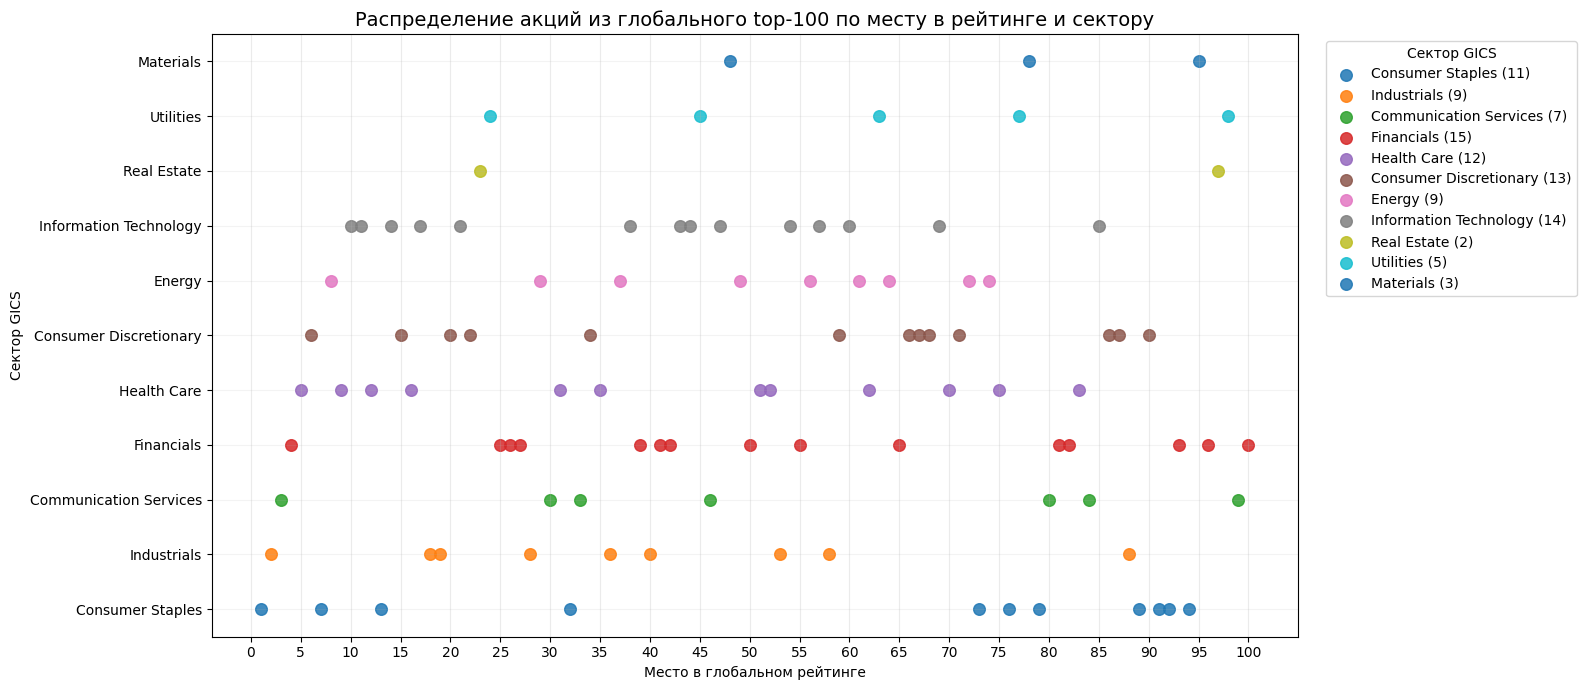

Saved:
/content/fnspid_project/sp500_current_selection/coverage_tables/plots_global_top100_ranking/global_top100_rank_by_sector_scatter.png


In [ ]:
plot_df = top100_global_df.copy()

plot_df['gics_sector'] = plot_df['gics_sector'].fillna('Unknown')
plot_df = plot_df.sort_values('global_rank').reset_index(drop=True)

sector_order = (
    plot_df
    .groupby('gics_sector')
    .agg(
        best_rank=('global_rank', 'min'),
        n_tickers=('ticker', 'nunique')
    )
    .sort_values(['best_rank', 'n_tickers'], ascending=[True, False])
    .index
    .tolist()
)

sector_to_y = {
    sector: idx
    for idx, sector in enumerate(sector_order)
}

plot_df['sector_y'] = plot_df['gics_sector'].map(sector_to_y)

fig, ax = plt.subplots(figsize=(16, 7))

for sector in sector_order:
    sector_df = plot_df.loc[plot_df['gics_sector'] == sector].copy()

    ax.scatter(
        sector_df['global_rank'],
        sector_df['sector_y'],
        s=70,
        alpha=0.85,
        label=f'{sector} ({len(sector_df)})'
    )

ax.set_title('Распределение акций из глобального top-100 по месту в рейтинге и сектору', fontsize=14)
ax.set_xlabel('Место в глобальном рейтинге')
ax.set_ylabel('Сектор GICS')

ax.set_yticks(list(sector_to_y.values()))
ax.set_yticklabels(list(sector_to_y.keys()))

ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', alpha=0.15)

ax.legend(
    title='Сектор GICS',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

rank_sector_scatter_path = plots_dir / 'global_top100_rank_by_sector_scatter.png'
plt.savefig(rank_sector_scatter_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved:')
print(rank_sector_scatter_path)

In [ ]:
period_start = pd.Timestamp('2009-01-01')
period_end = pd.Timestamp('2023-12-31')

project_dir = Path('/content/fnspid_project')
raw_dir = project_dir / 'fnspid_raw'

sp500_dir = project_dir / 'sp500_current_selection'
coverage_dir = sp500_dir / 'coverage_tables'
coverage_dir.mkdir(parents=True, exist_ok=True)

raw_news_paths = {
    'all_external': raw_dir / 'Stock_news' / 'All_external.csv',
    'nasdaq_external': raw_dir / 'Stock_news' / 'nasdaq_exteral_data.csv'
}

for name, path in raw_news_paths.items():
    print(name, path, path.exists())

all_external /content/fnspid_project/fnspid_raw/Stock_news/All_external.csv True
nasdaq_external /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv True


In [ ]:
def show_resources(note=''):
    ram = psutil.virtual_memory()
    disk = shutil.disk_usage('/content')

    print('=' * 80)
    if note:
        print(note)

    print(f'RAM total: {ram.total / 1024 ** 3:.2f} GiB')
    print(f'RAM used:  {ram.used / 1024 ** 3:.2f} GiB')
    print(f'RAM free:  {ram.available / 1024 ** 3:.2f} GiB')

    print(f'Disk total: {disk.total / 1024 ** 3:.2f} GiB')
    print(f'Disk used:  {disk.used / 1024 ** 3:.2f} GiB')
    print(f'Disk free:  {disk.free / 1024 ** 3:.2f} GiB')
    print('=' * 80)


def normalize_symbol(value):
    if pd.isna(value):
        return None

    value = str(value).strip().upper()

    if value == '':
        return None

    value = value.replace('$', '')
    value = value.replace('/', '.')
    value = value.replace('-', '.')
    value = re.sub(r'\s+', '', value)

    if value in {'NAN', 'NONE', 'NULL'}:
        return None

    return value


def pick_existing_col(columns, candidates):
    col_map = {str(col).lower(): col for col in columns}

    for candidate in candidates:
        if candidate.lower() in col_map:
            return col_map[candidate.lower()]

    return None


def parse_date_series(series):
    parsed = pd.to_datetime(series, errors='coerce', utc=True)
    parsed = parsed.dt.tz_convert(None)
    return parsed.dt.normalize()


def is_nonempty_text(series):
    text = series.astype('string').str.strip()

    return (
        text.notna()
        & text.ne('')
        & text.str.lower().ne('nan')
        & text.str.lower().ne('none')
        & text.str.lower().ne('null')
    )


show_resources('Before raw news ticker coverage pipeline')

Before raw news ticker coverage pipeline
RAM total: 12.67 GiB
RAM used:  2.33 GiB
RAM free:  9.94 GiB
Disk total: 225.83 GiB
Disk used:  53.86 GiB
Disk free:  171.96 GiB


In [ ]:
nyse = mcal.get_calendar('NYSE')

nyse_schedule = nyse.schedule(
    start_date=period_start.date(),
    end_date=period_end.date()
)

period_trading_days = (
    pd.DatetimeIndex(nyse_schedule.index)
    .tz_localize(None)
    .normalize()
    .sort_values()
)

period_trading_day_set = set(period_trading_days)
n_period_trading_days = len(period_trading_days)

print('n_period_trading_days:', n_period_trading_days)
print('first trading day:', period_trading_days.min().date())
print('last trading day:', period_trading_days.max().date())

n_period_trading_days: 3774
first trading day: 2009-01-02
last trading day: 2023-12-29


In [ ]:
raw_news_schema_rows = []

symbol_candidates = [
    'Stock_symbol',
    'stock_symbol',
    'symbol',
    'ticker',
    'Ticker',
    'Stock Symbol',
    'stock'
]

date_candidates = [
    'Date',
    'date',
    'datetime',
    'Datetime',
    'published_date',
    'Published_date',
    'published',
    'Published',
    'time',
    'Time'
]

textrank_candidates = [
    'Textrank_summary',
    'textrank_summary',
    'TextRank_summary',
    'textrank',
    'TextRank'
]

for source_name, source_path in raw_news_paths.items():
    preview_df = pd.read_csv(source_path, nrows=5, low_memory=False)

    symbol_col = pick_existing_col(preview_df.columns, symbol_candidates)
    date_col = pick_existing_col(preview_df.columns, date_candidates)
    textrank_col = pick_existing_col(preview_df.columns, textrank_candidates)

    raw_news_schema_rows.append({
        'source_name': source_name,
        'source_path': str(source_path),
        'symbol_col': symbol_col,
        'date_col': date_col,
        'textrank_col': textrank_col,
        'n_columns': len(preview_df.columns),
        'columns': list(preview_df.columns)
    })

    print('\n' + '=' * 100)
    print('source_name:', source_name)
    print('symbol_col:', symbol_col)
    print('date_col:', date_col)
    print('textrank_col:', textrank_col)
    print('columns:', list(preview_df.columns))

    display(preview_df.head())

    del preview_df
    gc.collect()

raw_news_schema_df = pd.DataFrame(raw_news_schema_rows)

display(raw_news_schema_df[['source_name', 'source_path', 'symbol_col', 'date_col', 'textrank_col', 'n_columns']])

schema_path = coverage_dir / 'raw_news_source_schema_for_textrank_coverage.csv'
raw_news_schema_df.to_csv(schema_path, index=False)

print('Saved:', schema_path)


source_name: all_external
symbol_col: Stock_symbol
date_col: Date
textrank_col: Textrank_summary
columns: ['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']


,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,2020-06-05 06:30:54 UTC,Stocks That Hit 52-Week Highs On Friday,A,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-06-03 06:45:20 UTC,Stocks That Hit 52-Week Highs On Wednesday,A,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-05-26 00:30:07 UTC,71 Biggest Movers From Friday,A,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-05-22 08:45:06 UTC,46 Stocks Moving In Friday's Mid-Day Session,A,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-05-22 07:38:59 UTC,B of A Securities Maintains Neutral on Agilent...,A,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,NaN,NaN,NaN,NaN,NaN,NaN



source_name: nasdaq_external
symbol_col: Stock_symbol
date_col: Date
textrank_col: Textrank_summary
columns: ['Unnamed: 0', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']


,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,0.0,2023-12-16 23:00:00 UTC,Interesting A Put And Call Options For August ...,A,https://www.nasdaq.com/articles/interesting-a-...,NaN,NaN,"Investors in Agilent Technologies, Inc. (Symbo...",Because the $125.00 strike represents an appro...,The current analytical data (including greeks ...,Below is a chart showing the trailing twelve m...,"At Stock Options Channel, our YieldBoost formu..."
1,1.0,2023-12-12 00:00:00 UTC,Wolfe Research Initiates Coverage of Agilent T...,A,https://www.nasdaq.com/articles/wolfe-research...,NaN,NaN,"Fintel reports that on December 13, 2023, Wolf...","Fintel reports that on December 13, 2023, Wolf...","T. Rowe Price Investment Management holds 10,1...",Agilent Technologies Declares $0.24 Dividend O...,The projected annual revenue for Agilent Techn...
2,2.0,2023-12-12 00:00:00 UTC,Agilent Technologies Reaches Analyst Target Price,A,https://www.nasdaq.com/articles/agilent-techno...,NaN,NaN,"In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...",When a stock reaches the target an analyst has...,When a stock reaches the target an analyst has...
3,3.0,2023-12-07 00:00:00 UTC,Agilent (A) Enhances BioTek Cytation C10 With ...,A,https://www.nasdaq.com/articles/agilent-a-enha...,NaN,NaN,Agilent Technologies A is enhancing its BioTek...,"Per a Grand View Research report, the global m...","Notably, Agilent enhanced the BioTek Cytation ...","Agilent Technologies, Inc. Price and Consensus...","Notably, Agilent enhanced the BioTek Cytation ..."
4,4.0,2023-12-07 00:00:00 UTC,"Pre-Market Most Active for Dec 7, 2023 : SQQQ,...",A,https://www.nasdaq.com/articles/pre-market-mos...,NaN,NaN,The NASDAQ 100 Pre-Market Indicator is up 70.2...,ProShares UltraPro Short QQQ (SQQQ) is -0.15 a...,"As reported by Zacks, the current mean recomme...","The total Pre-Market volume is currently 39,23...",The NASDAQ 100 Pre-Market Indicator is up 70.2...


,source_name,source_path,symbol_col,date_col,textrank_col,n_columns
0,all_external,/content/fnspid_project/fnspid_raw/Stock_news/...,Stock_symbol,Date,Textrank_summary,11
1,nasdaq_external,/content/fnspid_project/fnspid_raw/Stock_news/...,Stock_symbol,Date,Textrank_summary,12


Saved: /content/fnspid_project/sp500_current_selection/coverage_tables/raw_news_source_schema_for_textrank_coverage.csv


In [ ]:
def build_raw_news_daily_textrank_coverage(
    raw_news_schema_df,
    chunksize=150_000,
    max_chunks=None
):
    daily_parts = []
    source_summary_rows = []

    for schema_row in raw_news_schema_df.itertuples(index=False):
        source_name = schema_row.source_name
        source_path = Path(schema_row.source_path)
        symbol_col = schema_row.symbol_col
        date_col = schema_row.date_col
        textrank_col = schema_row.textrank_col

        print('\n' + '=' * 120)
        print('Processing source:', source_name)
        print('Path:', source_path)
        print('symbol_col:', symbol_col)
        print('date_col:', date_col)
        print('textrank_col:', textrank_col)

        if symbol_col is None or date_col is None or textrank_col is None:
            raise ValueError(
                f'Cannot process {source_name}: '
                f'symbol_col={symbol_col}, date_col={date_col}, textrank_col={textrank_col}'
            )

        usecols = list(dict.fromkeys([symbol_col, date_col, textrank_col]))

        total_rows = 0
        selected_rows = 0
        selected_trading_day_rows = 0
        source_daily_parts = []

        reader = pd.read_csv(
            source_path,
            usecols=usecols,
            chunksize=chunksize,
            low_memory=False,
            on_bad_lines='skip'
        )

        for chunk_id, chunk in enumerate(tqdm(reader, desc=f'Raw news {source_name}')):
            if max_chunks is not None and chunk_id >= max_chunks:
                break

            total_rows += len(chunk)

            chunk = chunk.rename(columns={
                symbol_col: 'ticker_raw',
                date_col: 'news_date',
                textrank_col: 'textrank_summary'
            })

            chunk['ticker'] = chunk['ticker_raw'].map(normalize_symbol)
            chunk['news_date'] = parse_date_series(chunk['news_date'])

            mask = (
                chunk['ticker'].notna()
                & chunk['news_date'].notna()
                & (chunk['news_date'] >= period_start)
                & (chunk['news_date'] <= period_end)
                & is_nonempty_text(chunk['textrank_summary'])
            )

            selected = chunk.loc[mask, ['ticker', 'news_date', 'textrank_summary']].copy()
            selected_rows += len(selected)

            selected = selected.loc[selected['news_date'].isin(period_trading_day_set)].copy()
            selected_trading_day_rows += len(selected)

            if len(selected) > 0:
                daily_part = (
                    selected
                    .groupby(['ticker', 'news_date'], as_index=False)
                    .agg(n_textrank_news=('textrank_summary', 'size'))
                )

                source_daily_parts.append(daily_part)

                del daily_part

            del chunk, selected

            if chunk_id % 25 == 0:
                gc.collect()

        if len(source_daily_parts) > 0:
            source_daily_df = (
                pd.concat(source_daily_parts, ignore_index=True)
                .groupby(['ticker', 'news_date'], as_index=False)
                .agg(n_textrank_news=('n_textrank_news', 'sum'))
            )

            source_daily_df['news_source'] = source_name
            daily_parts.append(source_daily_df)

            n_tickers = source_daily_df['ticker'].nunique()
            n_ticker_days = len(source_daily_df)

            del source_daily_df
        else:
            n_tickers = 0
            n_ticker_days = 0

        source_summary_rows.append({
            'source_name': source_name,
            'source_path': str(source_path),
            'total_rows_read': total_rows,
            'rows_with_nonempty_textrank_in_period': selected_rows,
            'rows_with_nonempty_textrank_on_trading_days': selected_trading_day_rows,
            'n_tickers_with_textrank': n_tickers,
            'n_ticker_trading_days_with_textrank': n_ticker_days
        })

        del source_daily_parts
        gc.collect()

    if len(daily_parts) > 0:
        raw_news_daily_df = (
            pd.concat(daily_parts, ignore_index=True)
            .groupby(['ticker', 'news_date'], as_index=False)
            .agg(n_textrank_news=('n_textrank_news', 'sum'))
        )
    else:
        raw_news_daily_df = pd.DataFrame(columns=[
            'ticker',
            'news_date',
            'n_textrank_news'
        ])

    source_summary_df = pd.DataFrame(source_summary_rows)

    return raw_news_daily_df, source_summary_df

In [ ]:
raw_news_daily_textrank_df, raw_news_source_summary_df = build_raw_news_daily_textrank_coverage(
    raw_news_schema_df=raw_news_schema_df,
    chunksize=150_000,
    max_chunks=None
)

print('raw_news_daily_textrank_df shape:', raw_news_daily_textrank_df.shape)
print('raw_news_source_summary_df shape:', raw_news_source_summary_df.shape)

display(raw_news_daily_textrank_df.head())
display(raw_news_source_summary_df)


Processing source: all_external
Path: /content/fnspid_project/fnspid_raw/Stock_news/All_external.csv
symbol_col: Stock_symbol
date_col: Date
textrank_col: Textrank_summary


Raw news all_external: 0it [00:00, ?it/s]


Processing source: nasdaq_external
Path: /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv
symbol_col: Stock_symbol
date_col: Date
textrank_col: Textrank_summary


Raw news nasdaq_external: 0it [00:00, ?it/s]

raw_news_daily_textrank_df shape: (1099688, 3)
raw_news_source_summary_df shape: (2, 7)


,ticker,news_date,n_textrank_news
0,A,2022-09-15,1
1,A,2022-09-16,2
2,A,2022-09-29,1
3,A,2022-10-04,1
4,A,2022-10-05,1


,source_name,source_path,total_rows_read,rows_with_nonempty_textrank_in_period,rows_with_nonempty_textrank_on_trading_days,n_tickers_with_textrank,n_ticker_trading_days_with_textrank
0,all_external,/content/fnspid_project/fnspid_raw/Stock_news/...,13057514,0,0,0,0
1,nasdaq_external,/content/fnspid_project/fnspid_raw/Stock_news/...,15549299,2491651,2319302,4670,1099688


In [ ]:
raw_news_ticker_coverage_df = (
    raw_news_daily_textrank_df
    .groupby('ticker', as_index=False)
    .agg(
        textrank_news_trading_days_2009_2023=('news_date', 'nunique'),
        textrank_news_min_date_2009_2023=('news_date', 'min'),
        textrank_news_max_date_2009_2023=('news_date', 'max'),
        n_total_textrank_news_2009_2023=('n_textrank_news', 'sum')
    )
)

raw_news_ticker_coverage_df['textrank_news_trading_day_share_2009_2023'] = (
    raw_news_ticker_coverage_df['textrank_news_trading_days_2009_2023']
    / n_period_trading_days
)

raw_news_ticker_coverage_df['n_period_trading_days_2009_2023'] = n_period_trading_days

raw_news_ticker_coverage_df['n_total_textrank_news_2009_2023'] = (
    raw_news_ticker_coverage_df['n_total_textrank_news_2009_2023']
    .astype(int)
)

raw_news_ticker_coverage_df = raw_news_ticker_coverage_df[[
    'ticker',
    'textrank_news_trading_day_share_2009_2023',
    'textrank_news_trading_days_2009_2023',
    'n_period_trading_days_2009_2023',
    'textrank_news_min_date_2009_2023',
    'textrank_news_max_date_2009_2023',
    'n_total_textrank_news_2009_2023'
]].copy()

raw_news_ticker_coverage_df = raw_news_ticker_coverage_df.sort_values(
    by=[
        'textrank_news_trading_day_share_2009_2023',
        'textrank_news_min_date_2009_2023'
    ],
    ascending=[
        False,
        True
    ],
    na_position='last'
).reset_index(drop=True)

raw_news_ticker_coverage_df['raw_news_rank'] = np.arange(1, len(raw_news_ticker_coverage_df) + 1)

raw_news_ticker_coverage_df = raw_news_ticker_coverage_df[[
    'raw_news_rank',
    'ticker',
    'textrank_news_trading_day_share_2009_2023',
    'textrank_news_trading_days_2009_2023',
    'n_period_trading_days_2009_2023',
    'textrank_news_min_date_2009_2023',
    'textrank_news_max_date_2009_2023',
    'n_total_textrank_news_2009_2023'
]].copy()

print('raw_news_ticker_coverage_df shape:', raw_news_ticker_coverage_df.shape)
display(raw_news_ticker_coverage_df.head(100))

raw_news_ticker_coverage_df shape: (4670, 8)


,raw_news_rank,ticker,textrank_news_trading_day_share_2009_2023,textrank_news_trading_days_2009_2023,n_period_trading_days_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,n_total_textrank_news_2009_2023
0,1,USO,0.698993,2638,3774,2009-07-13,2023-12-15,5176
1,2,KO,0.672761,2539,3774,2009-10-14,2023-12-15,6937
2,3,GE,0.672496,2538,3774,2012-04-20,2023-12-15,8130
3,4,CMCSA,0.665607,2512,3774,2009-11-17,2023-12-15,6316
4,5,GLD,0.665077,2510,3774,2009-04-14,2023-12-15,5723
...,...,...,...,...,...,...,...,...
95,96,TRV,0.368309,1390,3774,2009-10-14,2023-12-13,2483
96,97,TEVA,0.367780,1388,3774,2010-02-12,2023-12-15,2395
97,98,DHI,0.365395,1379,3774,2010-02-03,2023-12-15,2354
98,99,TJX,0.365395,1379,3774,2010-04-09,2023-12-15,2447


In [ ]:
raw_news_daily_path = coverage_dir / 'raw_news_daily_textrank_coverage_2009_2023_by_ticker_date.parquet'
raw_news_ticker_csv_path = coverage_dir / 'raw_news_textrank_coverage_2009_2023_by_ticker.csv'
raw_news_ticker_parquet_path = coverage_dir / 'raw_news_textrank_coverage_2009_2023_by_ticker.parquet'
raw_news_source_summary_path = coverage_dir / 'raw_news_textrank_coverage_2009_2023_source_summary.csv'

raw_news_daily_textrank_df.to_parquet(raw_news_daily_path, index=False)
raw_news_ticker_coverage_df.to_csv(raw_news_ticker_csv_path, index=False)
raw_news_ticker_coverage_df.to_parquet(raw_news_ticker_parquet_path, index=False)
raw_news_source_summary_df.to_csv(raw_news_source_summary_path, index=False)

print('Saved:')
print(raw_news_daily_path)
print(raw_news_ticker_csv_path)
print(raw_news_ticker_parquet_path)
print(raw_news_source_summary_path)

Saved:
/content/fnspid_project/sp500_current_selection/coverage_tables/raw_news_daily_textrank_coverage_2009_2023_by_ticker_date.parquet
/content/fnspid_project/sp500_current_selection/coverage_tables/raw_news_textrank_coverage_2009_2023_by_ticker.csv
/content/fnspid_project/sp500_current_selection/coverage_tables/raw_news_textrank_coverage_2009_2023_by_ticker.parquet
/content/fnspid_project/sp500_current_selection/coverage_tables/raw_news_textrank_coverage_2009_2023_source_summary.csv


In [ ]:
raw_news_top100_df = raw_news_ticker_coverage_df.head(100).copy()

print('raw_news_top100_df shape:', raw_news_top100_df.shape)
display(raw_news_top100_df)

raw_news_top100_df shape: (100, 8)


,raw_news_rank,ticker,textrank_news_trading_day_share_2009_2023,textrank_news_trading_days_2009_2023,n_period_trading_days_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,n_total_textrank_news_2009_2023
0,1,USO,0.698993,2638,3774,2009-07-13,2023-12-15,5176
1,2,KO,0.672761,2539,3774,2009-10-14,2023-12-15,6937
2,3,GE,0.672496,2538,3774,2012-04-20,2023-12-15,8130
3,4,CMCSA,0.665607,2512,3774,2009-11-17,2023-12-15,6316
4,5,GLD,0.665077,2510,3774,2009-04-14,2023-12-15,5723
...,...,...,...,...,...,...,...,...
95,96,TRV,0.368309,1390,3774,2009-10-14,2023-12-13,2483
96,97,TEVA,0.367780,1388,3774,2010-02-12,2023-12-15,2395
97,98,DHI,0.365395,1379,3774,2010-02-03,2023-12-15,2354
98,99,TJX,0.365395,1379,3774,2010-04-09,2023-12-15,2447


In [ ]:
if 'top100_global_df' not in globals():
    top100_global_path = coverage_dir / 'sp500_current_coverage_2009_2023_global_top100.csv'

    if not top100_global_path.exists():
        raise FileNotFoundError(
            f'top100_global_df is not in memory and file not found: {top100_global_path}'
        )

    top100_global_df = pd.read_csv(top100_global_path)

top100_global_df['ticker'] = top100_global_df['ticker'].map(normalize_symbol)
raw_news_top100_df['ticker'] = raw_news_top100_df['ticker'].map(normalize_symbol)

print('top100_global_df shape:', top100_global_df.shape)
display(top100_global_df.head())

top100_global_df shape: (100, 20)


,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,n_total_textrank_news_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,n_trading_days_in_period_2009_2023,security,gics_sub_industry,ticker_yahoo,symbol_key,sp500_date_added,cik,global_rank,rank_group
0,KO,Consumer Staples,0.672761,0.999735,6937,2009-10-14,2023-12-15,2009-01-02,2023-12-28,2539,3773,3774,Coca-Cola Company (The),Soft Drinks & Non-alcoholic Beverages,KO,KO,1957-03-04,21344,1,1-10
1,GE,Industrials,0.672496,0.999735,8130,2012-04-20,2023-12-15,2009-01-02,2023-12-28,2538,3773,3774,GE Aerospace,Aerospace & Defense,GE,GE,1957-03-04,40545,2,1-10
2,CMCSA,Communication Services,0.665607,0.999735,6316,2009-11-17,2023-12-15,2009-01-02,2023-12-28,2512,3773,3774,Comcast,Cable & Satellite,CMCSA,CMCSA,2002-11-19,1166691,3,1-10
3,V,Financials,0.649179,0.999735,6446,2010-04-15,2023-12-15,2009-01-02,2023-12-28,2450,3773,3774,Visa Inc.,Transaction & Payment Processing Services,V,V,2009-12-21,1403161,4,1-10
4,MRK,Health Care,0.639375,0.999735,6986,2009-11-04,2023-12-14,2009-01-02,2023-12-28,2413,3773,3774,Merck & Co.,Pharmaceuticals,MRK,MRK,1957-03-04,310158,5,1-10


In [ ]:
raw_news_top100_tickers = set(raw_news_top100_df['ticker'].dropna())
global_top100_tickers = set(top100_global_df['ticker'].dropna())

overlap_tickers = sorted(raw_news_top100_tickers & global_top100_tickers)

n_overlap = len(overlap_tickers)
raw_only_tickers = sorted(raw_news_top100_tickers - global_top100_tickers)
global_only_tickers = sorted(global_top100_tickers - raw_news_top100_tickers)

print('Top-100 raw news tickers:', len(raw_news_top100_tickers))
print('Top-100 global tickers:', len(global_top100_tickers))
print('Overlap:', n_overlap)
print('Overlap share relative to raw news top-100:', n_overlap / len(raw_news_top100_tickers))
print('Overlap share relative to global top-100:', n_overlap / len(global_top100_tickers))

print('\nOverlap tickers:')
print(overlap_tickers)

Top-100 raw news tickers: 100
Top-100 global tickers: 100
Overlap: 67
Overlap share relative to raw news top-100: 0.67
Overlap share relative to global top-100: 0.67

Overlap tickers:
['ABBV', 'ABT', 'ACN', 'ADBE', 'AIG', 'AMAT', 'AMD', 'AMGN', 'AMT', 'BBY', 'BIIB', 'BX', 'C', 'CAT', 'CMCSA', 'CMG', 'COP', 'COST', 'CRM', 'CVX', 'D', 'DE', 'DHI', 'DHR', 'DUK', 'DVN', 'EA', 'EBAY', 'EOG', 'FDX', 'FSLR', 'GE', 'GILD', 'GS', 'HAL', 'HPQ', 'INTC', 'KO', 'MGM', 'MMM', 'MRK', 'MS', 'MU', 'NEE', 'NEM', 'NKE', 'NOC', 'ORCL', 'OXY', 'PEP', 'PM', 'PYPL', 'QCOM', 'SBUX', 'SLB', 'T', 'TJX', 'TMO', 'TMUS', 'TRV', 'TXN', 'UNP', 'UPS', 'USB', 'V', 'VRTX', 'WFC']


In [ ]:
raw_news_top100_for_merge_df = raw_news_top100_df.rename(columns={
    'raw_news_rank': 'raw_news_rank_in_all_original_news',
    'textrank_news_trading_day_share_2009_2023': 'raw_news_textrank_share_2009_2023',
    'textrank_news_trading_days_2009_2023': 'raw_news_textrank_trading_days_2009_2023',
    'textrank_news_min_date_2009_2023': 'raw_news_textrank_min_date_2009_2023',
    'textrank_news_max_date_2009_2023': 'raw_news_textrank_max_date_2009_2023',
    'n_total_textrank_news_2009_2023': 'raw_news_total_textrank_news_2009_2023'
})

global_top100_for_merge_cols = [
    'global_rank',
    'ticker',
    'gics_sector',
    'textrank_news_trading_day_share_2009_2023',
    'price_trading_day_share_2009_2023',
    'textrank_news_min_date_2009_2023',
    'textrank_news_max_date_2009_2023',
    'price_min_date_2009_2023',
    'price_max_date_2009_2023',
    'n_total_textrank_news_2009_2023',
    'security'
]

global_top100_for_merge_cols = [
    col for col in global_top100_for_merge_cols
    if col in top100_global_df.columns
]

top100_overlap_detail_df = raw_news_top100_for_merge_df.merge(
    top100_global_df[global_top100_for_merge_cols],
    on='ticker',
    how='inner'
)

top100_overlap_detail_df = top100_overlap_detail_df.sort_values(
    ['raw_news_rank_in_all_original_news', 'global_rank']
).reset_index(drop=True)

print('top100_overlap_detail_df shape:', top100_overlap_detail_df.shape)
display(top100_overlap_detail_df)

top100_overlap_detail_df shape: (67, 18)


,raw_news_rank_in_all_original_news,ticker,raw_news_textrank_share_2009_2023,raw_news_textrank_trading_days_2009_2023,n_period_trading_days_2009_2023,raw_news_textrank_min_date_2009_2023,raw_news_textrank_max_date_2009_2023,raw_news_total_textrank_news_2009_2023,global_rank,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_total_textrank_news_2009_2023,security
0,2,KO,0.672761,2539,3774,2009-10-14,2023-12-15,6937,1,Consumer Staples,0.672761,0.999735,2009-10-14,2023-12-15,2009-01-02,2023-12-28,6937,Coca-Cola Company (The)
1,3,GE,0.672496,2538,3774,2012-04-20,2023-12-15,8130,2,Industrials,0.672496,0.999735,2012-04-20,2023-12-15,2009-01-02,2023-12-28,8130,GE Aerospace
2,4,CMCSA,0.665607,2512,3774,2009-11-17,2023-12-15,6316,3,Communication Services,0.665607,0.999735,2009-11-17,2023-12-15,2009-01-02,2023-12-28,6316,Comcast
3,7,V,0.649179,2450,3774,2010-04-15,2023-12-15,6446,4,Financials,0.649179,0.999735,2010-04-15,2023-12-15,2009-01-02,2023-12-28,6446,Visa Inc.
4,8,MRK,0.639375,2413,3774,2009-11-04,2023-12-14,6986,5,Health Care,0.639375,0.999735,2009-11-04,2023-12-14,2009-01-02,2023-12-28,6986,Merck & Co.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,93,D,0.372549,1406,3774,2010-04-20,2023-12-15,2476,63,Utilities,0.372549,0.999735,2010-04-20,2023-12-15,2009-01-02,2023-12-28,2476,Dominion Energy
63,94,DVN,0.369104,1393,3774,2009-10-23,2023-12-14,2573,64,Energy,0.369104,0.999735,2009-10-23,2023-12-14,2009-01-02,2023-12-28,2573,Devon Energy
64,96,TRV,0.368309,1390,3774,2009-10-14,2023-12-13,2483,65,Financials,0.368309,0.999735,2009-10-14,2023-12-13,2009-01-02,2023-12-28,2483,Travelers Companies (The)
65,98,DHI,0.365395,1379,3774,2010-02-03,2023-12-15,2354,66,Consumer Discretionary,0.365395,0.999735,2010-02-03,2023-12-15,2009-01-02,2023-12-28,2354,D. R. Horton


## Составление эмбеддингов

In [ ]:
top100_global_df.head()

,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,n_total_textrank_news_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,n_trading_days_in_period_2009_2023,security,gics_sub_industry,ticker_yahoo,symbol_key,sp500_date_added,cik,global_rank,rank_group
0,KO,Consumer Staples,0.672761,0.999735,6937,2009-10-14,2023-12-15,2009-01-02,2023-12-28,2539,3773,3774,Coca-Cola Company (The),Soft Drinks & Non-alcoholic Beverages,KO,KO,1957-03-04,21344,1,1-10
1,GE,Industrials,0.672496,0.999735,8130,2012-04-20,2023-12-15,2009-01-02,2023-12-28,2538,3773,3774,GE Aerospace,Aerospace & Defense,GE,GE,1957-03-04,40545,2,1-10
2,CMCSA,Communication Services,0.665607,0.999735,6316,2009-11-17,2023-12-15,2009-01-02,2023-12-28,2512,3773,3774,Comcast,Cable & Satellite,CMCSA,CMCSA,2002-11-19,1166691,3,1-10
3,V,Financials,0.649179,0.999735,6446,2010-04-15,2023-12-15,2009-01-02,2023-12-28,2450,3773,3774,Visa Inc.,Transaction & Payment Processing Services,V,V,2009-12-21,1403161,4,1-10
4,MRK,Health Care,0.639375,0.999735,6986,2009-11-04,2023-12-14,2009-01-02,2023-12-28,2413,3773,3774,Merck & Co.,Pharmaceuticals,MRK,MRK,1957-03-04,310158,5,1-10


In [ ]:
top100_global_df['price_trading_day_share_2009_2023'].unique()

array([0.99973503, 0.36698463, 0.73317435, 0.76709062, 0.56624271,
       0.76285109, 0.89772125])

In [ ]:
top100_global_df[(top100_global_df['price_trading_day_share_2009_2023'] > 0.3669) & (top100_global_df['price_trading_day_share_2009_2023'] < 0.367)]

,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,n_total_textrank_news_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,n_trading_days_in_period_2009_2023,security,gics_sub_industry,ticker_yahoo,symbol_key,sp500_date_added,cik,global_rank,rank_group
14,SBUX,Consumer Discretionary,0.537891,0.366985,5966,2014-08-22,2023-12-15,2015-01-02,2020-07-02,2030,1385,3774,Starbucks,Restaurants,SBUX,SBUX,2000-06-07,829224,15,11-20
28,SLB,Energy,0.488341,0.366985,3732,2009-10-20,2023-12-15,2015-01-02,2020-07-02,1843,1385,3774,Schlumberger,Oil & Gas Equipment & Services,SLB,SLB,1957-03-04,87347,29,21-30
76,SO,Utilities,0.343137,0.366985,2070,2010-06-22,2023-12-14,2015-01-02,2020-07-02,1295,1385,3774,Southern Company,Electric Utilities,SO,SO,1957-03-04,92122,77,71-80


In [ ]:
df_sbux = pd.read_csv('/content/fnspid_project/fnspid_raw/Stock_price/full_history/full_history/SBUX.csv')

df_sbux.tail()

,date,volume,open,high,low,close,adj close
1380,2015-01-08,13170600,41.165001,41.650002,41.009998,41.244999,37.399979
1381,2015-01-07,9732600,39.875000,40.615002,39.700001,40.590000,36.806049
1382,2015-01-06,7664400,40.169998,40.195000,39.279999,39.615002,35.921936
1383,2015-01-05,11623800,40.070000,40.334999,39.744999,39.939999,36.216637
1384,2015-01-02,6886000,41.064999,41.490002,40.445000,40.720001,36.923927


In [ ]:
coverage_dir = Path('/content/fnspid_project/sp500_current_selection/coverage_tables')

required_cols = [
    'price_trading_day_share_2009_2023',
    'textrank_news_trading_day_share_2009_2023',
    'textrank_news_min_date_2009_2023',
    'price_min_date_2009_2023'
]

for col in required_cols:
    if col not in period_coverage_df.columns:
        raise ValueError(f'Column not found: {col}')

price_first_ranked_df = period_coverage_df.copy()

date_cols = [
    'textrank_news_min_date_2009_2023',
    'textrank_news_max_date_2009_2023',
    'price_min_date_2009_2023',
    'price_max_date_2009_2023'
]

for col in date_cols:
    if col in price_first_ranked_df.columns:
        price_first_ranked_df[col] = pd.to_datetime(
            price_first_ranked_df[col],
            errors='coerce'
        )

price_first_ranked_df = (
    price_first_ranked_df
    .sort_values(
        by=[
            'price_trading_day_share_2009_2023',
            'textrank_news_trading_day_share_2009_2023',
            'textrank_news_min_date_2009_2023',
            'price_min_date_2009_2023'
        ],
        ascending=[
            False,
            False,
            True,
            True
        ],
        na_position='last'
    )
    .reset_index(drop=True)
)

price_first_ranked_df['price_first_global_rank'] = np.arange(
    1,
    len(price_first_ranked_df) + 1
)

price_first_top100_df = price_first_ranked_df.head(100).copy()

print('price_first_ranked_df shape:', price_first_ranked_df.shape)
print('price_first_top100_df shape:', price_first_top100_df.shape)

display(price_first_top100_df.head(100))

price_first_ranked_df shape: (453, 19)
price_first_top100_df shape: (100, 19)


,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,n_total_textrank_news_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,n_trading_days_in_period_2009_2023,security,gics_sub_industry,ticker_yahoo,symbol_key,sp500_date_added,cik,price_first_global_rank
0,KO,Consumer Staples,0.672761,0.999735,6937,2009-10-14,2023-12-15,2009-01-02,2023-12-28,2539,3773,3774,Coca-Cola Company (The),Soft Drinks & Non-alcoholic Beverages,KO,KO,1957-03-04,21344,1
1,GE,Industrials,0.672496,0.999735,8130,2012-04-20,2023-12-15,2009-01-02,2023-12-28,2538,3773,3774,GE Aerospace,Aerospace & Defense,GE,GE,1957-03-04,40545,2
2,CMCSA,Communication Services,0.665607,0.999735,6316,2009-11-17,2023-12-15,2009-01-02,2023-12-28,2512,3773,3774,Comcast,Cable & Satellite,CMCSA,CMCSA,2002-11-19,1166691,3
3,V,Financials,0.649179,0.999735,6446,2010-04-15,2023-12-15,2009-01-02,2023-12-28,2450,3773,3774,Visa Inc.,Transaction & Payment Processing Services,V,V,2009-12-21,1403161,4
4,MRK,Health Care,0.639375,0.999735,6986,2009-11-04,2023-12-14,2009-01-02,2023-12-28,2413,3773,3774,Merck & Co.,Pharmaceuticals,MRK,MRK,1957-03-04,310158,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ROST,Consumer Discretionary,0.292263,0.999735,1940,2010-03-22,2023-12-13,2009-01-02,2023-12-28,1103,3773,3774,Ross Stores,Apparel Retail,ROST,ROST,2009-12-21,745732,96
96,CLX,Consumer Staples,0.290408,0.999735,1729,2009-10-14,2023-12-15,2009-01-02,2023-12-28,1096,3773,3774,Clorox,Household Products,CLX,CLX,1969-03-31,21076,97
97,BEN,Financials,0.290408,0.999735,1684,2010-02-25,2023-12-12,2009-01-02,2023-12-28,1096,3773,3774,Franklin Resources,Asset Management & Custody Banks,BEN,BEN,1998-04-30,38777,98
98,PAYX,Industrials,0.289878,0.999735,1702,2009-11-20,2023-12-14,2009-01-02,2023-12-28,1094,3773,3774,Paychex,Human Resource & Employment Services,PAYX,PAYX,1998-10-01,723531,99


In [ ]:
price_first_top100_df['price_trading_day_share_2009_2023'].unique()

array([0.99973503])

In [ ]:
price_first_ranked_path = (
    coverage_dir
    / 'sp500_current_coverage_2009_2023_price_first_global_ranked.csv'
)

price_first_top100_path = (
    coverage_dir
    / 'sp500_current_coverage_2009_2023_price_first_global_top100.csv'
)

price_first_ranked_df.to_csv(price_first_ranked_path, index=False)
price_first_top100_df.to_csv(price_first_top100_path, index=False)

print('Saved price-first ranked dataframe:')
print(price_first_ranked_path)

print('Saved price-first top-100 dataframe:')
print(price_first_top100_path)

Saved price-first ranked dataframe:
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_coverage_2009_2023_price_first_global_ranked.csv
Saved price-first top-100 dataframe:
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_coverage_2009_2023_price_first_global_top100.csv


In [ ]:
price_first_top100_sector_summary_df = (
    price_first_top100_df
    .groupby('gics_sector', as_index=False)
    .agg(
        n_tickers=('ticker', 'nunique'),
        best_rank=('price_first_global_rank', 'min'),
        worst_rank=('price_first_global_rank', 'max'),
        mean_rank=('price_first_global_rank', 'mean'),
        mean_price_share=('price_trading_day_share_2009_2023', 'mean'),
        mean_textrank_share=('textrank_news_trading_day_share_2009_2023', 'mean'),
        total_textrank_news=('n_total_textrank_news_2009_2023', 'sum')
    )
    .sort_values(['n_tickers', 'best_rank'], ascending=[False, True])
    .reset_index(drop=True)
)

display(price_first_top100_sector_summary_df)

price_first_top100_sector_summary_path = (
    coverage_dir
    / 'sp500_current_coverage_2009_2023_price_first_global_top100_sector_summary.csv'
)

price_first_top100_sector_summary_df.to_csv(
    price_first_top100_sector_summary_path,
    index=False
)

print('Saved sector summary:')
print(price_first_top100_sector_summary_path)

,gics_sector,n_tickers,best_rank,worst_rank,mean_rank,mean_price_share,mean_textrank_share,total_textrank_news
0,Financials,16,4,98,55.875000,0.999735,0.397208,59688
1,Consumer Discretionary,14,6,100,59.928571,0.999735,0.384094,40477
2,Information Technology,13,10,62,33.153846,0.999735,0.462211,61078
3,Consumer Staples,12,1,97,62.750000,0.999735,0.388668,42273
4,Health Care,11,5,75,39.545455,0.999735,0.450836,41063
5,Industrials,9,2,99,42.888889,0.999735,0.445887,32981
6,Energy,8,8,67,47.000000,0.999735,0.415209,29328
7,Communication Services,7,3,89,47.714286,0.999735,0.428836,38973
8,Utilities,4,21,88,51.000000,0.999735,0.399444,10930
9,Materials,4,42,94,72.750000,0.999735,0.339560,8113


Saved sector summary:
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_coverage_2009_2023_price_first_global_top100_sector_summary.csv


In [ ]:
coverage_dir = Path('/content/fnspid_project/sp500_current_selection/coverage_tables')
plots_dir = coverage_dir / 'plots_price_first_top100'
plots_dir.mkdir(parents=True, exist_ok=True)

print('coverage_dir:', coverage_dir)
print('plots_dir:', plots_dir)

coverage_dir: /content/fnspid_project/sp500_current_selection/coverage_tables
plots_dir: /content/fnspid_project/sp500_current_selection/coverage_tables/plots_price_first_top100


In [ ]:
if 'price_first_top100_df' not in globals():
    price_first_top100_path = (
        coverage_dir
        / 'sp500_current_coverage_2009_2023_price_first_global_top100.csv'
    )

    if not price_first_top100_path.exists():
        raise FileNotFoundError(
            f'price_first_top100_df is not in memory and file not found: {price_first_top100_path}'
        )

    price_first_top100_df = pd.read_csv(price_first_top100_path)

price_first_top100_df['gics_sector'] = (
    price_first_top100_df['gics_sector']
    .fillna('Unknown')
)

print('price_first_top100_df shape:', price_first_top100_df.shape)
display(price_first_top100_df.head())

price_first_top100_df shape: (100, 19)


,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,n_total_textrank_news_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,n_trading_days_in_period_2009_2023,security,gics_sub_industry,ticker_yahoo,symbol_key,sp500_date_added,cik,price_first_global_rank
0,KO,Consumer Staples,0.672761,0.999735,6937,2009-10-14,2023-12-15,2009-01-02,2023-12-28,2539,3773,3774,Coca-Cola Company (The),Soft Drinks & Non-alcoholic Beverages,KO,KO,1957-03-04,21344,1
1,GE,Industrials,0.672496,0.999735,8130,2012-04-20,2023-12-15,2009-01-02,2023-12-28,2538,3773,3774,GE Aerospace,Aerospace & Defense,GE,GE,1957-03-04,40545,2
2,CMCSA,Communication Services,0.665607,0.999735,6316,2009-11-17,2023-12-15,2009-01-02,2023-12-28,2512,3773,3774,Comcast,Cable & Satellite,CMCSA,CMCSA,2002-11-19,1166691,3
3,V,Financials,0.649179,0.999735,6446,2010-04-15,2023-12-15,2009-01-02,2023-12-28,2450,3773,3774,Visa Inc.,Transaction & Payment Processing Services,V,V,2009-12-21,1403161,4
4,MRK,Health Care,0.639375,0.999735,6986,2009-11-04,2023-12-14,2009-01-02,2023-12-28,2413,3773,3774,Merck & Co.,Pharmaceuticals,MRK,MRK,1957-03-04,310158,5


In [ ]:
price_first_top100_sector_distribution_df = (
    price_first_top100_df
    .groupby('gics_sector', as_index=False)
    .agg(
        n_tickers=('ticker', 'nunique'),
        best_rank=('price_first_global_rank', 'min'),
        worst_rank=('price_first_global_rank', 'max'),
        mean_rank=('price_first_global_rank', 'mean'),
        median_rank=('price_first_global_rank', 'median'),
        mean_price_share=('price_trading_day_share_2009_2023', 'mean'),
        mean_textrank_share=('textrank_news_trading_day_share_2009_2023', 'mean'),
        total_textrank_news=('n_total_textrank_news_2009_2023', 'sum')
    )
    .sort_values(['n_tickers', 'best_rank'], ascending=[False, True])
    .reset_index(drop=True)
)

price_first_top100_sector_distribution_df['share_of_top100'] = (
    price_first_top100_sector_distribution_df['n_tickers']
    / price_first_top100_sector_distribution_df['n_tickers'].sum()
)

display(price_first_top100_sector_distribution_df)

sector_distribution_path = (
    coverage_dir
    / 'sp500_current_coverage_2009_2023_price_first_top100_sector_distribution.csv'
)

price_first_top100_sector_distribution_df.to_csv(
    sector_distribution_path,
    index=False
)

print('Saved:')
print(sector_distribution_path)

,gics_sector,n_tickers,best_rank,worst_rank,mean_rank,median_rank,mean_price_share,mean_textrank_share,total_textrank_news,share_of_top100
0,Financials,16,4,98,55.875000,53.5,0.999735,0.397208,59688,0.16
1,Consumer Discretionary,14,6,100,59.928571,62.5,0.999735,0.384094,40477,0.14
2,Information Technology,13,10,62,33.153846,37.0,0.999735,0.462211,61078,0.13
3,Consumer Staples,12,1,97,62.750000,75.5,0.999735,0.388668,42273,0.12
4,Health Care,11,5,75,39.545455,45.0,0.999735,0.450836,41063,0.11
5,Industrials,9,2,99,42.888889,35.0,0.999735,0.445887,32981,0.09
6,Energy,8,8,67,47.000000,52.0,0.999735,0.415209,29328,0.08
7,Communication Services,7,3,89,47.714286,40.0,0.999735,0.428836,38973,0.07
8,Utilities,4,21,88,51.000000,47.5,0.999735,0.399444,10930,0.04
9,Materials,4,42,94,72.750000,77.5,0.999735,0.339560,8113,0.04


Saved:
/content/fnspid_project/sp500_current_selection/coverage_tables/sp500_current_coverage_2009_2023_price_first_top100_sector_distribution.csv


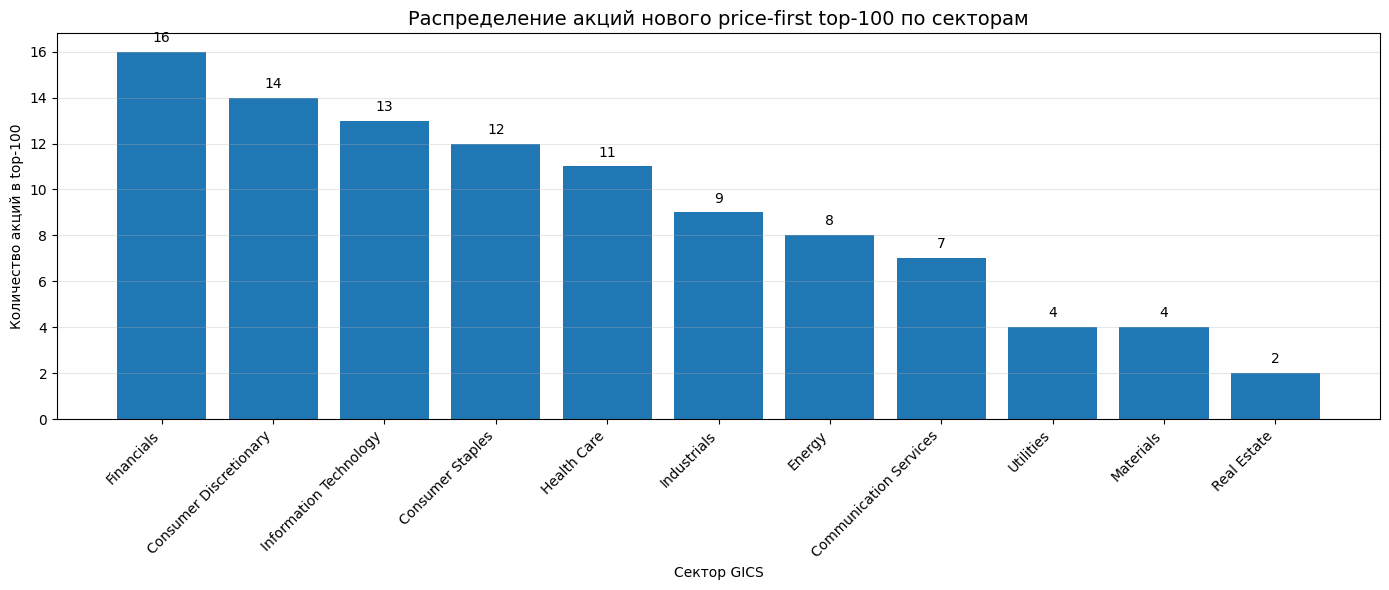

Saved:
/content/fnspid_project/sp500_current_selection/coverage_tables/plots_price_first_top100/price_first_top100_sector_distribution_bar.png


In [ ]:
plot_df = price_first_top100_sector_distribution_df.sort_values(
    'n_tickers',
    ascending=False
).copy()

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    plot_df['gics_sector'],
    plot_df['n_tickers']
)

ax.set_title('Распределение акций нового price-first top-100 по секторам', fontsize=14)
ax.set_xlabel('Сектор GICS')
ax.set_ylabel('Количество акций в top-100')
ax.grid(axis='y', alpha=0.3)

for idx, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(
        idx,
        row['n_tickers'] + 0.3,
        str(int(row['n_tickers'])),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

bar_plot_path = plots_dir / 'price_first_top100_sector_distribution_bar.png'
plt.savefig(bar_plot_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved:')
print(bar_plot_path)

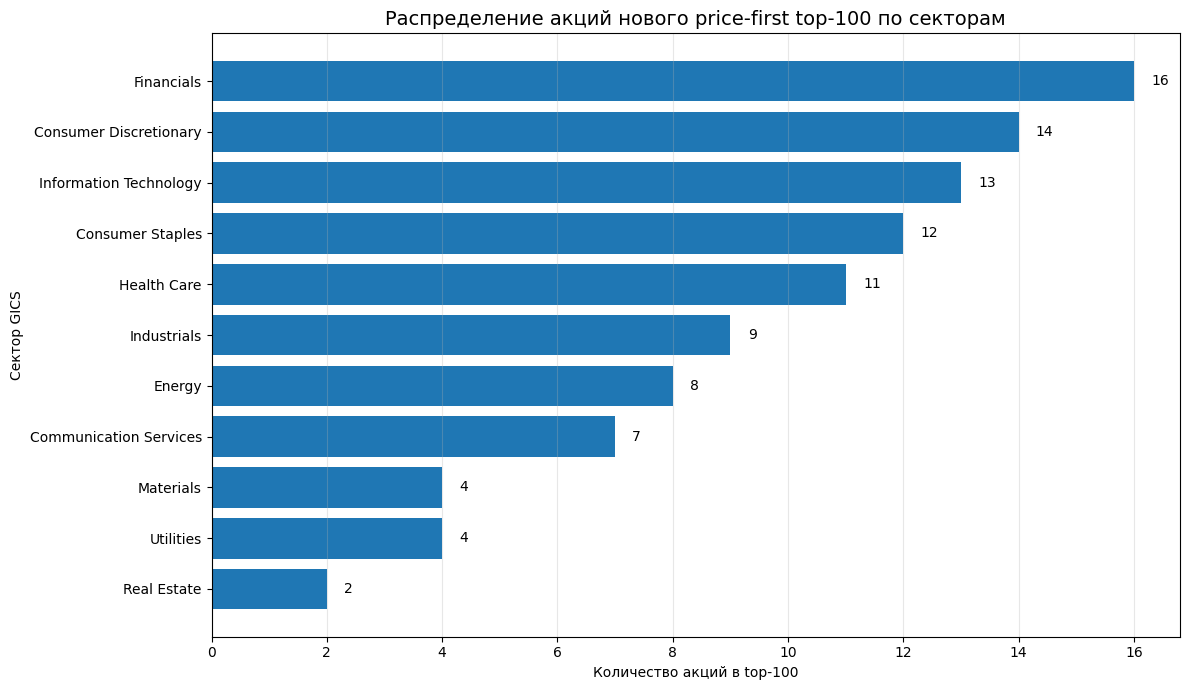

Saved:
/content/fnspid_project/sp500_current_selection/coverage_tables/plots_price_first_top100/price_first_top100_sector_distribution_barh.png


In [ ]:
plot_df = price_first_top100_sector_distribution_df.sort_values(
    'n_tickers',
    ascending=True
).copy()

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    plot_df['gics_sector'],
    plot_df['n_tickers']
)

ax.set_title('Распределение акций нового price-first top-100 по секторам', fontsize=14)
ax.set_xlabel('Количество акций в top-100')
ax.set_ylabel('Сектор GICS')
ax.grid(axis='x', alpha=0.3)

for idx, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(
        row['n_tickers'] + 0.3,
        idx,
        str(int(row['n_tickers'])),
        va='center',
        ha='left',
        fontsize=10
    )

plt.tight_layout()

barh_plot_path = plots_dir / 'price_first_top100_sector_distribution_barh.png'
plt.savefig(barh_plot_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved:')
print(barh_plot_path)

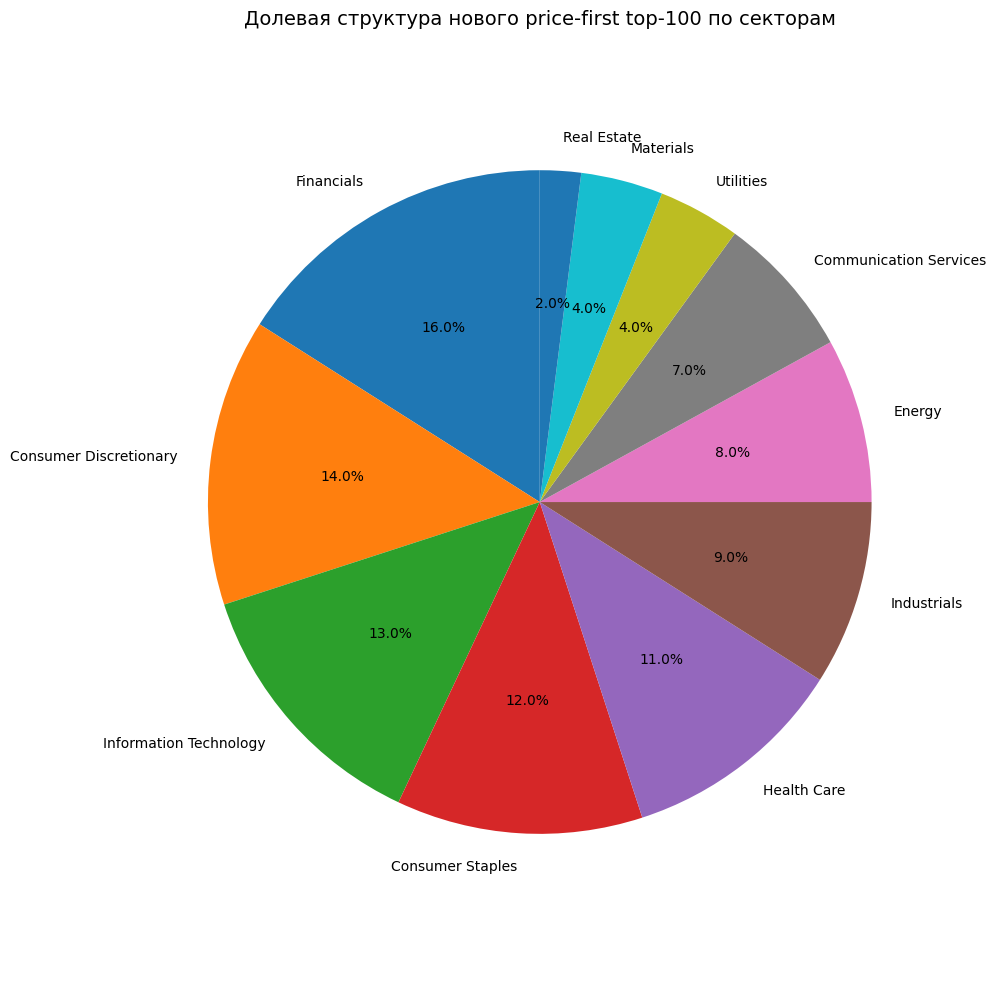

Saved:
/content/fnspid_project/sp500_current_selection/coverage_tables/plots_price_first_top100/price_first_top100_sector_distribution_pie.png


In [ ]:
plot_df = price_first_top100_sector_distribution_df.sort_values(
    'n_tickers',
    ascending=False
).copy()

fig, ax = plt.subplots(figsize=(10, 10))

ax.pie(
    plot_df['n_tickers'],
    labels=plot_df['gics_sector'],
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title('Долевая структура нового price-first top-100 по секторам', fontsize=14)
ax.axis('equal')

plt.tight_layout()

pie_plot_path = plots_dir / 'price_first_top100_sector_distribution_pie.png'
plt.savefig(pie_plot_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved:')
print(pie_plot_path)

## Создание отдельной папки для выбранных акций

In [ ]:
import gc
import json
import re
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
from tqdm.auto import tqdm

In [ ]:
project_dir = Path('/content/fnspid_project')
raw_dir = project_dir / 'fnspid_raw'

sp500_dir = project_dir / 'sp500_current_selection'
metadata_dir = sp500_dir / 'metadata'
coverage_dir = sp500_dir / 'coverage_tables'
prices_dir = sp500_dir / 'prices'
news_dir = sp500_dir / 'news'

price_parquet_dir = prices_dir / 'parquet_by_symbol'

model_data_dir = project_dir / 'price_first_top100_model_data'

model_metadata_dir = model_data_dir / 'metadata'
model_raw_prices_dir = model_data_dir / 'raw_prices_csv_by_symbol'
model_price_parquet_dir = model_data_dir / 'prices_parquet_by_symbol'
model_raw_news_dir = model_data_dir / 'raw_news_filtered_by_ticker'
model_logs_dir = model_data_dir / 'logs'

for path in [
    model_data_dir,
    model_metadata_dir,
    model_raw_prices_dir,
    model_price_parquet_dir,
    model_raw_news_dir,
    model_logs_dir
]:
    path.mkdir(parents=True, exist_ok=True)

print('model_data_dir:', model_data_dir)
print('model_metadata_dir:', model_metadata_dir)
print('model_raw_prices_dir:', model_raw_prices_dir)
print('model_price_parquet_dir:', model_price_parquet_dir)
print('model_raw_news_dir:', model_raw_news_dir)
print('model_logs_dir:', model_logs_dir)

model_data_dir: /content/fnspid_project/price_first_top100_model_data
model_metadata_dir: /content/fnspid_project/price_first_top100_model_data/metadata
model_raw_prices_dir: /content/fnspid_project/price_first_top100_model_data/raw_prices_csv_by_symbol
model_price_parquet_dir: /content/fnspid_project/price_first_top100_model_data/prices_parquet_by_symbol
model_raw_news_dir: /content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker
model_logs_dir: /content/fnspid_project/price_first_top100_model_data/logs


In [ ]:
def show_resources(note=''):
    ram = psutil.virtual_memory()
    disk = shutil.disk_usage('/content')

    print('=' * 80)

    if note:
        print(note)

    print(f'RAM total: {ram.total / 1024 ** 3:.2f} GiB')
    print(f'RAM used:  {ram.used / 1024 ** 3:.2f} GiB')
    print(f'RAM free:  {ram.available / 1024 ** 3:.2f} GiB')

    print(f'Disk total: {disk.total / 1024 ** 3:.2f} GiB')
    print(f'Disk used:  {disk.used / 1024 ** 3:.2f} GiB')
    print(f'Disk free:  {disk.free / 1024 ** 3:.2f} GiB')

    print('=' * 80)


def normalize_symbol(value):
    if pd.isna(value):
        return None

    value = str(value).strip().upper()

    if value == '':
        return None

    value = value.replace('$', '')
    value = value.replace('/', '.')
    value = value.replace('-', '.')
    value = re.sub(r'\s+', '', value)

    if value in {'NAN', 'NONE', 'NULL'}:
        return None

    return value


def make_safe_filename(value):
    value = str(value).upper()
    value = value.replace('.', '_')
    value = re.sub(r'[^A-Z0-9_]+', '_', value)
    return value


def pick_existing_col(columns, candidates):
    col_map = {str(col).lower(): col for col in columns}

    for candidate in candidates:
        if candidate.lower() in col_map:
            return col_map[candidate.lower()]

    return None


show_resources('Before creating price-first top-100 model data folder')

Before creating price-first top-100 model data folder
RAM total: 12.67 GiB
RAM used:  2.02 GiB
RAM free:  10.33 GiB
Disk total: 225.83 GiB
Disk used:  53.86 GiB
Disk free:  171.95 GiB


In [ ]:
if 'price_first_top100_df' not in globals():
    price_first_top100_path = (
        coverage_dir
        / 'sp500_current_coverage_2009_2023_price_first_global_top100.csv'
    )

    if not price_first_top100_path.exists():
        raise FileNotFoundError(
            f'price_first_top100_df is not in memory and file not found: {price_first_top100_path}'
        )

    price_first_top100_df = pd.read_csv(price_first_top100_path)

price_first_top100_df = price_first_top100_df.copy()

price_first_top100_df['ticker'] = (
    price_first_top100_df['ticker']
    .map(normalize_symbol)
)

price_first_top100_df = (
    price_first_top100_df
    .dropna(subset=['ticker'])
    .drop_duplicates(subset=['ticker'])
    .reset_index(drop=True)
)

selected_tickers = sorted(price_first_top100_df['ticker'].unique())
selected_ticker_set = set(selected_tickers)

print('Number of selected tickers:', len(selected_tickers))
print(selected_tickers[:30])
display(price_first_top100_df.head())

Number of selected tickers: 100
['ABT', 'ACN', 'ADBE', 'ADM', 'AIG', 'AMAT', 'AMD', 'AMGN', 'AMT', 'APA', 'APD', 'BBY', 'BEN', 'BIIB', 'BK', 'BSX', 'BX', 'C', 'CAG', 'CAT', 'CF', 'CI', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'COF', 'COP', 'COST']


,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,n_total_textrank_news_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,n_trading_days_in_period_2009_2023,security,gics_sub_industry,ticker_yahoo,symbol_key,sp500_date_added,cik,price_first_global_rank
0,KO,Consumer Staples,0.672761,0.999735,6937,2009-10-14,2023-12-15,2009-01-02,2023-12-28,2539,3773,3774,Coca-Cola Company (The),Soft Drinks & Non-alcoholic Beverages,KO,KO,1957-03-04,21344,1
1,GE,Industrials,0.672496,0.999735,8130,2012-04-20,2023-12-15,2009-01-02,2023-12-28,2538,3773,3774,GE Aerospace,Aerospace & Defense,GE,GE,1957-03-04,40545,2
2,CMCSA,Communication Services,0.665607,0.999735,6316,2009-11-17,2023-12-15,2009-01-02,2023-12-28,2512,3773,3774,Comcast,Cable & Satellite,CMCSA,CMCSA,2002-11-19,1166691,3
3,V,Financials,0.649179,0.999735,6446,2010-04-15,2023-12-15,2009-01-02,2023-12-28,2450,3773,3774,Visa Inc.,Transaction & Payment Processing Services,V,V,2009-12-21,1403161,4
4,MRK,Health Care,0.639375,0.999735,6986,2009-11-04,2023-12-14,2009-01-02,2023-12-28,2413,3773,3774,Merck & Co.,Pharmaceuticals,MRK,MRK,1957-03-04,310158,5


In [ ]:
selected_tickers_df = pd.DataFrame({
    'ticker': selected_tickers
})

selected_tickers_path = model_metadata_dir / 'selected_price_first_top100_tickers.csv'
selected_tickers_json_path = model_metadata_dir / 'selected_price_first_top100_tickers.json'
selected_metadata_path = model_metadata_dir / 'price_first_top100_selection_metadata.csv'
selected_metadata_parquet_path = model_metadata_dir / 'price_first_top100_selection_metadata.parquet'

selected_tickers_df.to_csv(selected_tickers_path, index=False)

with open(selected_tickers_json_path, 'w') as f:
    json.dump(selected_tickers, f, indent=2)

price_first_top100_df.to_csv(selected_metadata_path, index=False)
price_first_top100_df.to_parquet(selected_metadata_parquet_path, index=False)

print('Saved:')
print(selected_tickers_path)
print(selected_tickers_json_path)
print(selected_metadata_path)
print(selected_metadata_parquet_path)

Saved:
/content/fnspid_project/price_first_top100_model_data/metadata/selected_price_first_top100_tickers.csv
/content/fnspid_project/price_first_top100_model_data/metadata/selected_price_first_top100_tickers.json
/content/fnspid_project/price_first_top100_model_data/metadata/price_first_top100_selection_metadata.csv
/content/fnspid_project/price_first_top100_model_data/metadata/price_first_top100_selection_metadata.parquet


In [ ]:
sp500_price_files_path = metadata_dir / 'sp500_current_price_files_matched.csv'

sp500_price_files_df = pd.read_csv(sp500_price_files_path)

sp500_price_files_df['symbol_wiki_norm'] = (
    sp500_price_files_df['symbol_wiki']
    .map(normalize_symbol)
)

selected_price_files_df = (
    sp500_price_files_df
    .loc[sp500_price_files_df['symbol_wiki_norm'].isin(selected_ticker_set)]
    .copy()
    .reset_index(drop=True)
)

print('selected_price_files_df shape:', selected_price_files_df.shape)
display(selected_price_files_df.head())

selected_price_files_df shape: (100, 11)


,price_path,ticker_file,symbol_key,symbol_wiki,security,gics_sector,gics_sub_industry,date_added,cik,symbol_yahoo,symbol_wiki_norm
0,/content/fnspid_project/fnspid_raw/Stock_price...,CMCSA,CMCSA,CMCSA,Comcast,Communication Services,Cable & Satellite,2002-11-19,1166691,CMCSA,CMCSA
1,/content/fnspid_project/fnspid_raw/Stock_price...,DIS,DIS,DIS,Walt Disney Company (The),Communication Services,Movies & Entertainment,1976-06-30,1744489,DIS,DIS
2,/content/fnspid_project/fnspid_raw/Stock_price...,EA,EA,EA,Electronic Arts,Communication Services,Interactive Home Entertainment,2002-07-22,712515,EA,EA
3,/content/fnspid_project/fnspid_raw/Stock_price...,GOOG,GOOG,GOOG,Alphabet Inc. (Class C),Communication Services,Interactive Media & Services,2014-04-03,1652044,GOOG,GOOG
4,/content/fnspid_project/fnspid_raw/Stock_price...,T,T,T,AT&T,Communication Services,Integrated Telecommunication Services,1983-11-30,732717,T,T


In [ ]:
raw_price_copy_rows = []

for row in tqdm(
    selected_price_files_df.itertuples(index=False),
    total=len(selected_price_files_df),
    desc='Copying raw price CSV files'
):
    ticker = normalize_symbol(row.symbol_wiki)
    safe_ticker = make_safe_filename(ticker)

    source_path = Path(row.price_path)

    if not source_path.exists():
        raw_price_copy_rows.append({
            'ticker': ticker,
            'source_path': str(source_path),
            'target_path': None,
            'status': 'source_missing',
            'source_size_bytes': None,
            'target_size_bytes': None
        })
        continue

    target_path = model_raw_prices_dir / f'{safe_ticker}.csv'

    if not target_path.exists():
        shutil.copy2(source_path, target_path)

    raw_price_copy_rows.append({
        'ticker': ticker,
        'source_path': str(source_path),
        'target_path': str(target_path),
        'status': 'copied_or_exists',
        'source_size_bytes': source_path.stat().st_size,
        'target_size_bytes': target_path.stat().st_size if target_path.exists() else None
    })

raw_price_copy_df = pd.DataFrame(raw_price_copy_rows)

raw_price_copy_log_path = model_logs_dir / 'raw_price_csv_copy_log.csv'
raw_price_copy_df.to_csv(raw_price_copy_log_path, index=False)

display(raw_price_copy_df.head())
print('Saved:', raw_price_copy_log_path)
print('Copied raw price files:', raw_price_copy_df['target_path'].notna().sum())

Copying raw price CSV files:   0%|          | 0/100 [00:00<?, ?it/s]

,ticker,source_path,target_path,status,source_size_bytes,target_size_bytes
0,CMCSA,/content/fnspid_project/fnspid_raw/Stock_price...,/content/fnspid_project/price_first_top100_mod...,copied_or_exists,1164251,1164251
1,DIS,/content/fnspid_project/fnspid_raw/Stock_price...,/content/fnspid_project/price_first_top100_mod...,copied_or_exists,1741543,1741543
2,EA,/content/fnspid_project/fnspid_raw/Stock_price...,/content/fnspid_project/price_first_top100_mod...,copied_or_exists,786538,786538
3,GOOG,/content/fnspid_project/fnspid_raw/Stock_price...,/content/fnspid_project/price_first_top100_mod...,copied_or_exists,528814,528814
4,T,/content/fnspid_project/fnspid_raw/Stock_price...,/content/fnspid_project/price_first_top100_mod...,copied_or_exists,1125206,1125206


Saved: /content/fnspid_project/price_first_top100_model_data/logs/raw_price_csv_copy_log.csv
Copied raw price files: 100


In [ ]:
price_parquet_paths = sorted(price_parquet_dir.glob('*.parquet'))

price_parquet_file_map = {
    path.stem.upper().replace('_', '.'): path
    for path in price_parquet_paths
}

price_parquet_copy_rows = []

for ticker in tqdm(selected_tickers, desc='Copying price parquet files'):
    safe_ticker = make_safe_filename(ticker)

    possible_keys = [
        ticker,
        safe_ticker.replace('_', '.'),
        safe_ticker
    ]

    source_path = None

    for key in possible_keys:
        if key in price_parquet_file_map:
            source_path = price_parquet_file_map[key]
            break

    if source_path is None:
        direct_path = price_parquet_dir / f'{safe_ticker}.parquet'

        if direct_path.exists():
            source_path = direct_path

    if source_path is None or not source_path.exists():
        price_parquet_copy_rows.append({
            'ticker': ticker,
            'source_path': None,
            'target_path': None,
            'status': 'source_missing',
            'source_size_bytes': None,
            'target_size_bytes': None
        })
        continue

    target_path = model_price_parquet_dir / f'{safe_ticker}.parquet'

    if not target_path.exists():
        shutil.copy2(source_path, target_path)

    price_parquet_copy_rows.append({
        'ticker': ticker,
        'source_path': str(source_path),
        'target_path': str(target_path),
        'status': 'copied_or_exists',
        'source_size_bytes': source_path.stat().st_size,
        'target_size_bytes': target_path.stat().st_size if target_path.exists() else None
    })

price_parquet_copy_df = pd.DataFrame(price_parquet_copy_rows)

price_parquet_copy_log_path = model_logs_dir / 'price_parquet_copy_log.csv'
price_parquet_copy_df.to_csv(price_parquet_copy_log_path, index=False)

display(price_parquet_copy_df.head())
print('Saved:', price_parquet_copy_log_path)
print('Copied price parquet files:', price_parquet_copy_df['target_path'].notna().sum())

Copying price parquet files:   0%|          | 0/100 [00:00<?, ?it/s]

,ticker,source_path,target_path,status,source_size_bytes,target_size_bytes
0,ABT,/content/fnspid_project/sp500_current_selectio...,/content/fnspid_project/price_first_top100_mod...,copied_or_exists,447218,447218
1,ACN,/content/fnspid_project/sp500_current_selectio...,/content/fnspid_project/price_first_top100_mod...,copied_or_exists,272143,272143
2,ADBE,/content/fnspid_project/sp500_current_selectio...,/content/fnspid_project/price_first_top100_mod...,copied_or_exists,397767,397767
3,ADM,/content/fnspid_project/sp500_current_selectio...,/content/fnspid_project/price_first_top100_mod...,copied_or_exists,417834,417834
4,AIG,/content/fnspid_project/sp500_current_selectio...,/content/fnspid_project/price_first_top100_mod...,copied_or_exists,479950,479950


Saved: /content/fnspid_project/price_first_top100_model_data/logs/price_parquet_copy_log.csv
Copied price parquet files: 100


In [ ]:
raw_news_paths = {
    'all_external': raw_dir / 'Stock_news' / 'All_external.csv',
    'nasdaq_external': raw_dir / 'Stock_news' / 'nasdaq_exteral_data.csv'
}

for source_name, source_path in raw_news_paths.items():
    print(source_name, source_path, source_path.exists())

all_external /content/fnspid_project/fnspid_raw/Stock_news/All_external.csv True
nasdaq_external /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv True


In [ ]:
symbol_candidates = [
    'Stock_symbol',
    'stock_symbol',
    'symbol',
    'ticker',
    'Ticker',
    'Stock Symbol',
    'stock'
]

raw_news_schema_rows = []

for source_name, source_path in raw_news_paths.items():
    preview_df = pd.read_csv(source_path, nrows=5, low_memory=False)

    symbol_col = pick_existing_col(preview_df.columns, symbol_candidates)

    raw_news_schema_rows.append({
        'source_name': source_name,
        'source_path': str(source_path),
        'symbol_col': symbol_col,
        'n_columns': len(preview_df.columns),
        'columns': list(preview_df.columns)
    })

    print('\n' + '=' * 100)
    print('source_name:', source_name)
    print('symbol_col:', symbol_col)
    print('columns:', list(preview_df.columns))
    display(preview_df.head())

    del preview_df
    gc.collect()

raw_news_schema_df = pd.DataFrame(raw_news_schema_rows)

raw_news_schema_path = model_metadata_dir / 'raw_news_schema_for_price_first_top100.csv'
raw_news_schema_df.to_csv(raw_news_schema_path, index=False)

display(raw_news_schema_df[['source_name', 'source_path', 'symbol_col', 'n_columns']])
print('Saved:', raw_news_schema_path)


source_name: all_external
symbol_col: Stock_symbol
columns: ['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']


,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,2020-06-05 06:30:54 UTC,Stocks That Hit 52-Week Highs On Friday,A,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-06-03 06:45:20 UTC,Stocks That Hit 52-Week Highs On Wednesday,A,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-05-26 00:30:07 UTC,71 Biggest Movers From Friday,A,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-05-22 08:45:06 UTC,46 Stocks Moving In Friday's Mid-Day Session,A,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-05-22 07:38:59 UTC,B of A Securities Maintains Neutral on Agilent...,A,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,NaN,NaN,NaN,NaN,NaN,NaN



source_name: nasdaq_external
symbol_col: Stock_symbol
columns: ['Unnamed: 0', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']


,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,0.0,2023-12-16 23:00:00 UTC,Interesting A Put And Call Options For August ...,A,https://www.nasdaq.com/articles/interesting-a-...,NaN,NaN,"Investors in Agilent Technologies, Inc. (Symbo...",Because the $125.00 strike represents an appro...,The current analytical data (including greeks ...,Below is a chart showing the trailing twelve m...,"At Stock Options Channel, our YieldBoost formu..."
1,1.0,2023-12-12 00:00:00 UTC,Wolfe Research Initiates Coverage of Agilent T...,A,https://www.nasdaq.com/articles/wolfe-research...,NaN,NaN,"Fintel reports that on December 13, 2023, Wolf...","Fintel reports that on December 13, 2023, Wolf...","T. Rowe Price Investment Management holds 10,1...",Agilent Technologies Declares $0.24 Dividend O...,The projected annual revenue for Agilent Techn...
2,2.0,2023-12-12 00:00:00 UTC,Agilent Technologies Reaches Analyst Target Price,A,https://www.nasdaq.com/articles/agilent-techno...,NaN,NaN,"In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...","In recent trading, shares of Agilent Technolog...",When a stock reaches the target an analyst has...,When a stock reaches the target an analyst has...
3,3.0,2023-12-07 00:00:00 UTC,Agilent (A) Enhances BioTek Cytation C10 With ...,A,https://www.nasdaq.com/articles/agilent-a-enha...,NaN,NaN,Agilent Technologies A is enhancing its BioTek...,"Per a Grand View Research report, the global m...","Notably, Agilent enhanced the BioTek Cytation ...","Agilent Technologies, Inc. Price and Consensus...","Notably, Agilent enhanced the BioTek Cytation ..."
4,4.0,2023-12-07 00:00:00 UTC,"Pre-Market Most Active for Dec 7, 2023 : SQQQ,...",A,https://www.nasdaq.com/articles/pre-market-mos...,NaN,NaN,The NASDAQ 100 Pre-Market Indicator is up 70.2...,ProShares UltraPro Short QQQ (SQQQ) is -0.15 a...,"As reported by Zacks, the current mean recomme...","The total Pre-Market volume is currently 39,23...",The NASDAQ 100 Pre-Market Indicator is up 70.2...


,source_name,source_path,symbol_col,n_columns
0,all_external,/content/fnspid_project/fnspid_raw/Stock_news/...,Stock_symbol,11
1,nasdaq_external,/content/fnspid_project/fnspid_raw/Stock_news/...,Stock_symbol,12


Saved: /content/fnspid_project/price_first_top100_model_data/metadata/raw_news_schema_for_price_first_top100.csv


In [ ]:
def filter_raw_news_to_selected_tickers(
    raw_news_schema_df,
    selected_ticker_set,
    output_root_dir,
    chunksize=100_000,
    max_chunks=None
):
    all_summary_rows = []

    for schema_row in raw_news_schema_df.itertuples(index=False):
        source_name = schema_row.source_name
        source_path = Path(schema_row.source_path)
        symbol_col = schema_row.symbol_col

        if symbol_col is None:
            raise ValueError(f'Cannot filter {source_name}: symbol column was not detected.')

        source_out_dir = output_root_dir / source_name / 'parquet_parts'
        source_out_dir.mkdir(parents=True, exist_ok=True)

        print('\n' + '=' * 120)
        print('Filtering source:', source_name)
        print('Input:', source_path)
        print('Output:', source_out_dir)
        print('Symbol column:', symbol_col)

        total_rows = 0
        selected_rows = 0
        part_id = 0
        part_rows = []

        reader = pd.read_csv(
            source_path,
            chunksize=chunksize,
            low_memory=False,
            on_bad_lines='skip'
        )

        for chunk_id, chunk in enumerate(tqdm(reader, desc=f'Filtering {source_name}')):
            if max_chunks is not None and chunk_id >= max_chunks:
                break

            total_rows += len(chunk)

            if symbol_col not in chunk.columns:
                raise ValueError(
                    f'Column {symbol_col} not found in chunk {chunk_id} of {source_name}.'
                )

            chunk['_ticker_norm'] = chunk[symbol_col].map(normalize_symbol)

            selected = chunk.loc[
                chunk['_ticker_norm'].isin(selected_ticker_set)
            ].copy()

            if len(selected) > 0:
                selected = selected.rename(columns={'_ticker_norm': 'ticker_norm'})
                selected['source_news_file'] = source_path.name
                selected['news_source'] = source_name

                front_cols = [
                    'ticker_norm',
                    'news_source',
                    'source_news_file'
                ]

                other_cols = [
                    col for col in selected.columns
                    if col not in front_cols
                ]

                selected = selected[front_cols + other_cols]

                out_path = source_out_dir / f'{source_name}_selected_part_{part_id:06d}.parquet'
                selected.to_parquet(out_path, index=False)

                selected_rows += len(selected)

                part_rows.append({
                    'source_name': source_name,
                    'chunk_id': chunk_id,
                    'part_id': part_id,
                    'output_path': str(out_path),
                    'selected_rows': len(selected),
                    'status': 'saved'
                })

                part_id += 1
            else:
                part_rows.append({
                    'source_name': source_name,
                    'chunk_id': chunk_id,
                    'part_id': None,
                    'output_path': None,
                    'selected_rows': 0,
                    'status': 'empty'
                })

            del chunk, selected

            if chunk_id % 25 == 0:
                gc.collect()

        source_summary_df = pd.DataFrame(part_rows)

        source_summary_path = (
            output_root_dir
            / source_name
            / f'{source_name}_selected_news_parts_summary.csv'
        )

        source_summary_df.to_csv(source_summary_path, index=False)

        all_summary_rows.append({
            'source_name': source_name,
            'source_path': str(source_path),
            'output_dir': str(source_out_dir),
            'total_rows_read': total_rows,
            'selected_rows': selected_rows,
            'saved_parts': part_id,
            'summary_path': str(source_summary_path)
        })

        print('Finished source:', source_name)
        print('Total rows read:', total_rows)
        print('Selected rows:', selected_rows)
        print('Saved parts:', part_id)
        print('Summary:', source_summary_path)

        del source_summary_df
        gc.collect()

    all_summary_df = pd.DataFrame(all_summary_rows)

    return all_summary_df

In [ ]:
selected_news_summary_df = filter_raw_news_to_selected_tickers(
    raw_news_schema_df=raw_news_schema_df,
    selected_ticker_set=selected_ticker_set,
    output_root_dir=model_raw_news_dir,
    chunksize=100_000,
    max_chunks=None
)

selected_news_summary_path = model_logs_dir / 'selected_raw_news_filtering_summary.csv'
selected_news_summary_df.to_csv(selected_news_summary_path, index=False)

display(selected_news_summary_df)
print('Saved:', selected_news_summary_path)


Filtering source: all_external
Input: /content/fnspid_project/fnspid_raw/Stock_news/All_external.csv
Output: /content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts
Symbol column: Stock_symbol


Filtering all_external: 0it [00:00, ?it/s]

Finished source: all_external
Total rows read: 13057514
Selected rows: 186250
Saved parts: 29
Summary: /content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/all_external_selected_news_parts_summary.csv

Filtering source: nasdaq_external
Input: /content/fnspid_project/fnspid_raw/Stock_news/nasdaq_exteral_data.csv
Output: /content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/nasdaq_external/parquet_parts
Symbol column: Stock_symbol


Filtering nasdaq_external: 0it [00:00, ?it/s]

Finished source: nasdaq_external
Total rows read: 15549299
Selected rows: 584877
Saved parts: 55
Summary: /content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/nasdaq_external/nasdaq_external_selected_news_parts_summary.csv


,source_name,source_path,output_dir,total_rows_read,selected_rows,saved_parts,summary_path
0,all_external,/content/fnspid_project/fnspid_raw/Stock_news/...,/content/fnspid_project/price_first_top100_mod...,13057514,186250,29,/content/fnspid_project/price_first_top100_mod...
1,nasdaq_external,/content/fnspid_project/fnspid_raw/Stock_news/...,/content/fnspid_project/price_first_top100_mod...,15549299,584877,55,/content/fnspid_project/price_first_top100_mod...


Saved: /content/fnspid_project/price_first_top100_model_data/logs/selected_raw_news_filtering_summary.csv


In [ ]:
selected_news_part_paths = sorted(model_raw_news_dir.glob('* /parquet_parts/*.parquet'.replace(' ', '')))

selected_news_parts_index_df = pd.DataFrame({
    'news_part_path': [str(path) for path in selected_news_part_paths],
    'news_source': [path.parent.parent.name for path in selected_news_part_paths],
    'file_name': [path.name for path in selected_news_part_paths],
    'size_bytes': [path.stat().st_size for path in selected_news_part_paths]
})

selected_news_parts_index_df['size_mb'] = (
    selected_news_parts_index_df['size_bytes']
    / 1024 ** 2
)

selected_news_parts_index_path = model_metadata_dir / 'selected_raw_news_parts_index.csv'
selected_news_parts_index_df.to_csv(selected_news_parts_index_path, index=False)

print('Selected news parquet parts:', len(selected_news_parts_index_df))
display(selected_news_parts_index_df.head())
print('Saved:', selected_news_parts_index_path)

Selected news parquet parts: 84


,news_part_path,news_source,file_name,size_bytes,size_mb
0,/content/fnspid_project/price_first_top100_mod...,all_external,all_external_selected_part_000000.parquet,646885,0.616918
1,/content/fnspid_project/price_first_top100_mod...,all_external,all_external_selected_part_000001.parquet,564242,0.538103
2,/content/fnspid_project/price_first_top100_mod...,all_external,all_external_selected_part_000002.parquet,1599726,1.525618
3,/content/fnspid_project/price_first_top100_mod...,all_external,all_external_selected_part_000003.parquet,1478474,1.409983
4,/content/fnspid_project/price_first_top100_mod...,all_external,all_external_selected_part_000004.parquet,403889,0.385179


Saved: /content/fnspid_project/price_first_top100_model_data/metadata/selected_raw_news_parts_index.csv


In [ ]:
news_count_rows = []

for path in tqdm(selected_news_part_paths, desc='Counting selected news rows by ticker'):
    df = pd.read_parquet(path, columns=['ticker_norm'])

    grouped = (
        df
        .groupby('ticker_norm', as_index=False)
        .agg(n_news_rows=('ticker_norm', 'size'))
    )

    grouped['news_source'] = path.parent.parent.name
    news_count_rows.append(grouped)

    del df, grouped
    gc.collect()

if len(news_count_rows) > 0:
    selected_news_counts_by_ticker_df = (
        pd.concat(news_count_rows, ignore_index=True)
        .groupby(['ticker_norm', 'news_source'], as_index=False)
        .agg(n_news_rows=('n_news_rows', 'sum'))
        .sort_values(['ticker_norm', 'news_source'])
    )
else:
    selected_news_counts_by_ticker_df = pd.DataFrame(columns=[
        'ticker_norm',
        'news_source',
        'n_news_rows'
    ])

selected_news_counts_by_ticker_path = model_logs_dir / 'selected_raw_news_counts_by_ticker_and_source.csv'
selected_news_counts_by_ticker_df.to_csv(selected_news_counts_by_ticker_path, index=False)

display(selected_news_counts_by_ticker_df.head(30))
print('Saved:', selected_news_counts_by_ticker_path)

Counting selected news rows by ticker:   0%|          | 0/84 [00:00<?, ?it/s]

,ticker_norm,news_source,n_news_rows
0,ABT,nasdaq_external,4055
1,ACN,all_external,1652
2,ACN,nasdaq_external,4387
3,ADBE,all_external,2126
4,ADBE,nasdaq_external,6570
5,ADM,all_external,853
6,ADM,nasdaq_external,2905
7,AIG,all_external,1698
8,AIG,nasdaq_external,5163
9,AMAT,all_external,958


Saved: /content/fnspid_project/price_first_top100_model_data/logs/selected_raw_news_counts_by_ticker_and_source.csv


In [ ]:
created_files_rows = []

for path in sorted(model_data_dir.rglob('*')):
    if path.is_file():
        created_files_rows.append({
            'relative_path': str(path.relative_to(model_data_dir)),
            'full_path': str(path),
            'size_bytes': path.stat().st_size,
            'size_mb': path.stat().st_size / 1024 ** 2
        })

created_files_df = pd.DataFrame(created_files_rows)

created_files_index_path = model_metadata_dir / 'created_files_index.csv'
created_files_df.to_csv(created_files_index_path, index=False)

print('Total created files:', len(created_files_df))
print('Total size, GiB:', created_files_df['size_bytes'].sum() / 1024 ** 3)

display(created_files_df.sort_values('size_mb', ascending=False).head(30))
print('Saved:', created_files_index_path)

Total created files: 296
Total size, GiB: 1.3981175515800714


,relative_path,full_path,size_bytes,size_mb
152,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,131898009,125.787744
147,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,112945109,107.712850
156,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,86082923,82.095073
148,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,84770234,80.843195
164,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,80651793,76.915544
142,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,78080316,74.463192
146,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,73230555,69.838099
154,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,73038412,69.654858
163,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,71071722,67.779276
145,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,60952975,58.129287


Saved: /content/fnspid_project/price_first_top100_model_data/metadata/created_files_index.csv


In [ ]:
raw_price_tickers = set(
    raw_price_copy_df
    .loc[raw_price_copy_df['status'].eq('copied_or_exists'), 'ticker']
    .dropna()
    .map(normalize_symbol)
)

price_parquet_tickers = set(
    price_parquet_copy_df
    .loc[price_parquet_copy_df['status'].eq('copied_or_exists'), 'ticker']
    .dropna()
    .map(normalize_symbol)
)

news_tickers = set(
    selected_news_counts_by_ticker_df['ticker_norm']
    .dropna()
    .map(normalize_symbol)
)

check_summary_df = pd.DataFrame([{
    'n_selected_tickers': len(selected_ticker_set),
    'n_raw_price_csv_tickers': len(raw_price_tickers),
    'n_price_parquet_tickers': len(price_parquet_tickers),
    'n_news_tickers': len(news_tickers),
    'n_selected_without_raw_price_csv': len(selected_ticker_set - raw_price_tickers),
    'n_selected_without_price_parquet': len(selected_ticker_set - price_parquet_tickers),
    'n_selected_without_news': len(selected_ticker_set - news_tickers),
    'selected_without_raw_price_csv': ', '.join(sorted(selected_ticker_set - raw_price_tickers)),
    'selected_without_price_parquet': ', '.join(sorted(selected_ticker_set - price_parquet_tickers)),
    'selected_without_news': ', '.join(sorted(selected_ticker_set - news_tickers))
}])

check_summary_path = model_logs_dir / 'selected_model_data_completeness_summary.csv'
check_summary_df.to_csv(check_summary_path, index=False)

display(check_summary_df)
print('Saved:', check_summary_path)

show_resources('After creating price-first top-100 model data folder')

,n_selected_tickers,n_raw_price_csv_tickers,n_price_parquet_tickers,n_news_tickers,n_selected_without_raw_price_csv,n_selected_without_price_parquet,n_selected_without_news,selected_without_raw_price_csv,selected_without_price_parquet,selected_without_news
0,100,100,100,100,0,0,0,,,


Saved: /content/fnspid_project/price_first_top100_model_data/logs/selected_model_data_completeness_summary.csv
After creating price-first top-100 model data folder
RAM total: 12.67 GiB
RAM used:  2.07 GiB
RAM free:  10.28 GiB
Disk total: 225.83 GiB
Disk used:  55.26 GiB
Disk free:  170.55 GiB


In [ ]:
!pip -q install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 3.2 MB/s eta 0:00:00


In [ ]:
import os
from pathlib import Path

kaggle_dir = Path.home() / '.kaggle'
kaggle_json_path = kaggle_dir / 'kaggle.json'

kaggle_dir.mkdir(parents=True, exist_ok=True)

if kaggle_json_path.exists():
    print('kaggle.json already exists:', kaggle_json_path)
else:
    from google.colab import files

    print('Upload kaggle.json from your Kaggle account settings.')
    uploaded = files.upload()

    if 'kaggle.json' not in uploaded:
        raise FileNotFoundError('kaggle.json was not uploaded.')

    with open(kaggle_json_path, 'wb') as f:
        f.write(uploaded['kaggle.json'])

os.chmod(kaggle_json_path, 0o600)

print('Kaggle credentials are ready:', kaggle_json_path)

Upload kaggle.json from your Kaggle account settings.


Saving kaggle.json to kaggle.json
Kaggle credentials are ready: /root/.kaggle/kaggle.json


In [ ]:
!kaggle datasets list -m

ref                                                        title                                               size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
paveleshmeev/fnspid-selected-sp500-sector-sample           FNSPID Selected S&P 500 Sector Sample         4328400203  2026-05-02 15:07:00.973000              3          0  0.23529412       
paveleshmeev/sgp-resale-prices-90                          sgp_resale_prices_90                            41260675  2026-04-15 17:09:37.407000              0          0  0.11764706       
paveleshmeev/buildings-info                                buildings_info                                 326401552  2026-04-22 22:05:25.867000              0          0  0.11764706       
paveleshmeev/urban-info                                

In [ ]:
from pathlib import Path
import json
import shutil
import subprocess
import pandas as pd

In [ ]:
owner_slug = 'paveleshmeev'
dataset_slug = 'fnspid-price-first-top100-model-data'

dataset_id = f'{owner_slug}/{dataset_slug}'

model_data_dir = Path('/content/fnspid_project/price_first_top100_model_data')

if not model_data_dir.exists():
    raise FileNotFoundError(f'Model data folder not found: {model_data_dir}')

print('model_data_dir:', model_data_dir)
print('dataset_id:', dataset_id)

model_data_dir: /content/fnspid_project/price_first_top100_model_data
dataset_id: paveleshmeev/fnspid-price-first-top100-model-data


In [ ]:
def get_folder_size(path):
    path = Path(path)
    total_size = 0

    for file_path in path.rglob('*'):
        if file_path.is_file():
            total_size += file_path.stat().st_size

    return total_size


def make_file_index(root_dir):
    root_dir = Path(root_dir)

    rows = []

    for file_path in sorted(root_dir.rglob('*')):
        if file_path.is_file():
            rows.append({
                'relative_path': str(file_path.relative_to(root_dir)),
                'size_bytes': file_path.stat().st_size,
                'size_mb': file_path.stat().st_size / 1024 ** 2
            })

    return pd.DataFrame(rows)


folder_size_bytes = get_folder_size(model_data_dir)
folder_size_gib = folder_size_bytes / 1024 ** 3

print(f'Folder size: {folder_size_gib:.3f} GiB')

model_files_index_df = make_file_index(model_data_dir)

print('Number of files:', len(model_files_index_df))
display(model_files_index_df.sort_values('size_mb', ascending=False).head(30))

Folder size: 1.398 GiB
Number of files: 298


,relative_path,size_bytes,size_mb
154,raw_news_filtered_by_ticker/nasdaq_external/pa...,131898009,125.787744
149,raw_news_filtered_by_ticker/nasdaq_external/pa...,112945109,107.712850
158,raw_news_filtered_by_ticker/nasdaq_external/pa...,86082923,82.095073
150,raw_news_filtered_by_ticker/nasdaq_external/pa...,84770234,80.843195
166,raw_news_filtered_by_ticker/nasdaq_external/pa...,80651793,76.915544
144,raw_news_filtered_by_ticker/nasdaq_external/pa...,78080316,74.463192
148,raw_news_filtered_by_ticker/nasdaq_external/pa...,73230555,69.838099
156,raw_news_filtered_by_ticker/nasdaq_external/pa...,73038412,69.654858
165,raw_news_filtered_by_ticker/nasdaq_external/pa...,71071722,67.779276
147,raw_news_filtered_by_ticker/nasdaq_external/pa...,60952975,58.129287


In [ ]:
file_index_path = model_data_dir / 'metadata' / 'kaggle_upload_file_index.csv'
model_files_index_df.to_csv(file_index_path, index=False)

print('Saved file index:', file_index_path)

Saved file index: /content/fnspid_project/price_first_top100_model_data/metadata/kaggle_upload_file_index.csv


In [ ]:
dataset_metadata = {
    'title': 'FNSPID Price-First Top 100 Model Data',
    'id': dataset_id,
    'licenses': [
        {
            'name': 'unknown'
        }
    ],
    'subtitle': 'Selected FNSPID data for 100 S&P 500 stocks ranked by price and news coverage',
    'description': (
        'This dataset contains the selected price-first top-100 stock sample prepared from FNSPID data '
        'for a multimodal stock return forecasting project. The sample is based on current S&P 500 stocks '
        'with GICS sector metadata and includes raw price CSV files, price Parquet files, filtered news '
        'Parquet parts, selection metadata, and processing logs. The stock universe was ranked primarily '
        'by the share of trading days with complete price information over 2009-2023, then by the share '
        'of trading days with non-empty Textrank_summary news data, and then by the earliest available '
        'news and price dates. The dataset is intended as an intermediate modeling dataset for TimeXer '
        'and text-enhanced financial time-series experiments.'
    ),
    'keywords': [
        'finance',
        'stocks',
        'time series',
        'news',
        'nlp'
    ]
}

metadata_path = model_data_dir / 'dataset-metadata.json'

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(dataset_metadata, f, indent=2, ensure_ascii=False)

print('Saved:', metadata_path)

with open(metadata_path, 'r', encoding='utf-8') as f:
    print(f.read())

Saved: /content/fnspid_project/price_first_top100_model_data/dataset-metadata.json
{
  "title": "FNSPID Price-First Top 100 Model Data",
  "id": "paveleshmeev/fnspid-price-first-top100-model-data",
  "licenses": [
    {
      "name": "unknown"
    }
  ],
  "subtitle": "Selected FNSPID data for 100 S&P 500 stocks ranked by price and news coverage",
  "description": "This dataset contains the selected price-first top-100 stock sample prepared from FNSPID data for a multimodal stock return forecasting project. The sample is based on current S&P 500 stocks with GICS sector metadata and includes raw price CSV files, price Parquet files, filtered news Parquet parts, selection metadata, and processing logs. The stock universe was ranked primarily by the share of trading days with complete price information over 2009-2023, then by the share of trading days with non-empty Textrank_summary news data, and then by the earliest available news and price dates. The dataset is intended as an intermedi

In [ ]:
!kaggle --version

Kaggle CLI 2.1.0


In [ ]:
!ls -lah /content/fnspid_project/price_first_top100_model_data

total 32K
drwxr-xr-x 7 root root 4.0K May  3 20:18 .
drwxr-xr-x 6 root root 4.0K May  3 19:43 ..
-rw-r--r-- 1 root root 1.1K May  3 20:18 dataset-metadata.json
drwxr-xr-x 2 root root 4.0K May  3 19:56 logs
drwxr-xr-x 2 root root 4.0K May  3 20:18 metadata
drwxr-xr-x 2 root root 4.0K May  3 19:43 prices_parquet_by_symbol
drwxr-xr-x 4 root root 4.0K May  3 19:46 raw_news_filtered_by_ticker
drwxr-xr-x 2 root root 4.0K May  3 19:43 raw_prices_csv_by_symbol


In [ ]:
!cat /content/fnspid_project/price_first_top100_model_data/dataset-metadata.json

{
  "title": "FNSPID Price-First Top 100 Model Data",
  "id": "paveleshmeev/fnspid-price-first-top100-model-data",
  "licenses": [
    {
      "name": "unknown"
    }
  ],
  "subtitle": "Selected FNSPID data for 100 S&P 500 stocks ranked by price and news coverage",
  "description": "This dataset contains the selected price-first top-100 stock sample prepared from FNSPID data for a multimodal stock return forecasting project. The sample is based on current S&P 500 stocks with GICS sector metadata and includes raw price CSV files, price Parquet files, filtered news Parquet parts, selection metadata, and processing logs. The stock universe was ranked primarily by the share of trading days with complete price information over 2009-2023, then by the share of trading days with non-empty Textrank_summary news data, and then by the earliest available news and price dates. The dataset is intended as an intermediate modeling dataset for TimeXer and text-enhanced financial time-series experiment

In [ ]:
create_cmd = [
    'kaggle',
    'datasets',
    'create',
    '-p',
    str(model_data_dir),
    '--dir-mode',
    'zip',
    '--keep-tabular'
]

print('Running command:')
print(' '.join(create_cmd))

result = subprocess.run(
    create_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    raise RuntimeError('Kaggle dataset creation failed.')

Running command:
kaggle datasets create -p /content/fnspid_project/price_first_top100_model_data --dir-mode zip --keep-tabular
Starting upload for file raw_news_filtered_by_ticker.zip

  0%|          | 0.00/1.11G [00:00<?, ?B/s]
  0%|          | 4.94M/1.11G [00:00<00:23, 49.7MB/s]
  2%|▏         | 18.2M/1.11G [00:00<00:12, 97.8MB/s]
  3%|▎         | 30.3M/1.11G [00:00<00:10, 111MB/s] 
  4%|▎         | 41.4M/1.11G [00:00<00:10, 113MB/s]
  5%|▍         | 52.2M/1.11G [00:00<00:10, 113MB/s]
  6%|▌         | 63.4M/1.11G [00:00<00:09, 114MB/s]
  7%|▋         | 74.7M/1.11G [00:00<00:09, 115MB/s]
  8%|▊         | 86.5M/1.11G [00:00<00:09, 118MB/s]
  9%|▊         | 98.1M/1.11G [00:00<00:09, 115MB/s]
 10%|▉         | 110M/1.11G [00:01<00:09, 116MB/s] 
 11%|█         | 122M/1.11G [00:01<00:09, 117MB/s]
 12%|█▏        | 133M/1.11G [00:01<00:08, 117MB/s]
 13%|█▎        | 145M/1.11G [00:01<00:08, 118MB/s]
 14%|█▍        | 157M/1.11G [00:01<00:08, 118MB/s]
 15%|█▍        | 168M/1.11G [00:01<00:08, 11

In [ ]:
status_cmd = [
    'kaggle',
    'datasets',
    'status',
    dataset_id
]

result = subprocess.run(
    status_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetStatus



In [ ]:
files_cmd = [
    'kaggle',
    'datasets',
    'files',
    dataset_id
]

result = subprocess.run(
    files_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/ListDatasetFiles



In [ ]:
print('Kaggle dataset URL:')
print(f'https://www.kaggle.com/datasets/{dataset_id}')

Kaggle dataset URL:
https://www.kaggle.com/datasets/paveleshmeev/fnspid-price-first-top100-model-data


In [ ]:
result

CompletedProcess(args=['kaggle', 'datasets', 'files', 'paveleshmeev/fnspid-price-first-top100-model-data'], returncode=1, stdout='403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/ListDatasetFiles\n')

## Получение эмбеддингов

In [ ]:
!pip -q install -U kaggle transformers accelerate torch pyarrow pandas tqdm psutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 133.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 129.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214

In [ ]:
import os
from pathlib import Path

kaggle_dir = Path.home() / '.kaggle'
kaggle_json_path = kaggle_dir / 'kaggle.json'

kaggle_dir.mkdir(parents=True, exist_ok=True)

if kaggle_json_path.exists():
    print('kaggle.json already exists:', kaggle_json_path)
else:
    from google.colab import files

    print('Upload kaggle.json from your Kaggle account settings.')
    uploaded = files.upload()

    if 'kaggle.json' not in uploaded:
        raise FileNotFoundError('kaggle.json was not uploaded.')

    with open(kaggle_json_path, 'wb') as f:
        f.write(uploaded['kaggle.json'])

os.chmod(kaggle_json_path, 0o600)

print('Kaggle credentials are ready:', kaggle_json_path)

Upload kaggle.json from your Kaggle account settings.


Saving kaggle.json to kaggle.json
Kaggle credentials are ready: /root/.kaggle/kaggle.json


In [ ]:
!kaggle datasets list -m

ref                                                        title                                               size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
paveleshmeev/fnspid-selected-sp500-sector-sample           FNSPID Selected S&P 500 Sector Sample         4328400203  2026-05-02 15:07:00.973000              3          0  0.23529412       
paveleshmeev/sgp-resale-prices-90                          sgp_resale_prices_90                            41260675  2026-04-15 17:09:37.407000              0          0  0.11764706       
paveleshmeev/buildings-info                                buildings_info                                 326401552  2026-04-22 22:05:25.867000              0          0  0.11764706       
paveleshmeev/urban-info                                

In [ ]:
import gc
import json
import re
import shutil
import zipfile
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
from tqdm.auto import tqdm

In [ ]:
project_dir = Path('/content/fnspid_project')
kaggle_download_dir = project_dir / 'kaggle_download'
model_data_dir = project_dir / 'price_first_top100_model_data'

dataset_ref = 'paveleshmeev/fnspid-price-first-top100-model-data'

project_dir.mkdir(parents=True, exist_ok=True)
kaggle_download_dir.mkdir(parents=True, exist_ok=True)

print('dataset_ref:', dataset_ref)
print('kaggle_download_dir:', kaggle_download_dir)
print('model_data_dir:', model_data_dir)

dataset_ref: paveleshmeev/fnspid-price-first-top100-model-data
kaggle_download_dir: /content/fnspid_project/kaggle_download
model_data_dir: /content/fnspid_project/price_first_top100_model_data


In [ ]:
download_cmd = [
    'kaggle',
    'datasets',
    'download',
    '-d',
    dataset_ref,
    '-p',
    str(kaggle_download_dir),
    '--unzip'
]

print('Running command:')
print(' '.join(download_cmd))

result = subprocess.run(
    download_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    raise RuntimeError('Kaggle dataset download failed.')

Running command:
kaggle datasets download -d paveleshmeev/fnspid-price-first-top100-model-data -p /content/fnspid_project/kaggle_download --unzip
Dataset URL: https://www.kaggle.com/datasets/paveleshmeev/fnspid-price-first-top100-model-data
License(s): unknown

  0%|          | 0.00/1.16G [00:00<?, ?B/s]
  0%|          | 1.00M/1.16G [00:00<19:26, 1.07MB/s]
  0%|          | 2.00M/1.16G [00:01<10:33, 1.96MB/s]
  0%|          | 3.00M/1.16G [00:01<07:00, 2.95MB/s]
  0%|          | 5.00M/1.16G [00:01<03:56, 5.23MB/s]
  1%|          | 7.00M/1.16G [00:01<02:37, 7.87MB/s]
  1%|          | 9.00M/1.16G [00:01<02:00, 10.2MB/s]
  1%|          | 12.0M/1.16G [00:01<01:29, 13.8MB/s]
  1%|          | 14.0M/1.16G [00:01<01:22, 14.9MB/s]
  1%|▏         | 17.0M/1.16G [00:02<01:08, 17.8MB/s]
  2%|▏         | 19.0M/1.16G [00:02<01:08, 17.8MB/s]
  2%|▏         | 21.0M/1.16G [00:02<01:12, 16.9MB/s]
  2%|▏         | 23.0M/1.16G [00:02<01:16, 16.0MB/s]
  2%|▏         | 25.0M/1.16G [00:02<01:21, 15.0MB/s]
  2%|

In [ ]:
def show_resources(note=''):
    ram = psutil.virtual_memory()
    disk = shutil.disk_usage('/content')

    print('=' * 80)

    if note:
        print(note)

    print(f'RAM total: {ram.total / 1024 ** 3:.2f} GiB')
    print(f'RAM used:  {ram.used / 1024 ** 3:.2f} GiB')
    print(f'RAM free:  {ram.available / 1024 ** 3:.2f} GiB')
    print(f'Disk total: {disk.total / 1024 ** 3:.2f} GiB')
    print(f'Disk used:  {disk.used / 1024 ** 3:.2f} GiB')
    print(f'Disk free:  {disk.free / 1024 ** 3:.2f} GiB')

    print('=' * 80)


def unzip_all_archives(root_dir, remove_zip=False, max_rounds=5):
    root_dir = Path(root_dir)

    for round_id in range(max_rounds):
        zip_paths = sorted(root_dir.rglob('*.zip'))

        if len(zip_paths) == 0:
            print('No zip archives found.')
            break

        print(f'Round {round_id + 1}: found {len(zip_paths)} zip archives.')

        for zip_path in tqdm(zip_paths, desc=f'Unzipping round {round_id + 1}'):
            extract_dir = zip_path.parent / zip_path.stem
            extract_dir.mkdir(parents=True, exist_ok=True)

            try:
                with zipfile.ZipFile(zip_path, 'r') as zf:
                    bad_file = zf.testzip()

                    if bad_file is not None:
                        raise RuntimeError(f'Bad file in archive {zip_path}: {bad_file}')

                    zf.extractall(extract_dir)

                if remove_zip:
                    zip_path.unlink()

            except zipfile.BadZipFile:
                print('Bad zip file:', zip_path)

        gc.collect()

    return sorted(root_dir.rglob('*'))


show_resources('Before recursive unzip')
_ = unzip_all_archives(kaggle_download_dir, remove_zip=False, max_rounds=5)
show_resources('After recursive unzip')

Before recursive unzip
RAM total: 12.67 GiB
RAM used:  5.14 GiB
RAM free:  7.53 GiB
Disk total: 235.68 GiB
Disk used:  53.26 GiB
Disk free:  182.40 GiB
No zip archives found.
After recursive unzip
RAM total: 12.67 GiB
RAM used:  5.14 GiB
RAM free:  7.53 GiB
Disk total: 235.68 GiB
Disk used:  53.26 GiB
Disk free:  182.40 GiB


In [ ]:
candidate_dirs = []

dirs_to_check = [kaggle_download_dir] + [
    path for path in sorted(kaggle_download_dir.rglob('*'))
    if path.is_dir()
]

for path in dirs_to_check:
    has_metadata = (path / 'metadata').exists()
    has_news = (path / 'raw_news_filtered_by_ticker').exists()
    has_prices = (
        (path / 'prices_parquet_by_symbol').exists()
        or (path / 'raw_prices_csv_by_symbol').exists()
    )

    if has_metadata and has_prices:
        candidate_dirs.append({
            'path': path,
            'has_metadata': has_metadata,
            'has_news': has_news,
            'has_prices': has_prices
        })

candidate_dirs_df = pd.DataFrame(candidate_dirs)

print('Candidate model data dirs:')
display(candidate_dirs_df)

if len(candidate_dirs_df) == 0:
    print('Top-level downloaded files and folders:')
    for path in sorted(kaggle_download_dir.iterdir()):
        print(path)

    raise FileNotFoundError(
        'Could not find model data structure with metadata and prices.'
    )

candidate_dirs_df = candidate_dirs_df.sort_values(
    by=['has_news', 'has_prices', 'has_metadata'],
    ascending=[False, False, False]
).reset_index(drop=True)

restored_model_data_dir = Path(candidate_dirs_df.loc[0, 'path'])

print('restored_model_data_dir:', restored_model_data_dir)
print('has_news:', candidate_dirs_df.loc[0, 'has_news'])
print('has_prices:', candidate_dirs_df.loc[0, 'has_prices'])
print('has_metadata:', candidate_dirs_df.loc[0, 'has_metadata'])

Candidate model data dirs:


,path,has_metadata,has_news,has_prices
0,/content/fnspid_project/kaggle_download,True,True,True


restored_model_data_dir: /content/fnspid_project/kaggle_download
has_news: True
has_prices: True
has_metadata: True


In [ ]:
print('Top-level restored model data content:')

for path in sorted(restored_model_data_dir.iterdir()):
    if path.is_dir():
        n_files = sum(1 for p in path.rglob('*') if p.is_file())
        size_gib = sum(p.stat().st_size for p in path.rglob('*') if p.is_file()) / 1024 ** 3
        print(f'[DIR]  {path.name:35s} files={n_files:6d} size={size_gib:.3f} GiB')
    else:
        print(f'[FILE] {path.name:35s} size={path.stat().st_size / 1024 ** 2:.2f} MiB')

Top-level restored model data content:
[DIR]  logs                                files=     5 size=0.000 GiB
[DIR]  metadata                            files=     8 size=0.000 GiB
[DIR]  prices_parquet_by_symbol            files=   100 size=0.036 GiB
[DIR]  raw_news_filtered_by_ticker         files=    86 size=1.270 GiB
[DIR]  raw_prices_csv_by_symbol            files=   100 size=0.092 GiB


In [ ]:
if model_data_dir.exists():
    shutil.rmtree(model_data_dir)

shutil.copytree(restored_model_data_dir, model_data_dir)

print('Copied restored data to:', model_data_dir)

Copied restored data to: /content/fnspid_project/price_first_top100_model_data


In [ ]:
raw_news_dir = model_data_dir / 'raw_news_filtered_by_ticker'

print('raw_news_dir:', raw_news_dir)
print('raw_news_dir exists:', raw_news_dir.exists())

if raw_news_dir.exists():
    news_part_paths = sorted(
        raw_news_dir.glob('* /parquet_parts/*.parquet'.replace(' ', ''))
    )

    print('News parquet parts:', len(news_part_paths))

    for path in news_part_paths[:10]:
        print(path)
else:
    print('raw_news_filtered_by_ticker was not found.')
    print('Searching for parquet_parts directories...')

    parquet_parts_dirs = sorted([
        path for path in model_data_dir.rglob('parquet_parts')
        if path.is_dir()
    ])

    print('Found parquet_parts dirs:', len(parquet_parts_dirs))

    for path in parquet_parts_dirs[:20]:
        print(path)

    raise FileNotFoundError(
        'No raw_news_filtered_by_ticker folder found after restoring Kaggle dataset.'
    )

raw_news_dir: /content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker
raw_news_dir exists: True
News parquet parts: 84
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000000.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000001.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000002.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000003.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000004.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parqu

In [ ]:
raw_news_dir = model_data_dir / 'raw_news_filtered_by_ticker'

finbert_dir = model_data_dir / 'finbert'
finbert_parts_dir = finbert_dir / 'textrank_news_finbert_parts'
finbert_arrays_dir = finbert_dir / 'textrank_news_finbert_arrays'
finbert_logs_dir = finbert_dir / 'logs'

for path in [
    finbert_dir,
    finbert_parts_dir,
    finbert_arrays_dir,
    finbert_logs_dir
]:
    path.mkdir(parents=True, exist_ok=True)

print('raw_news_dir:', raw_news_dir)
print('finbert_dir:', finbert_dir)
print('finbert_parts_dir:', finbert_parts_dir)
print('finbert_arrays_dir:', finbert_arrays_dir)
print('finbert_logs_dir:', finbert_logs_dir)

raw_news_dir: /content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker
finbert_dir: /content/fnspid_project/price_first_top100_model_data/finbert
finbert_parts_dir: /content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts
finbert_arrays_dir: /content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_arrays
finbert_logs_dir: /content/fnspid_project/price_first_top100_model_data/finbert/logs


In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer

In [ ]:
def normalize_symbol(value):
    if pd.isna(value):
        return None

    value = str(value).strip().upper()

    if value == '':
        return None

    value = value.replace('$', '')
    value = value.replace('/', '.')
    value = value.replace('-', '.')
    value = re.sub(r'\s+', '', value)

    if value in {'NAN', 'NONE', 'NULL'}:
        return None

    return value


def pick_existing_col(columns, candidates):
    col_map = {str(col).lower(): col for col in columns}

    for candidate in candidates:
        if candidate.lower() in col_map:
            return col_map[candidate.lower()]

    return None


def is_nonempty_text(series):
    text = series.astype('string').str.strip()

    return (
        text.notna()
        & text.ne('')
        & text.str.lower().ne('nan')
        & text.str.lower().ne('none')
        & text.str.lower().ne('null')
    )


def make_safe_filename(value):
    value = str(value).upper()
    value = value.replace('.', '_')
    value = re.sub(r'[^A-Z0-9_]+', '_', value)
    return value


def mean_pool_last_hidden_state(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_hidden = last_hidden_state * mask
    summed_hidden = masked_hidden.sum(dim=1)
    token_counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed_hidden / token_counts

In [ ]:
news_part_paths = sorted(
    raw_news_dir.glob('* /parquet_parts/*.parquet'.replace(' ', ''))
)

print('News parquet parts:', len(news_part_paths))

for path in news_part_paths[:10]:
    print(path)

if len(news_part_paths) == 0:
    raise FileNotFoundError(f'No news parquet parts found in {raw_news_dir}')

News parquet parts: 84
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000000.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000001.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000002.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000003.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000004.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered_by_ticker/all_external/parquet_parts/all_external_selected_part_000005.parquet
/content/fnspid_project/price_first_top100_model_data/raw_news_filtered

In [ ]:
sample_df = pd.read_parquet(news_part_paths[0])

print('Sample columns:')
print(list(sample_df.columns))

ticker_col = pick_existing_col(sample_df.columns, [
    'ticker_norm',
    'symbol',
    'Stock_symbol',
    'stock_symbol',
    'ticker'
])

date_col = pick_existing_col(sample_df.columns, [
    'Date',
    'date',
    'datetime',
    'Datetime',
    'published_date',
    'Published_date',
    'published',
    'Published',
    'time',
    'Time'
])

textrank_col = pick_existing_col(sample_df.columns, [
    'Textrank_summary',
    'textrank_summary',
    'TextRank_summary',
    'textrank',
    'TextRank'
])

title_col = pick_existing_col(sample_df.columns, [
    'Article_title',
    'article_title',
    'Title',
    'title',
    'News_title',
    'news_title'
])

url_col = pick_existing_col(sample_df.columns, [
    'Url',
    'url',
    'URL',
    'Link',
    'link'
])

source_col = pick_existing_col(sample_df.columns, [
    'news_source'
])

source_file_col = pick_existing_col(sample_df.columns, [
    'source_news_file'
])

print('ticker_col:', ticker_col)
print('date_col:', date_col)
print('textrank_col:', textrank_col)
print('title_col:', title_col)
print('url_col:', url_col)
print('source_col:', source_col)
print('source_file_col:', source_file_col)

if ticker_col is None:
    raise ValueError('Ticker column was not detected.')

if date_col is None:
    raise ValueError('Date column was not detected.')

if textrank_col is None:
    raise ValueError('Textrank_summary column was not detected.')

del sample_df
gc.collect()

Sample columns:
['ticker_norm', 'news_source', 'source_news_file', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']
ticker_col: ticker_norm
date_col: Date
textrank_col: Textrank_summary
title_col: Article_title
url_col: Url
source_col: news_source
source_file_col: source_news_file


264

In [ ]:
!pip -q uninstall -y torchvision
!pip -q install -U transformers accelerate safetensors pandas pyarrow tqdm psutil

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import os

os.environ['TRANSFORMERS_NO_TORCHVISION'] = '1'
os.environ['TRANSFORMERS_NO_TF'] = '1'
os.environ['TRANSFORMERS_NO_FLAX'] = '1'

import torch

print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())

if torch.cuda.is_available():
    print('cuda version:', torch.version.cuda)
    print('gpu:', torch.cuda.get_device_name(0))

try:
    import torchvision
    print('torchvision version:', torchvision.__version__)
except Exception as e:
    print('torchvision is not available or not needed:', repr(e))

torch version: 2.11.0+cu130
cuda available: True
cuda version: 13.0
gpu: Tesla T4
torchvision is not available or not needed: ModuleNotFoundError("No module named 'torchvision'")


In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = 'ProsusAI/finbert'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('device:', device)

if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

model.to(device)
model.eval()

id2label = {
    int(k): str(v).lower()
    for k, v in model.config.id2label.items()
}

label2id = {
    v: k
    for k, v in id2label.items()
}

print('id2label:', id2label)
print('label2id:', label2id)

device: cuda
gpu: Tesla T4


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

id2label: {0: 'positive', 1: 'negative', 2: 'neutral'}
label2id: {'positive': 0, 'negative': 1, 'neutral': 2}


In [ ]:
texts = [
    'The company reported strong quarterly earnings and raised its full-year guidance.',
    'The firm warned about declining revenue and weaker demand.'
]

encoded = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=512,
    return_tensors='pt'
)

encoded = {
    key: value.to(device)
    for key, value in encoded.items()
}

with torch.inference_mode():
    outputs = model(
        **encoded,
        output_hidden_states=True,
        return_dict=True
    )

    probs = F.softmax(outputs.logits, dim=-1)
    last_hidden_state = outputs.hidden_states[-1]

print('probs shape:', probs.shape)
print('last_hidden_state shape:', last_hidden_state.shape)
print('labels:', id2label)
print(probs.detach().cpu().numpy())

probs shape: torch.Size([2, 3])
last_hidden_state shape: torch.Size([2, 16, 768])
labels: {0: 'positive', 1: 'negative', 2: 'neutral'}
[[0.957003   0.01891549 0.02408142]
 [0.00762589 0.97248566 0.01988842]]


In [ ]:
def run_finbert_batch(texts, max_length=512):
    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    with torch.inference_mode():
        outputs = model(
            **encoded,
            output_hidden_states=True,
            return_dict=True
        )

        logits = outputs.logits
        probs = F.softmax(logits, dim=-1)

        last_hidden_state = outputs.hidden_states[-1]

        cls_embeddings = last_hidden_state[:, 0, :]
        mean_embeddings = mean_pool_last_hidden_state(
            last_hidden_state=last_hidden_state,
            attention_mask=encoded['attention_mask']
        )

    probs_np = probs.detach().cpu().numpy().astype(np.float32)
    cls_np = cls_embeddings.detach().cpu().numpy().astype(np.float32)
    mean_np = mean_embeddings.detach().cpu().numpy().astype(np.float32)
    token_len_np = encoded['attention_mask'].sum(dim=1).detach().cpu().numpy().astype(np.int16)

    pred_ids = probs_np.argmax(axis=1).astype(np.int16)
    pred_labels = [
        id2label[int(idx)]
        for idx in pred_ids
    ]

    return {
        'probs': probs_np,
        'pred_ids': pred_ids,
        'pred_labels': pred_labels,
        'cls_embeddings': cls_np,
        'mean_embeddings': mean_np,
        'token_lens': token_len_np
    }

In [ ]:
def process_one_news_part_to_arrays(
    part_path,
    part_idx,
    batch_size=32,
    max_length=512
):
    part_path = Path(part_path)

    source_name = part_path.parent.parent.name
    safe_source = make_safe_filename(source_name)

    out_meta_path = finbert_parts_dir / f'{safe_source}_finbert_meta_part_{part_idx:06d}.parquet'
    out_cls_path = finbert_arrays_dir / f'{safe_source}_finbert_cls_part_{part_idx:06d}.npy'
    out_mean_path = finbert_arrays_dir / f'{safe_source}_finbert_mean_part_{part_idx:06d}.npy'

    if out_meta_path.exists() and out_cls_path.exists() and out_mean_path.exists():
        return {
            'part_idx': part_idx,
            'input_path': str(part_path),
            'output_meta_path': str(out_meta_path),
            'output_cls_path': str(out_cls_path),
            'output_mean_path': str(out_mean_path),
            'source_name': source_name,
            'input_rows': None,
            'rows_with_nonempty_textrank': None,
            'processed_rows': None,
            'status': 'already_exists'
        }

    read_cols = [
        ticker_col,
        date_col,
        textrank_col
    ]

    optional_cols = [
        title_col,
        url_col,
        source_col,
        source_file_col
    ]

    for col in optional_cols:
        if col is not None and col not in read_cols:
            read_cols.append(col)

    read_cols = list(dict.fromkeys(read_cols))

    df = pd.read_parquet(part_path, columns=read_cols)

    input_rows = len(df)

    df = df.rename(columns={
        ticker_col: 'ticker',
        date_col: 'news_date',
        textrank_col: 'textrank_summary'
    })

    if title_col is not None and title_col in df.columns:
        df = df.rename(columns={title_col: 'news_title'})

    if url_col is not None and url_col in df.columns:
        df = df.rename(columns={url_col: 'news_url'})

    if source_col is not None and source_col in df.columns:
        df = df.rename(columns={source_col: 'news_source'})

    if source_file_col is not None and source_file_col in df.columns:
        df = df.rename(columns={source_file_col: 'source_news_file'})

    if 'news_source' not in df.columns:
        df['news_source'] = source_name

    if 'source_news_file' not in df.columns:
        df['source_news_file'] = None

    if 'news_title' not in df.columns:
        df['news_title'] = None

    if 'news_url' not in df.columns:
        df['news_url'] = None

    df['ticker'] = df['ticker'].map(normalize_symbol)
    df['news_date'] = pd.to_datetime(df['news_date'], errors='coerce', utc=True)
    df['news_date'] = df['news_date'].dt.tz_convert(None)

    mask = (
        df['ticker'].notna()
        & df['news_date'].notna()
        & is_nonempty_text(df['textrank_summary'])
    )

    df = df.loc[mask].copy().reset_index(drop=True)

    rows_with_nonempty_textrank = len(df)

    if len(df) == 0:
        empty_meta_df = pd.DataFrame(columns=[
            'ticker',
            'news_date',
            'news_source',
            'source_news_file',
            'source_part_file',
            'source_part_row_id',
            'news_title',
            'news_url',
            'textrank_summary',
            'text_char_len',
            'finbert_n_tokens',
            'finbert_sentiment_label',
            'finbert_sentiment_id',
            'finbert_positive_prob',
            'finbert_negative_prob',
            'finbert_neutral_prob',
            'finbert_sentiment_score_pos_minus_neg',
            'finbert_cls_npy_path',
            'finbert_mean_npy_path',
            'embedding_row_id'
        ])

        empty_meta_df.to_parquet(out_meta_path, index=False)

        np.save(out_cls_path, np.empty((0, 768), dtype=np.float32))
        np.save(out_mean_path, np.empty((0, 768), dtype=np.float32))

        return {
            'part_idx': part_idx,
            'input_path': str(part_path),
            'output_meta_path': str(out_meta_path),
            'output_cls_path': str(out_cls_path),
            'output_mean_path': str(out_mean_path),
            'source_name': source_name,
            'input_rows': input_rows,
            'rows_with_nonempty_textrank': rows_with_nonempty_textrank,
            'processed_rows': 0,
            'status': 'empty_saved'
        }

    df['source_part_file'] = part_path.name
    df['source_part_row_id'] = np.arange(len(df), dtype=np.int32)
    df['text_char_len'] = df['textrank_summary'].astype(str).str.len().astype(np.int32)

    texts = df['textrank_summary'].astype(str).tolist()

    all_probs = []
    all_pred_ids = []
    all_pred_labels = []
    all_cls_embeddings = []
    all_mean_embeddings = []
    all_token_lens = []

    for start in tqdm(
        range(0, len(texts), batch_size),
        desc=f'FinBERT {part_path.name}',
        leave=False
    ):
        batch_texts = texts[start:start + batch_size]

        batch_result = run_finbert_batch(
            texts=batch_texts,
            max_length=max_length
        )

        all_probs.append(batch_result['probs'])
        all_pred_ids.append(batch_result['pred_ids'])
        all_pred_labels.extend(batch_result['pred_labels'])
        all_cls_embeddings.append(batch_result['cls_embeddings'])
        all_mean_embeddings.append(batch_result['mean_embeddings'])
        all_token_lens.append(batch_result['token_lens'])

    probs = np.vstack(all_probs)
    pred_ids = np.concatenate(all_pred_ids)
    cls_embeddings = np.vstack(all_cls_embeddings).astype(np.float32)
    mean_embeddings = np.vstack(all_mean_embeddings).astype(np.float32)
    token_lens = np.concatenate(all_token_lens)

    prob_col_map = {}

    for class_id, label in id2label.items():
        prob_col_map[label] = probs[:, class_id]

    df['finbert_n_tokens'] = token_lens
    df['finbert_sentiment_label'] = all_pred_labels
    df['finbert_sentiment_id'] = pred_ids

    df['finbert_positive_prob'] = prob_col_map.get(
        'positive',
        np.full(len(df), np.nan, dtype=np.float32)
    )

    df['finbert_negative_prob'] = prob_col_map.get(
        'negative',
        np.full(len(df), np.nan, dtype=np.float32)
    )

    df['finbert_neutral_prob'] = prob_col_map.get(
        'neutral',
        np.full(len(df), np.nan, dtype=np.float32)
    )

    df['finbert_sentiment_score_pos_minus_neg'] = (
        df['finbert_positive_prob']
        - df['finbert_negative_prob']
    )

    df['embedding_row_id'] = np.arange(len(df), dtype=np.int32)
    df['finbert_cls_npy_path'] = str(out_cls_path.relative_to(model_data_dir))
    df['finbert_mean_npy_path'] = str(out_mean_path.relative_to(model_data_dir))

    output_cols = [
        'ticker',
        'news_date',
        'news_source',
        'source_news_file',
        'source_part_file',
        'source_part_row_id',
        'news_title',
        'news_url',
        'textrank_summary',
        'text_char_len',
        'finbert_n_tokens',
        'finbert_sentiment_label',
        'finbert_sentiment_id',
        'finbert_positive_prob',
        'finbert_negative_prob',
        'finbert_neutral_prob',
        'finbert_sentiment_score_pos_minus_neg',
        'finbert_cls_npy_path',
        'finbert_mean_npy_path',
        'embedding_row_id'
    ]

    output_cols = [
        col for col in output_cols
        if col in df.columns
    ]

    meta_df = df[output_cols].copy()

    np.save(out_cls_path, cls_embeddings)
    np.save(out_mean_path, mean_embeddings)
    meta_df.to_parquet(out_meta_path, index=False)

    processed_rows = len(meta_df)

    del df
    del meta_df
    del texts
    del all_probs
    del all_pred_ids
    del all_pred_labels
    del all_cls_embeddings
    del all_mean_embeddings
    del all_token_lens
    del probs
    del pred_ids
    del cls_embeddings
    del mean_embeddings
    del token_lens

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        'part_idx': part_idx,
        'input_path': str(part_path),
        'output_meta_path': str(out_meta_path),
        'output_cls_path': str(out_cls_path),
        'output_mean_path': str(out_mean_path),
        'source_name': source_name,
        'input_rows': input_rows,
        'rows_with_nonempty_textrank': rows_with_nonempty_textrank,
        'processed_rows': processed_rows,
        'status': 'processed'
    }

In [ ]:
batch_size = 32
max_length = 512

finbert_summary_rows = []

for part_idx, part_path in enumerate(tqdm(news_part_paths, desc='All FinBERT parts')):
    result = process_one_news_part_to_arrays(
        part_path=part_path,
        part_idx=part_idx,
        batch_size=batch_size,
        max_length=max_length
    )

    finbert_summary_rows.append(result)

    summary_df_tmp = pd.DataFrame(finbert_summary_rows)
    summary_df_tmp.to_csv(
        finbert_logs_dir / 'finbert_processing_summary_running.csv',
        index=False
    )

    if part_idx % 5 == 0:
        show_resources(f'After FinBERT part {part_idx}')

finbert_processing_summary_df = pd.DataFrame(finbert_summary_rows)

finbert_processing_summary_path = finbert_logs_dir / 'finbert_processing_summary.csv'
finbert_processing_summary_df.to_csv(finbert_processing_summary_path, index=False)

display(finbert_processing_summary_df)
print('Saved:', finbert_processing_summary_path)

All FinBERT parts:   0%|          | 0/84 [00:00<?, ?it/s]

After FinBERT part 0
RAM total: 12.67 GiB
RAM used:  5.12 GiB
RAM free:  7.55 GiB
Disk total: 235.68 GiB
Disk used:  53.26 GiB
Disk free:  182.40 GiB
After FinBERT part 5
RAM total: 12.67 GiB
RAM used:  5.13 GiB
RAM free:  7.54 GiB
Disk total: 235.68 GiB
Disk used:  53.26 GiB
Disk free:  182.40 GiB
After FinBERT part 10
RAM total: 12.67 GiB
RAM used:  5.14 GiB
RAM free:  7.53 GiB
Disk total: 235.68 GiB
Disk used:  53.26 GiB
Disk free:  182.40 GiB
After FinBERT part 15
RAM total: 12.67 GiB
RAM used:  5.14 GiB
RAM free:  7.53 GiB
Disk total: 235.68 GiB
Disk used:  53.26 GiB
Disk free:  182.40 GiB
After FinBERT part 20
RAM total: 12.67 GiB
RAM used:  5.15 GiB
RAM free:  7.53 GiB
Disk total: 235.68 GiB
Disk used:  53.26 GiB
Disk free:  182.40 GiB
After FinBERT part 25
RAM total: 12.67 GiB
RAM used:  5.15 GiB
RAM free:  7.52 GiB
Disk total: 235.68 GiB
Disk used:  53.26 GiB
Disk free:  182.40 GiB


FinBERT nasdaq_external_selected_part_000000.parquet:   0%|          | 0/416 [00:00<?, ?it/s]

FinBERT nasdaq_external_selected_part_000001.parquet:   0%|          | 0/849 [00:00<?, ?it/s]

After FinBERT part 30
RAM total: 12.67 GiB
RAM used:  5.66 GiB
RAM free:  7.01 GiB
Disk total: 235.68 GiB
Disk used:  53.50 GiB
Disk free:  182.16 GiB


...

FinBERT nasdaq_external_selected_part_000022.parquet:   0%|          | 0/661 [00:00<?, ?it/s]

FinBERT nasdaq_external_selected_part_000023.parquet:   0%|          | 0/723 [00:00<?, ?it/s]

After FinBERT part 55
RAM total: 12.67 GiB
RAM used:  2.64 GiB
RAM free:  10.03 GiB
Disk total: 235.68 GiB
Disk used:  55.68 GiB
Disk free:  179.98 GiB
After FinBERT part 60
RAM total: 12.67 GiB
RAM used:  2.64 GiB
RAM free:  10.03 GiB
Disk total: 235.68 GiB
Disk used:  55.68 GiB
Disk free:  179.98 GiB
After FinBERT part 65
RAM total: 12.67 GiB
RAM used:  2.64 GiB
RAM free:  10.03 GiB
Disk total: 235.68 GiB
Disk used:  55.68 GiB
Disk free:  179.98 GiB
After FinBERT part 70
RAM total: 12.67 GiB
RAM used:  2.64 GiB
RAM free:  10.03 GiB
Disk total: 235.68 GiB
Disk used:  55.68 GiB
Disk free:  179.98 GiB
After FinBERT part 75
RAM total: 12.67 GiB
RAM used:  2.64 GiB
RAM free:  10.03 GiB
Disk total: 235.68 GiB
Disk used:  55.68 GiB
Disk free:  179.98 GiB
After FinBERT part 80
RAM total: 12.67 GiB
RAM used:  2.64 GiB
RAM free:  10.03 GiB
Disk total: 235.68 GiB
Disk used:  55.68 GiB
Disk free:  179.98 GiB


,part_idx,input_path,output_meta_path,output_cls_path,output_mean_path,source_name,input_rows,rows_with_nonempty_textrank,processed_rows,status
0,0,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,all_external,7671,0,0,empty_saved
1,1,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,all_external,6204,0,0,empty_saved
2,2,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,all_external,17876,0,0,empty_saved
3,3,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,all_external,17474,0,0,empty_saved
4,4,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,all_external,4343,0,0,empty_saved
...,...,...,...,...,...,...,...,...,...,...
79,79,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,nasdaq_external,5203,0,0,empty_saved
80,80,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,nasdaq_external,1310,0,0,empty_saved
81,81,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,nasdaq_external,15,0,0,empty_saved
82,82,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,/content/fnspid_project/price_first_top100_mod...,nasdaq_external,14319,0,0,empty_saved


Saved: /content/fnspid_project/price_first_top100_model_data/finbert/logs/finbert_processing_summary.csv


In [ ]:
finbert_meta_paths = sorted(finbert_parts_dir.glob('*.parquet'))
finbert_cls_paths = sorted(finbert_arrays_dir.glob('*_cls_*.npy'))
finbert_mean_paths = sorted(finbert_arrays_dir.glob('*_mean_*.npy'))

finbert_files_index_rows = []

for path in sorted(finbert_dir.rglob('*')):
    if path.is_file():
        finbert_files_index_rows.append({
            'relative_path': str(path.relative_to(model_data_dir)),
            'full_path': str(path),
            'size_bytes': path.stat().st_size,
            'size_mb': path.stat().st_size / 1024 ** 2
        })

finbert_files_index_df = pd.DataFrame(finbert_files_index_rows)

finbert_files_index_path = finbert_dir / 'created_finbert_files_index.csv'
finbert_files_index_df.to_csv(finbert_files_index_path, index=False)

print('FinBERT meta parquet files:', len(finbert_meta_paths))
print('FinBERT CLS npy files:', len(finbert_cls_paths))
print('FinBERT mean npy files:', len(finbert_mean_paths))
print('Total FinBERT size GiB:', finbert_files_index_df['size_bytes'].sum() / 1024 ** 3)

display(finbert_files_index_df.sort_values('size_mb', ascending=False).head(30))
print('Saved:', finbert_files_index_path)

FinBERT meta parquet files: 84
FinBERT CLS npy files: 84
FinBERT mean npy files: 84
Total FinBERT size GiB: 2.422529235482216


,relative_path,full_path,size_bytes,size_mb
71,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,111145088,105.996216
126,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,111145088,105.996216
121,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,100264064,95.619263
66,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,100264064,95.619263
61,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,83435648,79.570435
116,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,83435648,79.570435
130,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,80873600,77.127075
75,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,80873600,77.127075
122,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,77009024,73.441528
67,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,77009024,73.441528


Saved: /content/fnspid_project/price_first_top100_model_data/finbert/created_finbert_files_index.csv


In [ ]:
nonempty_meta_path = None
nonempty_meta_df = None

for path in tqdm(finbert_meta_paths, desc='Searching for non-empty FinBERT meta part'):
    temp_df = pd.read_parquet(path)

    if not temp_df.empty:
        nonempty_meta_path = path
        nonempty_meta_df = temp_df
        break

    del temp_df
    gc.collect()

if nonempty_meta_path is None:
    raise ValueError(
        'All FinBERT metadata parquet files are empty. '
        'Check whether input news parts had non-empty Textrank_summary values.'
    )

print('First non-empty metadata part:')
print(nonempty_meta_path)

sample_meta_df = nonempty_meta_df

print('sample_meta_df shape:', sample_meta_df.shape)
display(sample_meta_df.head())

sample_cls_path = model_data_dir / sample_meta_df['finbert_cls_npy_path'].iloc[0]
sample_mean_path = model_data_dir / sample_meta_df['finbert_mean_npy_path'].iloc[0]

print('sample_cls_path:', sample_cls_path)
print('sample_mean_path:', sample_mean_path)

if not sample_cls_path.exists():
    raise FileNotFoundError(f'CLS embedding file not found: {sample_cls_path}')

if not sample_mean_path.exists():
    raise FileNotFoundError(f'Mean embedding file not found: {sample_mean_path}')

sample_cls = np.load(sample_cls_path)
sample_mean = np.load(sample_mean_path)

print('sample_cls shape:', sample_cls.shape)
print('sample_mean shape:', sample_mean.shape)

print('metadata rows:', len(sample_meta_df))
print('CLS rows:', sample_cls.shape[0])
print('Mean rows:', sample_mean.shape[0])

if len(sample_meta_df) != sample_cls.shape[0]:
    raise ValueError(
        f'Metadata rows and CLS rows mismatch: '
        f'{len(sample_meta_df)} != {sample_cls.shape[0]}'
    )

if len(sample_meta_df) != sample_mean.shape[0]:
    raise ValueError(
        f'Metadata rows and mean rows mismatch: '
        f'{len(sample_meta_df)} != {sample_mean.shape[0]}'
    )

print('First row embedding_row_id:', sample_meta_df['embedding_row_id'].iloc[0])
print('First CLS embedding first 5 dims:', sample_cls[0, :5])
print('First mean embedding first 5 dims:', sample_mean[0, :5])

del sample_meta_df, sample_cls, sample_mean
gc.collect()

Searching for non-empty FinBERT meta part:   0%|          | 0/84 [00:00<?, ?it/s]

First non-empty metadata part:
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts/NASDAQ_EXTERNAL_finbert_meta_part_000029.parquet
sample_meta_df shape: (13286, 20)


,ticker,news_date,news_source,source_news_file,source_part_file,source_part_row_id,news_title,news_url,textrank_summary,text_char_len,finbert_n_tokens,finbert_sentiment_label,finbert_sentiment_id,finbert_positive_prob,finbert_negative_prob,finbert_neutral_prob,finbert_sentiment_score_pos_minus_neg,finbert_cls_npy_path,finbert_mean_npy_path,embedding_row_id
0,ABT,2023-12-16 05:00:00,nasdaq_external,nasdaq_exteral_data.csv,nasdaq_external_selected_part_000000.parquet,0,Abbott (ABT) Rises Higher Than Market: Key Facts,https://www.nasdaq.com/articles/abbott-abt-ris...,Abbott (ABT) closed the latest trading day at ...,247,72,positive,0,0.529807,0.333002,0.137191,0.196805,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,0
1,ABT,2023-12-16 00:00:00,nasdaq_external,nasdaq_exteral_data.csv,nasdaq_external_selected_part_000000.parquet,1,Abbott (ABT) Gains From Global Expansion Amid ...,https://www.nasdaq.com/articles/abbott-abt-gai...,Click to get this free report Abbott Laborator...,640,141,positive,0,0.505381,0.417209,0.077410,0.088172,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,1
2,ABT,2023-12-16 00:00:00,nasdaq_external,nasdaq_exteral_data.csv,nasdaq_external_selected_part_000000.parquet,2,Peter Lynch Detailed Fundamental Analysis - ABT,https://www.nasdaq.com/articles/peter-lynch-de...,"Of the 22 guru strategies we follow, ABT rates...",648,134,neutral,2,0.159416,0.012032,0.828552,0.147384,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,2
3,ABT,2023-12-16 00:00:00,nasdaq_external,nasdaq_exteral_data.csv,nasdaq_external_selected_part_000000.parquet,3,Is ProShares S&P 500 Dividend Aristocrats ETF ...,https://www.nasdaq.com/articles/is-proshares-s...,Click to get this free report ProShares S&P 50...,810,210,neutral,2,0.068840,0.010010,0.921150,0.058830,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,3
4,ABT,2023-12-16 00:00:00,nasdaq_external,nasdaq_exteral_data.csv,nasdaq_external_selected_part_000000.parquet,4,The Zacks Analyst Blog Highlights JPMorgan Cha...,https://www.nasdaq.com/articles/the-zacks-anal...,Click to get this free report JPMorgan Chase &...,712,173,neutral,2,0.054715,0.015846,0.929438,0.038869,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,4


sample_cls_path: /content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_arrays/NASDAQ_EXTERNAL_finbert_cls_part_000029.npy
sample_mean_path: /content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_arrays/NASDAQ_EXTERNAL_finbert_mean_part_000029.npy
sample_cls shape: (13286, 768)
sample_mean shape: (13286, 768)
metadata rows: 13286
CLS rows: 13286
Mean rows: 13286
First row embedding_row_id: 0
First CLS embedding first 5 dims: [ 0.37694633 -0.8055981   0.68665844 -0.58987087  0.06120639]
First mean embedding first 5 dims: [-0.14410645 -0.00053175  0.49039534 -0.07018954 -0.19453639]


41

In [ ]:
finbert_meta_check_rows = []

for path in tqdm(finbert_meta_paths, desc='Checking all FinBERT meta parts'):
    df = pd.read_parquet(
        path,
        columns=[
            'ticker',
            'news_date',
            'finbert_cls_npy_path',
            'finbert_mean_npy_path',
            'embedding_row_id'
        ]
    )

    finbert_meta_check_rows.append({
        'meta_path': str(path),
        'file_name': path.name,
        'n_rows': len(df),
        'n_tickers': df['ticker'].nunique() if len(df) > 0 else 0,
        'min_date': df['news_date'].min() if len(df) > 0 else pd.NaT,
        'max_date': df['news_date'].max() if len(df) > 0 else pd.NaT,
        'is_empty': df.empty
    })

    del df
    gc.collect()

finbert_meta_check_df = pd.DataFrame(finbert_meta_check_rows)

display(finbert_meta_check_df.head(30))

print('Total meta parts:', len(finbert_meta_check_df))
print('Empty meta parts:', finbert_meta_check_df['is_empty'].sum())
print('Non-empty meta parts:', (~finbert_meta_check_df['is_empty']).sum())
print('Total processed news rows:', finbert_meta_check_df['n_rows'].sum())

finbert_meta_check_path = finbert_dir / 'finbert_meta_parts_nonempty_check.csv'
finbert_meta_check_df.to_csv(finbert_meta_check_path, index=False)

print('Saved:', finbert_meta_check_path)

Checking all FinBERT meta parts:   0%|          | 0/84 [00:00<?, ?it/s]

,meta_path,file_name,n_rows,n_tickers,min_date,max_date,is_empty
0,/content/fnspid_project/price_first_top100_mod...,ALL_EXTERNAL_finbert_meta_part_000000.parquet,0,0,NaT,NaT,True
1,/content/fnspid_project/price_first_top100_mod...,ALL_EXTERNAL_finbert_meta_part_000001.parquet,0,0,NaT,NaT,True
2,/content/fnspid_project/price_first_top100_mod...,ALL_EXTERNAL_finbert_meta_part_000002.parquet,0,0,NaT,NaT,True
3,/content/fnspid_project/price_first_top100_mod...,ALL_EXTERNAL_finbert_meta_part_000003.parquet,0,0,NaT,NaT,True
4,/content/fnspid_project/price_first_top100_mod...,ALL_EXTERNAL_finbert_meta_part_000004.parquet,0,0,NaT,NaT,True
5,/content/fnspid_project/price_first_top100_mod...,ALL_EXTERNAL_finbert_meta_part_000005.parquet,0,0,NaT,NaT,True
6,/content/fnspid_project/price_first_top100_mod...,ALL_EXTERNAL_finbert_meta_part_000006.parquet,0,0,NaT,NaT,True
7,/content/fnspid_project/price_first_top100_mod...,ALL_EXTERNAL_finbert_meta_part_000007.parquet,0,0,NaT,NaT,True
8,/content/fnspid_project/price_first_top100_mod...,ALL_EXTERNAL_finbert_meta_part_000008.parquet,0,0,NaT,NaT,True
9,/content/fnspid_project/price_first_top100_mod...,ALL_EXTERNAL_finbert_meta_part_000009.parquet,0,0,NaT,NaT,True


Total meta parts: 84
Empty meta parts: 60
Non-empty meta parts: 24
Total processed news rows: 398627
Saved: /content/fnspid_project/price_first_top100_model_data/finbert/finbert_meta_parts_nonempty_check.csv


In [ ]:
sentiment_summary_rows = []

for path in tqdm(finbert_meta_paths, desc='Summarizing FinBERT sentiment'):
    df = pd.read_parquet(
        path,
        columns=[
            'ticker',
            'news_date',
            'finbert_sentiment_label',
            'finbert_positive_prob',
            'finbert_negative_prob',
            'finbert_neutral_prob',
            'finbert_sentiment_score_pos_minus_neg'
        ]
    )

    grouped = (
        df
        .groupby('ticker', as_index=False)
        .agg(
            n_news=('ticker', 'size'),
            n_news_days=('news_date', 'nunique'),
            mean_positive_prob=('finbert_positive_prob', 'mean'),
            mean_negative_prob=('finbert_negative_prob', 'mean'),
            mean_neutral_prob=('finbert_neutral_prob', 'mean'),
            mean_sentiment_score=('finbert_sentiment_score_pos_minus_neg', 'mean')
        )
    )

    label_counts = (
        df
        .groupby(['ticker', 'finbert_sentiment_label'])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    grouped = grouped.merge(
        label_counts,
        on='ticker',
        how='left'
    )

    sentiment_summary_rows.append(grouped)

    del df, grouped, label_counts
    gc.collect()

sentiment_summary_df = pd.concat(sentiment_summary_rows, ignore_index=True)

sum_cols = [
    col for col in sentiment_summary_df.columns
    if col.startswith('n_') or col in ['positive', 'negative', 'neutral']
]

mean_cols = [
    col for col in sentiment_summary_df.columns
    if col not in ['ticker'] + sum_cols
]

agg_dict = {}

for col in sum_cols:
    agg_dict[col] = 'sum'

for col in mean_cols:
    agg_dict[col] = 'mean'

sentiment_summary_df = (
    sentiment_summary_df
    .groupby('ticker', as_index=False)
    .agg(agg_dict)
)

for label in ['positive', 'negative', 'neutral']:
    if label not in sentiment_summary_df.columns:
        sentiment_summary_df[label] = 0

sentiment_summary_df = sentiment_summary_df.sort_values(
    'n_news',
    ascending=False
).reset_index(drop=True)

sentiment_summary_path = finbert_dir / 'finbert_textrank_sentiment_summary_by_ticker.csv'
sentiment_summary_df.to_csv(sentiment_summary_path, index=False)

display(sentiment_summary_df.head(30))
print('Saved:', sentiment_summary_path)

Summarizing FinBERT sentiment:   0%|          | 0/84 [00:00<?, ?it/s]

,ticker,n_news,n_news_days,negative,neutral,positive,mean_positive_prob,mean_negative_prob,mean_neutral_prob,mean_sentiment_score
0,T,9449,2343,1963.0,5664.0,1822.0,0.227836,0.217909,0.554255,0.009927
1,AMD,8959,2051,2392.0,3342.0,3225.0,0.360942,0.272666,0.366393,0.088276
2,GS,8730,2140,3118.0,3027.0,2585.0,0.299205,0.35595,0.344846,-0.056745
3,GOOG,8726,1693,1663.0,4754.0,2309.0,0.291671,0.198164,0.510165,0.093507
4,DIS,8711,1576,2380.0,4668.0,1663.0,0.218769,0.277899,0.503332,-0.05913
5,WFC,8689,2199,2999.0,3700.0,1990.0,0.254521,0.334761,0.410718,-0.08024
6,CVX,8688,2108,2867.0,3111.0,2710.0,0.314379,0.330315,0.355306,-0.015937
7,INTC,8682,1826,2535.0,3499.0,2648.0,0.312078,0.298251,0.389671,0.013827
8,GE,8680,2957,2496.0,4101.0,2083.0,0.261522,0.294848,0.44363,-0.033325
9,WMT,8675,1684,2456.0,3435.0,2784.0,0.33105,0.286682,0.382268,0.044368


Saved: /content/fnspid_project/price_first_top100_model_data/finbert/finbert_textrank_sentiment_summary_by_ticker.csv


In [ ]:
finbert_config = {
    'dataset_ref': dataset_ref,
    'model_name': model_name,
    'device': str(device),
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'batch_size': batch_size,
    'max_length': max_length,
    'id2label': id2label,
    'input_raw_news_dir': str(raw_news_dir),
    'output_finbert_dir': str(finbert_dir),
    'output_finbert_parts_dir': str(finbert_parts_dir),
    'output_finbert_arrays_dir': str(finbert_arrays_dir),
    'text_column': textrank_col,
    'pooling': {
        'cls': 'last_hidden_state[:, 0, :]',
        'mean': 'attention-mask weighted mean over last_hidden_state'
    },
    'storage_format': {
        'metadata_and_sentiment': 'parquet',
        'cls_embeddings': 'npy matrix per part',
        'mean_embeddings': 'npy matrix per part',
        'join_key': 'embedding_row_id within each metadata part'
    }
}

finbert_config_path = finbert_dir / 'finbert_textrank_pipeline_config.json'

with open(finbert_config_path, 'w', encoding='utf-8') as f:
    json.dump(finbert_config, f, indent=2, ensure_ascii=False)

print('Saved:', finbert_config_path)

Saved: /content/fnspid_project/price_first_top100_model_data/finbert/finbert_textrank_pipeline_config.json


In [ ]:
show_resources('After FinBERT inference')

print('Main FinBERT output folder:')
print(finbert_dir)

print('\nMetadata parquet parts:')
print(finbert_parts_dir)

print('\nEmbedding arrays:')
print(finbert_arrays_dir)

print('\nLogs:')
print(finbert_logs_dir)

After FinBERT inference
RAM total: 12.67 GiB
RAM used:  2.68 GiB
RAM free:  10.00 GiB
Disk total: 235.68 GiB
Disk used:  55.68 GiB
Disk free:  179.98 GiB
Main FinBERT output folder:
/content/fnspid_project/price_first_top100_model_data/finbert

Metadata parquet parts:
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts

Embedding arrays:
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_arrays

Logs:
/content/fnspid_project/price_first_top100_model_data/finbert/logs


In [ ]:
import os
import json
import shutil
import subprocess
from pathlib import Path

import pandas as pd

In [ ]:
project_dir = Path('/content/fnspid_project')
model_data_dir = project_dir / 'price_first_top100_model_data'

dataset_ref = 'paveleshmeev/fnspid-price-first-top100-model-data'

finbert_dir = model_data_dir / 'finbert'

print('model_data_dir:', model_data_dir)
print('finbert_dir:', finbert_dir)
print('dataset_ref:', dataset_ref)

if not model_data_dir.exists():
    raise FileNotFoundError(f'model_data_dir not found: {model_data_dir}')

if not finbert_dir.exists():
    raise FileNotFoundError(f'finbert_dir not found: {finbert_dir}')

model_data_dir: /content/fnspid_project/price_first_top100_model_data
finbert_dir: /content/fnspid_project/price_first_top100_model_data/finbert
dataset_ref: paveleshmeev/fnspid-price-first-top100-model-data


In [ ]:
import os
import shutil
from pathlib import Path

source_kaggle_json_path = Path('/content/kaggle.json')

kaggle_dir = Path.home() / '.kaggle'
target_kaggle_json_path = kaggle_dir / 'kaggle.json'

if not source_kaggle_json_path.exists():
    raise FileNotFoundError(
        f'Файл kaggle.json не найден по пути: {source_kaggle_json_path}'
    )

kaggle_dir.mkdir(parents=True, exist_ok=True)

shutil.copy2(
    source_kaggle_json_path,
    target_kaggle_json_path
)

os.chmod(target_kaggle_json_path, 0o600)

print('Kaggle credentials copied:')
print('from:', source_kaggle_json_path)
print('to:  ', target_kaggle_json_path)
print('permissions set to 600')

Kaggle credentials copied:
from: /content/kaggle.json
to:   /root/.kaggle/kaggle.json
permissions set to 600


In [ ]:
finbert_meta_dir = finbert_dir / 'textrank_news_finbert_parts'
finbert_arrays_dir = finbert_dir / 'textrank_news_finbert_arrays'
finbert_logs_dir = finbert_dir / 'logs'

required_finbert_dirs = [
    finbert_meta_dir,
    finbert_arrays_dir,
    finbert_logs_dir
]

for path in required_finbert_dirs:
    print(path, '| exists:', path.exists())

    if not path.exists():
        raise FileNotFoundError(f'Required FinBERT folder not found: {path}')

/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts | exists: True
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_arrays | exists: True
/content/fnspid_project/price_first_top100_model_data/finbert/logs | exists: True


In [ ]:
finbert_meta_paths = sorted(finbert_meta_dir.glob('*.parquet'))
finbert_cls_paths = sorted(finbert_arrays_dir.glob('*_cls_*.npy'))
finbert_mean_paths = sorted(finbert_arrays_dir.glob('*_mean_*.npy'))

print('FinBERT metadata parquet files:', len(finbert_meta_paths))
print('FinBERT CLS embedding npy files:', len(finbert_cls_paths))
print('FinBERT mean embedding npy files:', len(finbert_mean_paths))

if len(finbert_meta_paths) == 0:
    raise FileNotFoundError('No FinBERT metadata parquet files found.')

if len(finbert_cls_paths) == 0:
    raise FileNotFoundError('No CLS embedding .npy files found.')

if len(finbert_mean_paths) == 0:
    raise FileNotFoundError('No mean embedding .npy files found.')

FinBERT metadata parquet files: 84
FinBERT CLS embedding npy files: 84
FinBERT mean embedding npy files: 84


In [ ]:
def make_file_index(root_dir):
    root_dir = Path(root_dir)

    rows = []

    for file_path in sorted(root_dir.rglob('*')):
        if file_path.is_file():
            rows.append({
                'relative_path': str(file_path.relative_to(root_dir)),
                'full_path': str(file_path),
                'size_bytes': file_path.stat().st_size,
                'size_mb': file_path.stat().st_size / 1024 ** 2
            })

    return pd.DataFrame(rows)


file_index_df = make_file_index(model_data_dir)

print('Number of files:', len(file_index_df))
print('Total size, GiB:', file_index_df['size_bytes'].sum() / 1024 ** 3)

display(file_index_df.sort_values('size_mb', ascending=False).head(40))

Number of files: 557
Total size, GiB: 3.820806452073157


,relative_path,full_path,size_bytes,size_mb
413,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,131898009,125.787744
408,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,112945109,107.712850
75,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,111145088,105.996216
130,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,111145088,105.996216
70,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,100264064,95.619263
125,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,100264064,95.619263
417,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,86082923,82.095073
409,raw_news_filtered_by_ticker/nasdaq_external/pa...,/content/fnspid_project/price_first_top100_mod...,84770234,80.843195
65,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,83435648,79.570435
120,finbert/textrank_news_finbert_arrays/NASDAQ_EX...,/content/fnspid_project/price_first_top100_mod...,83435648,79.570435


In [ ]:
metadata_dir = model_data_dir / 'metadata'
metadata_dir.mkdir(parents=True, exist_ok=True)

file_index_path = metadata_dir / 'kaggle_upload_file_index_with_finbert.csv'
file_index_df.to_csv(file_index_path, index=False)

print('Saved:', file_index_path)

Saved: /content/fnspid_project/price_first_top100_model_data/metadata/kaggle_upload_file_index_with_finbert.csv


In [ ]:
dataset_metadata_path = model_data_dir / 'dataset-metadata.json'

dataset_metadata = {
    'title': 'FNSPID Price-First Top 100 Model Data',
    'id': dataset_ref,
    'licenses': [
        {
            'name': 'unknown'
        }
    ],
    'subtitle': 'Selected FNSPID data and FinBERT features for 100 S&P 500 stocks',
    'description': (
        'This dataset contains the selected price-first top-100 stock sample prepared from FNSPID data '
        'for a multimodal stock return forecasting project. The dataset includes raw price CSV files, '
        'price Parquet files, filtered news Parquet parts, selection metadata, processing logs, and '
        'FinBERT outputs for non-empty Textrank_summary texts. The FinBERT outputs include sentiment '
        'probabilities, predicted sentiment labels, signed sentiment scores, CLS embeddings, and '
        'mean-pooled embeddings. Embeddings are stored as .npy matrices, while metadata and sentiment '
        'features are stored as Parquet files.'
    ),
    'keywords': [
        'finance',
        'stocks',
        'time series',
        'news',
        'nlp',
        'finbert',
        'embeddings'
    ]
}

with open(dataset_metadata_path, 'w', encoding='utf-8') as f:
    json.dump(dataset_metadata, f, indent=2, ensure_ascii=False)

print('Saved:', dataset_metadata_path)

with open(dataset_metadata_path, 'r', encoding='utf-8') as f:
    print(f.read())

Saved: /content/fnspid_project/price_first_top100_model_data/dataset-metadata.json
{
  "title": "FNSPID Price-First Top 100 Model Data",
  "id": "paveleshmeev/fnspid-price-first-top100-model-data",
  "licenses": [
    {
      "name": "unknown"
    }
  ],
  "subtitle": "Selected FNSPID data and FinBERT features for 100 S&P 500 stocks",
  "description": "This dataset contains the selected price-first top-100 stock sample prepared from FNSPID data for a multimodal stock return forecasting project. The dataset includes raw price CSV files, price Parquet files, filtered news Parquet parts, selection metadata, processing logs, and FinBERT outputs for non-empty Textrank_summary texts. The FinBERT outputs include sentiment probabilities, predicted sentiment labels, signed sentiment scores, CLS embeddings, and mean-pooled embeddings. Embeddings are stored as .npy matrices, while metadata and sentiment features are stored as Parquet files.",
  "keywords": [
    "finance",
    "stocks",
    "time

In [ ]:
top_level_rows = []

for path in sorted(model_data_dir.iterdir()):
    if path.is_dir():
        n_files = sum(1 for p in path.rglob('*') if p.is_file())
        size_gib = sum(p.stat().st_size for p in path.rglob('*') if p.is_file()) / 1024 ** 3

        top_level_rows.append({
            'name': path.name,
            'type': 'dir',
            'n_files': n_files,
            'size_gib': size_gib
        })
    else:
        top_level_rows.append({
            'name': path.name,
            'type': 'file',
            'n_files': 1,
            'size_gib': path.stat().st_size / 1024 ** 3
        })

top_level_df = pd.DataFrame(top_level_rows)
display(top_level_df.sort_values('size_gib', ascending=False))

,name,type,n_files,size_gib
1,finbert,dir,258,2.422614e+00
5,raw_news_filtered_by_ticker,dir,86,1.269896e+00
6,raw_prices_csv_by_symbol,dir,100,9.227413e-02
4,prices_parquet_by_symbol,dir,100,3.584396e-02
3,metadata,dir,9,2.451511e-04
2,logs,dir,5,4.395284e-05
0,dataset-metadata.json,file,1,9.192154e-07


In [ ]:
version_message = (
    'Add FinBERT sentiment probabilities, CLS embeddings, and mean-pooled embeddings '
    'for Textrank_summary news texts'
)

version_cmd = [
    'kaggle',
    'datasets',
    'version',
    '-p',
    str(model_data_dir),
    '-m',
    version_message,
    '--dir-mode',
    'zip',
    '--keep-tabular'
]

print('Running command:')
print(' '.join(version_cmd))

result = subprocess.run(
    version_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    raise RuntimeError('Kaggle dataset version upload failed.')

Running command:
kaggle datasets version -p /content/fnspid_project/price_first_top100_model_data -m Add FinBERT sentiment probabilities, CLS embeddings, and mean-pooled embeddings for Textrank_summary news texts --dir-mode zip --keep-tabular
Starting upload for file metadata.zip

  0%|          | 0.00/42.2k [00:00<?, ?B/s]
100%|██████████| 42.2k/42.2k [00:00<00:00, 49.9kB/s]
Upload successful: metadata.zip (42KB)
Starting upload for file logs.zip

  0%|          | 0.00/5.96k [00:00<?, ?B/s]
100%|██████████| 5.96k/5.96k [00:00<00:00, 7.09kB/s]
Upload successful: logs.zip (6KB)
Starting upload for file raw_news_filtered_by_ticker.zip

  0%|          | 0.00/1.11G [00:00<?, ?B/s]
  0%|          | 992k/1.11G [00:00<17:46, 1.12MB/s]
  0%|          | 1.33M/1.11G [00:01<17:20, 1.14MB/s]
  0%|          | 1.64M/1.11G [00:01<16:09, 1.23MB/s]
  0%|          | 2.27M/1.11G [00:01<10:06, 1.96MB/s]
  0%|          | 3.38M/1.11G [00:01<06:33, 3.02MB/s]
  1%|          | 6.20M/1.11G [00:01<03:03, 6.46MB/

In [ ]:
status_cmd = [
    'kaggle',
    'datasets',
    'status',
    dataset_ref
]

result = subprocess.run(
    status_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

ready


In [ ]:
files_cmd = [
    'kaggle',
    'datasets',
    'files',
    dataset_ref
]

result = subprocess.run(
    files_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

Next Page Token = CfDJ8OqP5ZkTT9ZGj66XXRbxXyDruVhSkYN2dUBHhsSqT6ikAOM45WYqnqZtUbBIBdpQsw-PfFNyJt1ziISziwyHHy26MH7Ih7sGHqANDG_IqbZ6glX_A6PVU5hhMpqqboBX5XcJVBXcw2zm11OKdYR9cGVa27K8s9oNQPIWWBD7TGm_Z6UbrckM8qw8O6-uUi19MrUpUERpodUoAPccZicHoi_8L0c1zSQ
name                                                                            size  creationDate                
-----------------------------------------------------------------------------  -----  --------------------------  
finbert/created_finbert_files_index.csv                                        61045  2026-05-04 00:00:10.882000  
finbert/finbert_meta_parts_nonempty_check.csv                                  17416  2026-05-04 00:00:10.813000  
finbert/finbert_textrank_pipeline_config.json                                   1102  2026-05-04 00:00:10.899000  
finbert/finbert_textrank_sentiment_summary_by_ticker.csv                       11339  2026-05-04 00:00:10.914000  
finbert/logs/finbert_processing_summary.csv                     

In [ ]:
print('Updated Kaggle dataset:')
print(f'https://www.kaggle.com/datasets/{dataset_ref}')

Updated Kaggle dataset:
https://www.kaggle.com/datasets/paveleshmeev/fnspid-price-first-top100-model-data


In [ ]:
!pip -q install -U pandas_market_calendars pandas pyarrow numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0

In [ ]:
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
from tqdm.auto import tqdm

In [ ]:
project_dir = Path('/content/fnspid_project')
model_data_dir = project_dir / 'price_first_top100_model_data'

finbert_dir = model_data_dir / 'finbert'
finbert_meta_dir = finbert_dir / 'textrank_news_finbert_parts'
finbert_arrays_dir = finbert_dir / 'textrank_news_finbert_arrays'

metadata_dir = model_data_dir / 'metadata'
logs_dir = model_data_dir / 'logs'

print('model_data_dir:', model_data_dir)
print('finbert_dir:', finbert_dir)
print('finbert_meta_dir:', finbert_meta_dir)
print('finbert_arrays_dir:', finbert_arrays_dir)

if not finbert_meta_dir.exists():
    raise FileNotFoundError(f'finbert_meta_dir not found: {finbert_meta_dir}')

if not finbert_arrays_dir.exists():
    raise FileNotFoundError(f'finbert_arrays_dir not found: {finbert_arrays_dir}')

model_data_dir: /content/fnspid_project/price_first_top100_model_data
finbert_dir: /content/fnspid_project/price_first_top100_model_data/finbert
finbert_meta_dir: /content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts
finbert_arrays_dir: /content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_arrays


In [ ]:
if 'price_first_top100_df' not in globals():
    price_first_top100_path = metadata_dir / 'price_first_top100_selection_metadata.parquet'

    if price_first_top100_path.exists():
        price_first_top100_df = pd.read_parquet(price_first_top100_path)
    else:
        price_first_top100_path = metadata_dir / 'price_first_top100_selection_metadata.csv'

        if not price_first_top100_path.exists():
            raise FileNotFoundError(
                'price_first_top100_df is not in memory and selection metadata file was not found.'
            )

        price_first_top100_df = pd.read_csv(price_first_top100_path)

print('price_first_top100_df shape:', price_first_top100_df.shape)
print(price_first_top100_df.columns.tolist())
display(price_first_top100_df.head())

price_first_top100_df shape: (100, 19)
['ticker', 'gics_sector', 'textrank_news_trading_day_share_2009_2023', 'price_trading_day_share_2009_2023', 'n_total_textrank_news_2009_2023', 'textrank_news_min_date_2009_2023', 'textrank_news_max_date_2009_2023', 'price_min_date_2009_2023', 'price_max_date_2009_2023', 'n_trading_days_with_textrank_news_2009_2023', 'n_price_trading_days_with_full_info_2009_2023', 'n_trading_days_in_period_2009_2023', 'security', 'gics_sub_industry', 'ticker_yahoo', 'symbol_key', 'sp500_date_added', 'cik', 'price_first_global_rank']


,ticker,gics_sector,textrank_news_trading_day_share_2009_2023,price_trading_day_share_2009_2023,n_total_textrank_news_2009_2023,textrank_news_min_date_2009_2023,textrank_news_max_date_2009_2023,price_min_date_2009_2023,price_max_date_2009_2023,n_trading_days_with_textrank_news_2009_2023,n_price_trading_days_with_full_info_2009_2023,n_trading_days_in_period_2009_2023,security,gics_sub_industry,ticker_yahoo,symbol_key,sp500_date_added,cik,price_first_global_rank
0,KO,Consumer Staples,0.672761,0.999735,6937,2009-10-14,2023-12-15,2009-01-02,2023-12-28,2539,3773,3774,Coca-Cola Company (The),Soft Drinks & Non-alcoholic Beverages,KO,KO,1957-03-04,21344,1
1,GE,Industrials,0.672496,0.999735,8130,2012-04-20,2023-12-15,2009-01-02,2023-12-28,2538,3773,3774,GE Aerospace,Aerospace & Defense,GE,GE,1957-03-04,40545,2
2,CMCSA,Communication Services,0.665607,0.999735,6316,2009-11-17,2023-12-15,2009-01-02,2023-12-28,2512,3773,3774,Comcast,Cable & Satellite,CMCSA,CMCSA,2002-11-19,1166691,3
3,V,Financials,0.649179,0.999735,6446,2010-04-15,2023-12-15,2009-01-02,2023-12-28,2450,3773,3774,Visa Inc.,Transaction & Payment Processing Services,V,V,2009-12-21,1403161,4
4,MRK,Health Care,0.639375,0.999735,6986,2009-11-04,2023-12-14,2009-01-02,2023-12-28,2413,3773,3774,Merck & Co.,Pharmaceuticals,MRK,MRK,1957-03-04,310158,5


In [ ]:
required_cols = [
    'ticker',
    'n_total_textrank_news_2009_2023'
]

for col in required_cols:
    if col not in price_first_top100_df.columns:
        raise ValueError(f'Column not found in price_first_top100_df: {col}')

expected_df = price_first_top100_df[[
    'ticker',
    'n_total_textrank_news_2009_2023'
]].copy()

expected_df['ticker'] = (
    expected_df['ticker']
    .astype(str)
    .str.strip()
    .str.upper()
)

expected_df['expected_n_textrank_news_2009_2023'] = (
    expected_df['n_total_textrank_news_2009_2023']
    .fillna(0)
    .astype(int)
)

expected_df = expected_df[[
    'ticker',
    'expected_n_textrank_news_2009_2023'
]].drop_duplicates(subset=['ticker']).reset_index(drop=True)

print('Expected tickers:', len(expected_df))
print('Expected total news:', expected_df['expected_n_textrank_news_2009_2023'].sum())

display(expected_df.head())

Expected tickers: 100
Expected total news: 372591


,ticker,expected_n_textrank_news_2009_2023
0,KO,6937
1,GE,8130
2,CMCSA,6316
3,V,6446
4,MRK,6986


In [ ]:
period_start = pd.Timestamp('2009-01-01')
period_end = pd.Timestamp('2023-12-31')

nyse = mcal.get_calendar('NYSE')

nyse_schedule = nyse.schedule(
    start_date=period_start.date(),
    end_date=period_end.date()
)

period_trading_days = (
    pd.DatetimeIndex(nyse_schedule.index)
    .tz_localize(None)
    .normalize()
    .sort_values()
)

period_trading_day_set = set(period_trading_days)

print('n_period_trading_days:', len(period_trading_days))
print('first trading day:', period_trading_days.min())
print('last trading day:', period_trading_days.max())

n_period_trading_days: 3774
first trading day: 2009-01-02 00:00:00
last trading day: 2023-12-29 00:00:00


In [ ]:
finbert_meta_paths = sorted(finbert_meta_dir.glob('*.parquet'))

print('FinBERT metadata parquet files:', len(finbert_meta_paths))

if len(finbert_meta_paths) == 0:
    raise FileNotFoundError(f'No FinBERT metadata parquet files found in {finbert_meta_dir}')

for path in finbert_meta_paths[:10]:
    print(path)

FinBERT metadata parquet files: 84
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts/ALL_EXTERNAL_finbert_meta_part_000000.parquet
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts/ALL_EXTERNAL_finbert_meta_part_000001.parquet
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts/ALL_EXTERNAL_finbert_meta_part_000002.parquet
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts/ALL_EXTERNAL_finbert_meta_part_000003.parquet
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts/ALL_EXTERNAL_finbert_meta_part_000004.parquet
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts/ALL_EXTERNAL_finbert_meta_part_000005.parquet
/content/fnspid_project/price_first_top100_model_data/finbert/textrank_news_finbert_parts/ALL_EXTERNAL_finbert_meta_part_000006.parquet
/content/fnsp

In [ ]:
meta_count_parts = []
meta_part_summary_rows = []

for meta_path in tqdm(finbert_meta_paths, desc='Counting FinBERT metadata rows'):
    df = pd.read_parquet(
        meta_path,
        columns=[
            'ticker',
            'news_date',
            'finbert_cls_npy_path',
            'finbert_mean_npy_path',
            'embedding_row_id'
        ]
    )

    n_rows = len(df)

    if n_rows == 0:
        meta_part_summary_rows.append({
            'meta_path': str(meta_path),
            'n_rows': 0,
            'n_rows_2009_2023_trading_days': 0,
            'n_tickers': 0,
            'is_empty': True
        })

        del df
        gc.collect()
        continue

    df['ticker'] = df['ticker'].astype(str).str.strip().str.upper()
    df['news_date'] = pd.to_datetime(df['news_date'], errors='coerce').dt.normalize()

    df['is_2009_2023_trading_day'] = (
        df['news_date'].notna()
        & (df['news_date'] >= period_start)
        & (df['news_date'] <= period_end)
        & df['news_date'].isin(period_trading_day_set)
    )

    grouped_all = (
        df
        .groupby('ticker', as_index=False)
        .agg(
            actual_finbert_meta_rows_all=('ticker', 'size'),
            n_unique_cls_files=('finbert_cls_npy_path', 'nunique'),
            n_unique_mean_files=('finbert_mean_npy_path', 'nunique'),
            min_embedding_row_id=('embedding_row_id', 'min'),
            max_embedding_row_id=('embedding_row_id', 'max')
        )
    )

    grouped_period = (
        df
        .loc[df['is_2009_2023_trading_day']]
        .groupby('ticker', as_index=False)
        .agg(
            actual_finbert_meta_rows_2009_2023=('ticker', 'size')
        )
    )

    grouped = grouped_all.merge(
        grouped_period,
        on='ticker',
        how='left'
    )

    grouped['actual_finbert_meta_rows_2009_2023'] = (
        grouped['actual_finbert_meta_rows_2009_2023']
        .fillna(0)
        .astype(int)
    )

    meta_count_parts.append(grouped)

    meta_part_summary_rows.append({
        'meta_path': str(meta_path),
        'n_rows': n_rows,
        'n_rows_2009_2023_trading_days': int(df['is_2009_2023_trading_day'].sum()),
        'n_tickers': df['ticker'].nunique(),
        'is_empty': False
    })

    del df, grouped_all, grouped_period, grouped
    gc.collect()

if len(meta_count_parts) > 0:
    actual_meta_counts_df = (
        pd.concat(meta_count_parts, ignore_index=True)
        .groupby('ticker', as_index=False)
        .agg(
            actual_finbert_meta_rows_all=('actual_finbert_meta_rows_all', 'sum'),
            actual_finbert_meta_rows_2009_2023=('actual_finbert_meta_rows_2009_2023', 'sum'),
            n_unique_cls_files=('n_unique_cls_files', 'sum'),
            n_unique_mean_files=('n_unique_mean_files', 'sum'),
            min_embedding_row_id=('min_embedding_row_id', 'min'),
            max_embedding_row_id=('max_embedding_row_id', 'max')
        )
    )
else:
    actual_meta_counts_df = pd.DataFrame(columns=[
        'ticker',
        'actual_finbert_meta_rows_all',
        'actual_finbert_meta_rows_2009_2023',
        'n_unique_cls_files',
        'n_unique_mean_files',
        'min_embedding_row_id',
        'max_embedding_row_id'
    ])

meta_part_summary_df = pd.DataFrame(meta_part_summary_rows)

print('actual_meta_counts_df shape:', actual_meta_counts_df.shape)
print('Total all FinBERT metadata rows:', actual_meta_counts_df['actual_finbert_meta_rows_all'].sum())
print('Total 2009-2023 trading-day FinBERT metadata rows:', actual_meta_counts_df['actual_finbert_meta_rows_2009_2023'].sum())

display(actual_meta_counts_df.head())
display(meta_part_summary_df.head())

Counting FinBERT metadata rows:   0%|          | 0/84 [00:00<?, ?it/s]

actual_meta_counts_df shape: (100, 7)
Total all FinBERT metadata rows: 398627
Total 2009-2023 trading-day FinBERT metadata rows: 372591


,ticker,actual_finbert_meta_rows_all,actual_finbert_meta_rows_2009_2023,n_unique_cls_files,n_unique_mean_files,min_embedding_row_id,max_embedding_row_id
0,ABT,4055,3700,1,1,0,4054
1,ACN,2735,2582,1,1,4055,6789
2,ADBE,4444,4130,1,1,6790,11233
3,ADM,2052,1973,1,1,11234,13285
4,AIG,3465,3387,1,1,0,3464


,meta_path,n_rows,n_rows_2009_2023_trading_days,n_tickers,is_empty
0,/content/fnspid_project/price_first_top100_mod...,0,0,0,True
1,/content/fnspid_project/price_first_top100_mod...,0,0,0,True
2,/content/fnspid_project/price_first_top100_mod...,0,0,0,True
3,/content/fnspid_project/price_first_top100_mod...,0,0,0,True
4,/content/fnspid_project/price_first_top100_mod...,0,0,0,True


In [ ]:
embedding_part_rows = []

for meta_path in tqdm(finbert_meta_paths, desc='Checking embedding arrays by part'):
    meta_df = pd.read_parquet(
        meta_path,
        columns=[
            'ticker',
            'finbert_cls_npy_path',
            'finbert_mean_npy_path',
            'embedding_row_id'
        ]
    )

    n_meta_rows = len(meta_df)

    if n_meta_rows == 0:
        embedding_part_rows.append({
            'meta_path': str(meta_path),
            'n_meta_rows': 0,
            'cls_path': None,
            'mean_path': None,
            'n_cls_rows': 0,
            'n_mean_rows': 0,
            'cls_dim': 768,
            'mean_dim': 768,
            'status': 'empty_meta'
        })

        del meta_df
        gc.collect()
        continue

    cls_rel_path = meta_df['finbert_cls_npy_path'].iloc[0]
    mean_rel_path = meta_df['finbert_mean_npy_path'].iloc[0]

    cls_path = model_data_dir / cls_rel_path
    mean_path = model_data_dir / mean_rel_path

    if not cls_path.exists() or not mean_path.exists():
        embedding_part_rows.append({
            'meta_path': str(meta_path),
            'n_meta_rows': n_meta_rows,
            'cls_path': str(cls_path),
            'mean_path': str(mean_path),
            'n_cls_rows': None,
            'n_mean_rows': None,
            'cls_dim': None,
            'mean_dim': None,
            'status': 'missing_npy'
        })

        del meta_df
        gc.collect()
        continue

    cls_arr = np.load(cls_path, mmap_mode='r')
    mean_arr = np.load(mean_path, mmap_mode='r')

    cls_shape = cls_arr.shape
    mean_shape = mean_arr.shape

    status = 'ok'

    if len(cls_shape) != 2 or len(mean_shape) != 2:
        status = 'bad_ndim'
    elif n_meta_rows != cls_shape[0] or n_meta_rows != mean_shape[0]:
        status = 'row_mismatch'
    elif cls_shape[1] != 768 or mean_shape[1] != 768:
        status = 'dim_mismatch'

    embedding_part_rows.append({
        'meta_path': str(meta_path),
        'n_meta_rows': n_meta_rows,
        'cls_path': str(cls_path),
        'mean_path': str(mean_path),
        'n_cls_rows': cls_shape[0] if len(cls_shape) >= 1 else None,
        'n_mean_rows': mean_shape[0] if len(mean_shape) >= 1 else None,
        'cls_dim': cls_shape[1] if len(cls_shape) == 2 else None,
        'mean_dim': mean_shape[1] if len(mean_shape) == 2 else None,
        'status': status
    })

    del meta_df, cls_arr, mean_arr
    gc.collect()

embedding_part_check_df = pd.DataFrame(embedding_part_rows)

display(embedding_part_check_df['status'].value_counts())
display(embedding_part_check_df.head(30))

bad_embedding_parts_df = embedding_part_check_df.loc[
    ~embedding_part_check_df['status'].isin(['ok', 'empty_meta'])
].copy()

display(bad_embedding_parts_df)

embedding_part_check_path = finbert_dir / 'finbert_embedding_part_consistency_check.csv'
embedding_part_check_df.to_csv(embedding_part_check_path, index=False)

print('Saved:', embedding_part_check_path)

if len(bad_embedding_parts_df) > 0:
    raise ValueError('Some FinBERT embedding parts have consistency problems.')
else:
    print('All non-empty FinBERT metadata parts have matching CLS and mean embedding arrays.')

Checking embedding arrays by part:   0%|          | 0/84 [00:00<?, ?it/s]

status
empty_meta    60
ok            24
Name: count, dtype: int64

,meta_path,n_meta_rows,cls_path,mean_path,n_cls_rows,n_mean_rows,cls_dim,mean_dim,status
0,/content/fnspid_project/price_first_top100_mod...,0,NaN,NaN,0,0,768,768,empty_meta
1,/content/fnspid_project/price_first_top100_mod...,0,NaN,NaN,0,0,768,768,empty_meta
2,/content/fnspid_project/price_first_top100_mod...,0,NaN,NaN,0,0,768,768,empty_meta
3,/content/fnspid_project/price_first_top100_mod...,0,NaN,NaN,0,0,768,768,empty_meta
4,/content/fnspid_project/price_first_top100_mod...,0,NaN,NaN,0,0,768,768,empty_meta
5,/content/fnspid_project/price_first_top100_mod...,0,NaN,NaN,0,0,768,768,empty_meta
6,/content/fnspid_project/price_first_top100_mod...,0,NaN,NaN,0,0,768,768,empty_meta
7,/content/fnspid_project/price_first_top100_mod...,0,NaN,NaN,0,0,768,768,empty_meta
8,/content/fnspid_project/price_first_top100_mod...,0,NaN,NaN,0,0,768,768,empty_meta
9,/content/fnspid_project/price_first_top100_mod...,0,NaN,NaN,0,0,768,768,empty_meta


,meta_path,n_meta_rows,cls_path,mean_path,n_cls_rows,n_mean_rows,cls_dim,mean_dim,status


Saved: /content/fnspid_project/price_first_top100_model_data/finbert/finbert_embedding_part_consistency_check.csv
All non-empty FinBERT metadata parts have matching CLS and mean embedding arrays.


In [ ]:
check_df = expected_df.merge(
    actual_meta_counts_df,
    on='ticker',
    how='left'
)

count_cols = [
    'actual_finbert_meta_rows_all',
    'actual_finbert_meta_rows_2009_2023',
    'n_unique_cls_files',
    'n_unique_mean_files'
]

for col in count_cols:
    if col in check_df.columns:
        check_df[col] = check_df[col].fillna(0).astype(int)

check_df['diff_expected_vs_finbert_2009_2023'] = (
    check_df['actual_finbert_meta_rows_2009_2023']
    - check_df['expected_n_textrank_news_2009_2023']
)

check_df['diff_expected_vs_finbert_all'] = (
    check_df['actual_finbert_meta_rows_all']
    - check_df['expected_n_textrank_news_2009_2023']
)

check_df['matches_expected_2009_2023'] = (
    check_df['diff_expected_vs_finbert_2009_2023'] == 0
)

check_df['has_finbert_embeddings'] = (
    check_df['actual_finbert_meta_rows_all'] > 0
)

check_df = check_df.sort_values(
    [
        'matches_expected_2009_2023',
        'diff_expected_vs_finbert_2009_2023',
        'ticker'
    ],
    ascending=[
        True,
        True,
        True
    ]
).reset_index(drop=True)

display(check_df.head(100))

,ticker,expected_n_textrank_news_2009_2023,actual_finbert_meta_rows_all,actual_finbert_meta_rows_2009_2023,n_unique_cls_files,n_unique_mean_files,min_embedding_row_id,max_embedding_row_id,diff_expected_vs_finbert_2009_2023,diff_expected_vs_finbert_all,matches_expected_2009_2023,has_finbert_embeddings
0,ABT,3700,4055,3700,1,1,0,4054,0,355,True,True
1,ACN,2582,2735,2582,1,1,4055,6789,0,153,True,True
2,ADBE,4130,4444,4130,1,1,6790,11233,0,314,True,True
3,ADM,1973,2052,1973,1,1,11234,13285,0,79,True,True
4,AIG,3387,3465,3387,1,1,0,3464,0,78,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
95,VLO,2399,2525,2399,1,1,18610,21134,0,126,True,True
96,VRTX,2782,3136,2782,1,1,0,3135,0,354,True,True
97,WDC,2542,2624,2542,1,1,3136,5759,0,82,True,True
98,WFC,8250,8689,8250,1,1,5760,14448,0,439,True,True


In [ ]:
summary_df = pd.DataFrame([{
    'n_expected_tickers': len(expected_df),
    'n_tickers_with_any_finbert_rows': int((check_df['actual_finbert_meta_rows_all'] > 0).sum()),
    'n_tickers_matching_expected_2009_2023': int(check_df['matches_expected_2009_2023'].sum()),
    'n_tickers_not_matching_expected_2009_2023': int((~check_df['matches_expected_2009_2023']).sum()),
    'expected_total_textrank_news_2009_2023': int(check_df['expected_n_textrank_news_2009_2023'].sum()),
    'actual_total_finbert_rows_2009_2023': int(check_df['actual_finbert_meta_rows_2009_2023'].sum()),
    'actual_total_finbert_rows_all': int(check_df['actual_finbert_meta_rows_all'].sum()),
    'total_diff_expected_vs_finbert_2009_2023': int(check_df['diff_expected_vs_finbert_2009_2023'].sum()),
    'total_diff_expected_vs_finbert_all': int(check_df['diff_expected_vs_finbert_all'].sum()),
    'n_embedding_parts': len(embedding_part_check_df),
    'n_embedding_parts_ok': int((embedding_part_check_df['status'] == 'ok').sum()),
    'n_embedding_parts_empty': int((embedding_part_check_df['status'] == 'empty_meta').sum()),
    'n_embedding_parts_bad': len(bad_embedding_parts_df)
}])

display(summary_df)

,n_expected_tickers,n_tickers_with_any_finbert_rows,n_tickers_matching_expected_2009_2023,n_tickers_not_matching_expected_2009_2023,expected_total_textrank_news_2009_2023,actual_total_finbert_rows_2009_2023,actual_total_finbert_rows_all,total_diff_expected_vs_finbert_2009_2023,total_diff_expected_vs_finbert_all,n_embedding_parts,n_embedding_parts_ok,n_embedding_parts_empty,n_embedding_parts_bad
0,100,100,100,0,372591,372591,398627,0,26036,84,24,60,0


In [ ]:
mismatch_df = check_df.loc[
    ~check_df['matches_expected_2009_2023']
].copy()

print('Mismatched tickers:', len(mismatch_df))

display(mismatch_df[[
    'ticker',
    'expected_n_textrank_news_2009_2023',
    'actual_finbert_meta_rows_2009_2023',
    'actual_finbert_meta_rows_all',
    'diff_expected_vs_finbert_2009_2023',
    'diff_expected_vs_finbert_all'
]])

Mismatched tickers: 0


,ticker,expected_n_textrank_news_2009_2023,actual_finbert_meta_rows_2009_2023,actual_finbert_meta_rows_all,diff_expected_vs_finbert_2009_2023,diff_expected_vs_finbert_all


In [ ]:
finbert_count_check_path = finbert_dir / 'finbert_vs_price_first_top100_count_check_by_ticker.csv'
finbert_count_summary_path = finbert_dir / 'finbert_vs_price_first_top100_count_check_summary.csv'
finbert_mismatch_path = finbert_dir / 'finbert_vs_price_first_top100_count_mismatches.csv'
meta_part_summary_path = finbert_dir / 'finbert_meta_part_summary_for_count_check.csv'

check_df.to_csv(finbert_count_check_path, index=False)
summary_df.to_csv(finbert_count_summary_path, index=False)
mismatch_df.to_csv(finbert_mismatch_path, index=False)
meta_part_summary_df.to_csv(meta_part_summary_path, index=False)

print('Saved:')
print(finbert_count_check_path)
print(finbert_count_summary_path)
print(finbert_mismatch_path)
print(meta_part_summary_path)

Saved:
/content/fnspid_project/price_first_top100_model_data/finbert/finbert_vs_price_first_top100_count_check_by_ticker.csv
/content/fnspid_project/price_first_top100_model_data/finbert/finbert_vs_price_first_top100_count_check_summary.csv
/content/fnspid_project/price_first_top100_model_data/finbert/finbert_vs_price_first_top100_count_mismatches.csv
/content/fnspid_project/price_first_top100_model_data/finbert/finbert_meta_part_summary_for_count_check.csv


In [ ]:
if len(bad_embedding_parts_df) > 0:
    raise ValueError(
        'Embedding array consistency check failed. '
        'See finbert_embedding_part_consistency_check.csv.'
    )

if len(mismatch_df) > 0:
    print('WARNING: Some tickers do not match expected counts.')
    print('Check:', finbert_mismatch_path)
else:
    print('SUCCESS: For every selected ticker, the number of FinBERT-processed 2009-2023 trading-day texts matches n_total_textrank_news_2009_2023.')
    print('SUCCESS: Every non-empty FinBERT metadata part has matching CLS and mean embedding matrices.')

SUCCESS: For every selected ticker, the number of FinBERT-processed 2009-2023 trading-day texts matches n_total_textrank_news_2009_2023.
SUCCESS: Every non-empty FinBERT metadata part has matching CLS and mean embedding matrices.
